# Hatexplain Benchmarking

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout,
    Concatenate, Add, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
)
from collections import Counter, defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# ==============================
# CONFIG
# ==============================
config = {
    "balanced_batch_sampling": True,  # Oversample minority classes
    "supervised_attention": True,     # Use supervised attention
    "data_augmentation": False,       # Stub for data augmentation
    "embedding_trainable": True,      # Let GloVe embeddings be trainable
}

def augment_texts(texts):
    # Stub for data augmentation
    return texts

def create_balanced_dataset(inputs, y, batch_size=32):
    """
    Oversample minority classes so that each class is equally represented in each epoch.
    """
    indices = {c: np.where(y == c)[0] for c in np.unique(y)}
    datasets = []
    for c, idx in indices.items():
        subset = {key: value[idx] for key, value in inputs.items()}
        ds = tf.data.Dataset.from_tensor_slices((subset, y[idx]))
        ds = ds.repeat()  # Repeat indefinitely
        datasets.append(ds)
    balanced_ds = tf.data.Dataset.sample_from_datasets(datasets)
    balanced_ds = balanced_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return balanced_ds

# ==============================
# Attention Layer
# ==============================
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(1,),
            initializer="zeros",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # x shape: (batch, seq_len, features)
        et = tf.squeeze(tf.nn.tanh(tf.matmul(x, self.W) + self.b), axis=-1)  # (batch, seq_len)
        at = tf.nn.softmax(et)  # (batch, seq_len)
        at_expanded = tf.expand_dims(at, axis=-1)  # (batch, seq_len, 1)
        weighted_output = tf.reduce_sum(x * at_expanded, axis=1)  # (batch, features)
        return weighted_output, at

# ==============================
# Custom Callbacks
# ==============================
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super(MetricsCallback, self).__init__()
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        val_data, val_labels = self.validation_data
        val_pred = self.model.predict(val_data, verbose=0)
        # If model outputs multiple heads, the classification is the first
        pred_output = val_pred[0] if isinstance(val_pred, list) else val_pred
        y_pred = np.argmax(pred_output, axis=1)

        macro_f1 = f1_score(val_labels, y_pred, average='macro')
        try:
            val_labels_oh = tf.keras.utils.to_categorical(val_labels, num_classes=3)
            auroc = roc_auc_score(val_labels_oh, pred_output, average='macro', multi_class='ovr')
        except Exception:
            auroc = np.nan

        acc = accuracy_score(val_labels, y_pred)
        print(f"Epoch {epoch+1}: Acc = {acc:.4f}, Macro F1 = {macro_f1:.4f}, AUROC = {auroc:.4f}")

class F1EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, patience=3):
        super(F1EarlyStopping, self).__init__()
        self.validation_data = validation_data
        self.patience = patience
        self.best_f1 = 0.0
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        val_data, val_labels = self.validation_data
        val_pred = self.model.predict(val_data, verbose=0)
        pred_output = val_pred[0] if isinstance(val_pred, list) else val_pred
        y_pred = np.argmax(pred_output, axis=1)
        current_f1 = f1_score(val_labels, y_pred, average='macro')
        if current_f1 > self.best_f1:
            self.best_f1 = current_f1
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"Early stopping at epoch {epoch+1} with Macro F1 {self.best_f1:.4f}")
                self.model.stop_training = True

class MetricsHistory(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super(MetricsHistory, self).__init__()
        self.validation_data = validation_data

    def on_train_begin(self, logs=None):
        self.epoch_f1 = []
        self.epoch_auroc = []

    def on_epoch_end(self, epoch, logs=None):
        val_data, val_labels = self.validation_data
        val_pred = self.model.predict(val_data, verbose=0)
        pred_output = val_pred[0] if isinstance(val_pred, list) else val_pred
        y_pred = np.argmax(pred_output, axis=1)

        macro_f1 = f1_score(val_labels, y_pred, average='macro')
        self.epoch_f1.append(macro_f1)
        try:
            val_labels_oh = tf.keras.utils.to_categorical(val_labels, num_classes=3)
            auroc = roc_auc_score(val_labels_oh, pred_output, average='macro', multi_class='ovr')
        except Exception:
            auroc = np.nan
        self.epoch_auroc.append(auroc)

# ==============================
# Data Loading
# ==============================
def load_and_preprocess_data():
    from datasets import load_dataset
    print("Loading HateXplain dataset...")
    dataset = load_dataset("hatexplain", trust_remote_code=True)
    print("Train size:", len(dataset["train"]))
    print("Validation size:", len(dataset["validation"]))
    print("Test size:", len(dataset["test"]))

    def process_split(split):
        texts = []
        labels = []
        for item in dataset[split]:
            text = " ".join(item["post_tokens"])
            label_counts = Counter(item["annotators"]["label"])
            majority_label = label_counts.most_common(1)[0][0]
            if isinstance(majority_label, int):
                label_num = majority_label
            else:
                label_map = {"normal": 0, "offensive": 1, "hatespeech": 2}
                label_num = label_map[majority_label]
            texts.append(text)
            labels.append(label_num)
        return texts, np.array(labels)

    train_texts, train_labels = process_split("train")
    val_texts, val_labels = process_split("validation")
    test_texts, test_labels = process_split("test")

    if config["data_augmentation"]:
        print("Performing data augmentation on training texts...")
        train_texts = augment_texts(train_texts)

    max_vocab = 20000
    max_len = 128

    tokenizer = Tokenizer(num_words=max_vocab, oov_token="<UNK>")
    tokenizer.fit_on_texts(train_texts)

    # Convert to sequences
    X_text_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=max_len, padding='post')
    X_text_val = pad_sequences(tokenizer.texts_to_sequences(val_texts), maxlen=max_len, padding='post')
    X_text_test = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=max_len, padding='post')

    X_markov_train = calculate_markov_features(train_texts)
    X_markov_val = calculate_markov_features(val_texts)
    X_markov_test = calculate_markov_features(test_texts)

    # If supervised attention is enabled, create ground truth attention arrays (dummy or real).
    if config["supervised_attention"]:
        def generate_gt_attention(texts, labels, max_len):
            gt_att = []
            for txt, lbl in zip(texts, labels):
                if lbl == 0:
                    # normal => uniform distribution
                    att = np.ones(max_len) / max_len
                else:
                    # hateful/offensive => peaked distribution
                    att = np.linspace(0.1, 1.0, num=max_len)
                    att /= np.sum(att)
                gt_att.append(att)
            return np.array(gt_att)
        gt_att_train = generate_gt_attention(train_texts, train_labels, max_len)
        gt_att_val = generate_gt_attention(val_texts, val_labels, max_len)
        gt_att_test = generate_gt_attention(test_texts, test_labels, max_len)
    else:
        gt_att_train = gt_att_val = gt_att_test = None

    return {
        'X_text_train': X_text_train,
        'X_markov_train': X_markov_train,
        'y_train': train_labels,
        'gt_att_train': gt_att_train,

        'X_text_val': X_text_val,
        'X_markov_val': X_markov_val,
        'y_val': val_labels,
        'gt_att_val': gt_att_val,

        'X_text_test': X_text_test,
        'X_markov_test': X_markov_test,
        'y_test': test_labels,
        'gt_att_test': gt_att_test,

        'word_index': tokenizer.word_index,
        'tokenizer': tokenizer,
        'max_vocab': max_vocab,
        'max_len': max_len
    }

def calculate_markov_features(texts):
    from collections import defaultdict, Counter
    transitions = defaultdict(Counter)
    for text in texts:
        words = text.lower().split()
        for i in range(len(words) - 1):
            transitions[words[i]][words[i+1]] += 1
    transition_matrix = {}
    for word, next_words in transitions.items():
        total = sum(next_words.values())
        transition_matrix[word] = {w: count/total for w, count in next_words.items()}
    feats = []
    for text in texts:
        words = text.lower().split()
        scores = []
        for i in range(len(words) - 1):
            prob = transition_matrix.get(words[i], {}).get(words[i+1], 0.0)
            scores.append(prob)
        avg_score = np.mean(scores) if scores else 0.0
        feats.append(avg_score)
    return np.array(feats).reshape(-1, 1)

def load_glove_embeddings(word_index, max_vocab):
    print("Loading GloVe embeddings...")
    embedding_dim = 300
    embedding_matrix = np.zeros((max_vocab, embedding_dim))
    try:
        with open('glove.840B.300d.txt', 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split(' ')
                w = values[0]
                if w in word_index and word_index[w] < max_vocab:
                    coefs = np.asarray(values[1:], dtype='float32')
                    embedding_matrix[word_index[w]] = coefs
    except FileNotFoundError:
        print("GloVe file not found. Using random embeddings.")
        embedding_matrix = np.random.uniform(-0.05, 0.05, (max_vocab, embedding_dim))
    return embedding_matrix, embedding_dim

# ==============================
# Model Building
# ==============================
def build_final_model():
    text_input = Input(shape=(data['max_len'],), name="text_input")
    markov_input = Input(shape=(1,), name="markov_input")

    emb = Embedding(
        input_dim=data['max_vocab'],
        output_dim=300,  # GloVe dimension
        input_length=data['max_len'],
        weights=[embedding_matrix],
        trainable=config["embedding_trainable"]
    )(text_input)

    # 2 BiLSTM layers for better capacity
    x = Bidirectional(LSTM(128, return_sequences=True))(emb)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)

    att_output, att_weights = AttentionLayer()(x)
    # Residual from last step
    last_step = Lambda(lambda z: z[:, -1, :])(x)
    residual = Add()([att_output, last_step])

    # Markov branch
    markov_branch = Dense(16, activation="relu")(markov_input)
    concat = Concatenate()([residual, markov_branch])

    # Some dropout
    x_out = Dropout(0.2)(concat)
    # A hidden dense
    x_out = Dense(64, activation="relu")(x_out)
    # Final classification
    classification_output = Dense(3, activation="softmax")(x_out)

    inputs = [text_input, markov_input]

    # If supervised attention is enabled, add the gt_attention input & loss
    if config["supervised_attention"]:
        gt_att_input = Input(shape=(data['max_len'],), name="gt_attention")
        inputs.append(gt_att_input)

        # Crossentropy for attention supervision
        att_loss = tf.keras.losses.CategoricalCrossentropy()(
            gt_att_input, att_weights
        )
        # Weighted attention loss
        lambda_att = 5.0  # or tune if needed
        model = Model(inputs=inputs, outputs=classification_output)
        model.add_loss(lambda_att * att_loss)
    else:
        model = Model(inputs=inputs, outputs=classification_output)

    # Compile with standard cross-entropy
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )
    return model

# ==============================
# Evaluation
# ==============================
def evaluate_model(model, X_text_test, X_markov_test, y_test):
    # If supervised attention, pass dummy attention at test time
    if config["supervised_attention"]:
        dummy_gt_att = np.ones_like(X_text_test, dtype="float32") / X_text_test.shape[1]
        test_inputs = {
            "text_input": X_text_test,
            "markov_input": X_markov_test,
            "gt_attention": dummy_gt_att
        }
    else:
        test_inputs = {
            "text_input": X_text_test,
            "markov_input": X_markov_test
        }

    y_pred_proba = model.predict(test_inputs)
    y_pred = np.argmax(y_pred_proba, axis=1)

    print("\nClassification Report:")
    target_names = ['normal', 'offensive', 'hatespeech']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.close()

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    try:
        y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=3)
        auroc = roc_auc_score(y_test_oh, y_pred_proba, average='macro', multi_class='ovr')
    except Exception:
        auroc = np.nan

    print(f"Test Macro F1 Score: {macro_f1:.4f}")
    print(f"Test AUROC: {auroc:.4f}")

    return {
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
        "macro_f1": macro_f1,
        "auroc": auroc
    }

# ==============================
# Main Execution
# ==============================
def main():
    global data, embedding_matrix, embedding_dim
    data = load_and_preprocess_data()
    print("Training class distribution:", dict(Counter(data['y_train'])))

    # Load GloVe
    embedding_matrix, embedding_dim = load_glove_embeddings(
        data['word_index'], data['max_vocab']
    )

    # Prepare validation data
    if config["supervised_attention"]:
        val_inputs = {
            "text_input": data['X_text_val'],
            "markov_input": data['X_markov_val'],
            "gt_attention": data['gt_att_val']
        }
    else:
        val_inputs = {
            "text_input": data['X_text_val'],
            "markov_input": data['X_markov_val']
        }

    val_data = (val_inputs, data['y_val'])
    metrics_history = MetricsHistory(validation_data=val_data)

    # Build final model
    final_model = build_final_model()

    # Create balanced dataset if needed
    if config["balanced_batch_sampling"]:
        if config["supervised_attention"]:
            train_inputs = {
                "text_input": data['X_text_train'],
                "markov_input": data['X_markov_train'],
                "gt_attention": data['gt_att_train']
            }
        else:
            train_inputs = {
                "text_input": data['X_text_train'],
                "markov_input": data['X_markov_train']
            }
        train_dataset = create_balanced_dataset(train_inputs, data['y_train'], batch_size=32)
        steps_per_epoch = len(data['y_train']) // 32

        # Fit model
        history = final_model.fit(
            train_dataset,
            epochs=10,
            steps_per_epoch=steps_per_epoch,
            validation_data=val_data,
            callbacks=[
                ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
                F1EarlyStopping(validation_data=val_data, patience=5),
                MetricsCallback(validation_data=val_data),
                metrics_history
            ]
        )
    else:
        # Standard fit
        if config["supervised_attention"]:
            train_inputs = {
                "text_input": data['X_text_train'],
                "markov_input": data['X_markov_train'],
                "gt_attention": data['gt_att_train']
            }
        else:
            train_inputs = {
                "text_input": data['X_text_train'],
                "markov_input": data['X_markov_train']
            }
        history = final_model.fit(
            train_inputs,
            data['y_train'],
            epochs=10,
            batch_size=32,
            validation_data=val_data,
            callbacks=[
                ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
                F1EarlyStopping(validation_data=val_data, patience=5),
                MetricsCallback(validation_data=val_data),
                metrics_history
            ]
        )

    final_model.load_weights('best_model.h5')

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], marker='o', label='Train Loss')
    plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss per Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy per Epoch")
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()

    # Plot Macro F1 and AUROC
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics_history.epoch_f1, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1 Score")
    plt.title("Macro F1 Score per Epoch")

    plt.subplot(1, 2, 2)
    plt.plot(metrics_history.epoch_auroc, marker='o', color='orange')
    plt.xlabel("Epoch")
    plt.ylabel("AUROC Score")
    plt.title("AUROC Score per Epoch")
    plt.tight_layout()
    plt.savefig('f1_auroc_history.png')
    plt.close()

    # Evaluate on test set
    test_results = evaluate_model(
        final_model,
        data['X_text_test'],
        data['X_markov_test'],
        data['y_test']
    )

    print("\nSaving final model and tokenizer...")
    final_model.save('hatexplain_bilstm_markov_model')
    with open('tokenizer.pickle', 'wb') as handle:
        pickle.dump(data['tokenizer'], handle, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nTraining and evaluation completed!")

if __name__ == "__main__":
    main()


Loading HateXplain dataset...
Train size: 15383
Validation size: 1922
Test size: 1924
Training class distribution: {2: 4384, 1: 6251, 0: 4748}
Loading GloVe embeddings...
Epoch 1/10
480/480 [==============================] - ETA: 0s - loss: 24.9976 - accuracy: 0.4621
Epoch 1: val_loss improved from inf to 24.81858, saving model to best_model.h5
Epoch 1: Acc = 0.5822, Macro F1 = 0.5701, AUROC = 0.7775
480/480 [==============================] - 180s 367ms/step - loss: 24.9976 - accuracy: 0.4621 - val_loss: 24.8186 - val_accuracy: 0.5822
Epoch 2/10
480/480 [==============================] - ETA: 0s - loss: 24.7795 - accuracy: 0.6107
Epoch 2: val_loss improved from 24.81858 to 24.73709, saving model to best_model.h5
Epoch 2: Acc = 0.6233, Macro F1 = 0.6230, AUROC = 0.8031
480/480 [==============================] - 150s 313ms/step - loss: 24.7795 - accuracy: 0.6107 - val_loss: 24.7371 - val_accuracy: 0.6233
Epoch 3/10
480/480 [==============================] - ETA: 0s - loss: 24.7152 - accu

INFO:tensorflow:Assets written to: hatexplain_bilstm_markov_model\assets


INFO:tensorflow:Assets written to: hatexplain_bilstm_markov_model\assets



Training and evaluation completed!


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout,
    Concatenate, Add, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
)
from collections import Counter, defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Import Keras Tuner
from kerastuner.tuners import RandomSearch

In [ ]:
# ==============================
# Directories for Saving Artifacts
# ==============================
BASE_DIR = os.getcwd()  # Current working directory
MODEL_DIR = os.path.join(BASE_DIR, "saved_models")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
KTUNER_DIR = os.path.join(BASE_DIR, "ktuner_dir")

# Create directories if they do not exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(KTUNER_DIR, exist_ok=True)


In [ ]:
# ==============================
# CONFIG
# ==============================
config = {
    "balanced_batch_sampling": True,  # Oversample minority classes
    "supervised_attention": True,     # Use supervised attention
    "data_augmentation": False,       # Stub for data augmentation
    "embedding_trainable": True,      # Let GloVe embeddings be trainable
}

def augment_texts(texts):
    # Stub for data augmentation
    return texts

def create_balanced_dataset(inputs, y, batch_size=32):
    """
    Oversample minority classes so that each class is equally represented in each epoch.
    """
    indices = {c: np.where(y == c)[0] for c in np.unique(y)}
    datasets = []
    for c, idx in indices.items():
        subset = {key: value[idx] for key, value in inputs.items()}
        ds = tf.data.Dataset.from_tensor_slices((subset, y[idx]))
        ds = ds.repeat()  # Repeat indefinitely
        datasets.append(ds)
    balanced_ds = tf.data.Dataset.sample_from_datasets(datasets)
    balanced_ds = balanced_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return balanced_ds


In [ ]:
# ==============================
# Attention Layer
# ==============================
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(1,),
            initializer="zeros",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # x shape: (batch, seq_len, features)
        et = tf.squeeze(tf.nn.tanh(tf.matmul(x, self.W) + self.b), axis=-1)  # (batch, seq_len)
        at = tf.nn.softmax(et)  # (batch, seq_len)
        at_expanded = tf.expand_dims(at, axis=-1)  # (batch, seq_len, 1)
        weighted_output = tf.reduce_sum(x * at_expanded, axis=1)  # (batch, features)
        return weighted_output, at

In [ ]:
# ==============================
# Custom Callbacks
# ==============================
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super(MetricsCallback, self).__init__()
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        val_data, val_labels = self.validation_data
        val_pred = self.model.predict(val_data, verbose=0)
        pred_output = val_pred[0] if isinstance(val_pred, list) else val_pred
        y_pred = np.argmax(pred_output, axis=1)

        macro_f1 = f1_score(val_labels, y_pred, average='macro')
        try:
            val_labels_oh = tf.keras.utils.to_categorical(val_labels, num_classes=3)
            auroc = roc_auc_score(val_labels_oh, pred_output, average='macro', multi_class='ovr')
        except Exception:
            auroc = np.nan

        acc = accuracy_score(val_labels, y_pred)
        print(f"Epoch {epoch+1}: Acc = {acc:.4f}, Macro F1 = {macro_f1:.4f}, AUROC = {auroc:.4f}")

class F1EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, patience=3):
        super(F1EarlyStopping, self).__init__()
        self.validation_data = validation_data
        self.patience = patience
        self.best_f1 = 0.0
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        val_data, val_labels = self.validation_data
        val_pred = self.model.predict(val_data, verbose=0)
        pred_output = val_pred[0] if isinstance(val_pred, list) else val_pred
        y_pred = np.argmax(pred_output, axis=1)
        current_f1 = f1_score(val_labels, y_pred, average='macro')
        if current_f1 > self.best_f1:
            self.best_f1 = current_f1
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"Early stopping at epoch {epoch+1} with Macro F1 {self.best_f1:.4f}")
                self.model.stop_training = True

class MetricsHistory(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super(MetricsHistory, self).__init__()
        self.validation_data = validation_data

    def on_train_begin(self, logs=None):
        self.epoch_f1 = []
        self.epoch_auroc = []

    def on_epoch_end(self, epoch, logs=None):
        val_data, val_labels = self.validation_data
        val_pred = self.model.predict(val_data, verbose=0)
        pred_output = val_pred[0] if isinstance(val_pred, list) else val_pred
        y_pred = np.argmax(pred_output, axis=1)

        macro_f1 = f1_score(val_labels, y_pred, average='macro')
        self.epoch_f1.append(macro_f1)
        try:
            val_labels_oh = tf.keras.utils.to_categorical(val_labels, num_classes=3)
            auroc = roc_auc_score(val_labels_oh, pred_output, average='macro', multi_class='ovr')
        except Exception:
            auroc = np.nan
        self.epoch_auroc.append(auroc)


In [ ]:
# ==============================
# Data Loading and Preprocessing
# ==============================
def load_and_preprocess_data():
    print("Loading HateXplain dataset...")
    dataset = load_dataset("hatexplain", trust_remote_code=True)
    print("Train size:", len(dataset["train"]))
    print("Validation size:", len(dataset["validation"]))
    print("Test size:", len(dataset["test"]))

    def process_split(split):
        texts = []
        labels = []
        for item in dataset[split]:
            text = " ".join(item["post_tokens"])
            label_counts = Counter(item["annotators"]["label"])
            majority_label = label_counts.most_common(1)[0][0]
            if isinstance(majority_label, int):
                label_num = majority_label
            else:
                label_map = {"normal": 0, "offensive": 1, "hatespeech": 2}
                label_num = label_map[majority_label]
            texts.append(text)
            labels.append(label_num)
        return texts, np.array(labels)

    train_texts, train_labels = process_split("train")
    val_texts, val_labels = process_split("validation")
    test_texts, test_labels = process_split("test")

    if config["data_augmentation"]:
        print("Performing data augmentation on training texts...")
        train_texts = augment_texts(train_texts)

    max_vocab = 20000
    max_len = 128

    tokenizer = Tokenizer(num_words=max_vocab, oov_token="<UNK>")
    tokenizer.fit_on_texts(train_texts)

    # Convert to sequences
    X_text_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=max_len, padding='post')
    X_text_val = pad_sequences(tokenizer.texts_to_sequences(val_texts), maxlen=max_len, padding='post')
    X_text_test = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=max_len, padding='post')

    X_markov_train = calculate_markov_features(train_texts)
    X_markov_val = calculate_markov_features(val_texts)
    X_markov_test = calculate_markov_features(test_texts)

    # Create ground truth attention arrays if supervised attention is enabled
    if config["supervised_attention"]:
        def generate_gt_attention(texts, labels, max_len):
            gt_att = []
            for txt, lbl in zip(texts, labels):
                if lbl == 0:
                    att = np.ones(max_len) / max_len
                else:
                    att = np.linspace(0.1, 1.0, num=max_len)
                    att /= np.sum(att)
                gt_att.append(att)
            return np.array(gt_att)
        gt_att_train = generate_gt_attention(train_texts, train_labels, max_len)
        gt_att_val = generate_gt_attention(val_texts, val_labels, max_len)
        gt_att_test = generate_gt_attention(test_texts, test_labels, max_len)
    else:
        gt_att_train = gt_att_val = gt_att_test = None

    return {
        'X_text_train': X_text_train,
        'X_markov_train': X_markov_train,
        'y_train': train_labels,
        'gt_att_train': gt_att_train,

        'X_text_val': X_text_val,
        'X_markov_val': X_markov_val,
        'y_val': val_labels,
        'gt_att_val': gt_att_val,

        'X_text_test': X_text_test,
        'X_markov_test': X_markov_test,
        'y_test': test_labels,
        'gt_att_test': gt_att_test,

        'word_index': tokenizer.word_index,
        'tokenizer': tokenizer,
        'max_vocab': max_vocab,
        'max_len': max_len
    }

def calculate_markov_features(texts):
    from collections import defaultdict, Counter
    transitions = defaultdict(Counter)
    for text in texts:
        words = text.lower().split()
        for i in range(len(words) - 1):
            transitions[words[i]][words[i+1]] += 1
    transition_matrix = {}
    for word, next_words in transitions.items():
        total = sum(next_words.values())
        transition_matrix[word] = {w: count/total for w, count in next_words.items()}
    feats = []
    for text in texts:
        words = text.lower().split()
        scores = []
        for i in range(len(words) - 1):
            prob = transition_matrix.get(words[i], {}).get(words[i+1], 0.0)
            scores.append(prob)
        avg_score = np.mean(scores) if scores else 0.0
        feats.append(avg_score)
    return np.array(feats).reshape(-1, 1)

def load_glove_embeddings(word_index, max_vocab):
    print("Loading GloVe embeddings...")
    embedding_dim = 300
    embedding_matrix = np.zeros((max_vocab, embedding_dim))
    try:
        with open('glove.840B.300d.txt', 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split(' ')
                w = values[0]
                if w in word_index and word_index[w] < max_vocab:
                    coefs = np.asarray(values[1:], dtype='float32')
                    embedding_matrix[word_index[w]] = coefs
    except FileNotFoundError:
        print("GloVe file not found. Using random embeddings.")
        embedding_matrix = np.random.uniform(-0.05, 0.05, (max_vocab, embedding_dim))
    return embedding_matrix, embedding_dim

In [ ]:
# ==============================
# Hyperparameter Tuning: Model Builder
# ==============================
def build_model(hp):
    global data, embedding_matrix  # Ensure these globals are set before tuner runs
    text_input = Input(shape=(data['max_len'],), name="text_input")
    markov_input = Input(shape=(1,), name="markov_input")

    emb = Embedding(
        input_dim=data['max_vocab'],
        output_dim=300,  # GloVe dimension
        input_length=data['max_len'],
        weights=[embedding_matrix],
        trainable=hp.Boolean("embedding_trainable", default=config["embedding_trainable"])
    )(text_input)

    # Tune LSTM units
    lstm_units = hp.Int("lstm_units", min_value=64, max_value=256, step=32, default=128)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(emb)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)

    att_output, att_weights = AttentionLayer()(x)
    # Residual connection: add attention output and the last time step
    last_step = Lambda(lambda z: z[:, -1, :])(x)
    residual = Add()([att_output, last_step])

    # Markov branch (tuning the number of units)
    markov_dense_units = hp.Int("markov_dense_units", min_value=8, max_value=32, step=8, default=16)
    markov_branch = Dense(markov_dense_units, activation="relu")(markov_input)
    concat = Concatenate()([residual, markov_branch])

    # Dropout tuning
    dropout_rate = hp.Float("dropout_rate", min_value=0.1, max_value=0.5, step=0.1, default=0.2)
    x_out = Dropout(dropout_rate)(concat)

    # Hidden Dense layer tuning
    dense_units = hp.Int("dense_units", min_value=32, max_value=128, step=16, default=64)
    x_out = Dense(dense_units, activation="relu")(x_out)
    classification_output = Dense(3, activation="softmax")(x_out)

    inputs = [text_input, markov_input]

    if config["supervised_attention"]:
        gt_att_input = Input(shape=(data['max_len'],), name="gt_attention")
        inputs.append(gt_att_input)
        # Tune the weight for attention supervision loss
        lambda_att = hp.Float("lambda_att", min_value=1.0, max_value=10.0, step=1.0, default=5.0)
        att_loss = tf.keras.losses.CategoricalCrossentropy()(gt_att_input, att_weights)
        model = Model(inputs=inputs, outputs=classification_output)
        model.add_loss(lambda_att * att_loss)
    else:
        model = Model(inputs=inputs, outputs=classification_output)

    # Tune learning rate
    learning_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-3, sampling="log", default=1e-4)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )
    return model


In [ ]:
# ==============================
# Evaluation Function
# ==============================
def evaluate_model(model, X_text_test, X_markov_test, y_test):
    # If supervised attention, pass dummy attention at test time
    if config["supervised_attention"]:
        dummy_gt_att = np.ones_like(X_text_test, dtype="float32") / X_text_test.shape[1]
        test_inputs = {
            "text_input": X_text_test,
            "markov_input": X_markov_test,
            "gt_attention": dummy_gt_att
        }
    else:
        test_inputs = {
            "text_input": X_text_test,
            "markov_input": X_markov_test
        }

    y_pred_proba = model.predict(test_inputs)
    y_pred = np.argmax(y_pred_proba, axis=1)

    print("\nClassification Report:")
    target_names = ['normal', 'offensive', 'hatespeech']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrix.png'))
    plt.close()

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    try:
        y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=3)
        auroc = roc_auc_score(y_test_oh, y_pred_proba, average='macro', multi_class='ovr')
    except Exception:
        auroc = np.nan

    print(f"Test Macro F1 Score: {macro_f1:.4f}")
    print(f"Test AUROC: {auroc:.4f}")

    return {
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
        "macro_f1": macro_f1,
        "auroc": auroc
    }


In [ ]:
# ==============================
# Main Execution with Hyperparameter Tuning
# ==============================
def main():
    global data, embedding_matrix
    data = load_and_preprocess_data()
    print("Training class distribution:", dict(Counter(data['y_train'])))

    # Load GloVe embeddings
    embedding_matrix, embedding_dim = load_glove_embeddings(
        data['word_index'], data['max_vocab']
    )

    # Prepare training and validation inputs based on configuration
    if config["supervised_attention"]:
        train_inputs = {
            "text_input": data['X_text_train'],
            "markov_input": data['X_markov_train'],
            "gt_attention": data['gt_att_train']
        }
        val_inputs = {
            "text_input": data['X_text_val'],
            "markov_input": data['X_markov_val'],
            "gt_attention": data['gt_att_val']
        }
    else:
        train_inputs = {
            "text_input": data['X_text_train'],
            "markov_input": data['X_markov_train']
        }
        val_inputs = {
            "text_input": data['X_text_val'],
            "markov_input": data['X_markov_val']
        }
    val_data = (val_inputs, data['y_val'])

    # ==============================
    # Keras Tuner Hyperparameter Search
    # ==============================
    tuner = RandomSearch(
        build_model,
        objective="val_accuracy",
        max_trials=100,
        executions_per_trial=3,
        directory=KTUNER_DIR,
        project_name="hatexplain_tuning"
    )

    # Use balanced batch sampling if enabled
    if config["balanced_batch_sampling"]:
        train_dataset = create_balanced_dataset(train_inputs, data['y_train'], batch_size=32)
        steps_per_epoch = len(data['y_train']) // 32
        tuner.search(
            train_dataset,
            steps_per_epoch=steps_per_epoch,
            epochs=10,  # Use fewer epochs during tuning
            validation_data=val_data,
            callbacks=[
                ModelCheckpoint(os.path.join(CHECKPOINT_DIR, 'best_model.h5'),
                                monitor='val_loss', save_best_only=True, verbose=1)
            ]
        )
    else:
        tuner.search(
            train_inputs,
            data['y_train'],
            epochs=10,  # Use fewer epochs during tuning
            batch_size=32,
            validation_data=val_data,
            callbacks=[
                ModelCheckpoint(os.path.join(CHECKPOINT_DIR, 'best_model.h5'),
                                monitor='val_loss', save_best_only=True, verbose=1)
            ]
        )

    print("Best Hyperparameters:")
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(best_hps.values)

    # Retrieve the best model from the tuner and continue training
    best_model = tuner.get_best_models(num_models=1)[0]

    # Optionally, further train the best model for additional epochs
    if config["balanced_batch_sampling"]:
        history = best_model.fit(
            train_dataset,
            epochs=50,
            steps_per_epoch=steps_per_epoch,
            validation_data=val_data,
            callbacks=[
                ModelCheckpoint(os.path.join(CHECKPOINT_DIR, 'best_model_final.h5'),
                                monitor='val_loss', save_best_only=True, verbose=1),
                F1EarlyStopping(validation_data=val_data, patience=5),
                MetricsCallback(validation_data=val_data)
            ]
        )
    else:
        history = best_model.fit(
            train_inputs,
            data['y_train'],
            epochs=50,
            batch_size=32,
            validation_data=val_data,
            callbacks=[
                ModelCheckpoint(os.path.join(CHECKPOINT_DIR, 'best_model_final.h5'),
                                monitor='val_loss', save_best_only=True, verbose=1),
                F1EarlyStopping(validation_data=val_data, patience=5),
                MetricsCallback(validation_data=val_data)
            ]
        )

    best_model.load_weights(os.path.join(CHECKPOINT_DIR, 'best_model_final.h5'))

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], marker='o', label='Train Loss')
    plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss per Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy per Epoch")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'training_history.png'))
    plt.close()

    # Evaluate on test set
    test_results = evaluate_model(
        best_model,
        data['X_text_test'],
        data['X_markov_test'],
        data['y_test']
    )

    print("\nSaving final model and tokenizer...")
    best_model.save(os.path.join(MODEL_DIR, 'hatexplain_bilstm_markov_best_model'))
    with open(os.path.join(MODEL_DIR, 'tokenizer.pickle'), 'wb') as handle:
        pickle.dump(data['tokenizer'], handle, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nHyperparameter tuning, training, and evaluation completed!")


In [ ]:
if __name__ == "__main__":
    main()


Trial 10 Complete [00h 04m 18s]
val_accuracy: 0.6233090758323669

Best val_accuracy So Far: 0.673257052898407
Total elapsed time: 16h 45m 06s
Best Hyperparameters:
{'embedding_trainable': False, 'lstm_units': 192, 'markov_dense_units': 24, 'dropout_rate': 0.5, 'dense_units': 48, 'lambda_att': 5.0, 'learning_rate': 0.00038964057136845853}
Epoch 1/10
480/480 [==============================] - ETA: 0s - loss: 24.6657 - accuracy: 0.6835
Epoch 1: val_loss improved from inf to 24.69825, saving model to c:\Users\cselab2\Documents\21CSE1036_Major_Project\checkpoints\best_model_final.h5
Epoch 1: Acc = 0.6660, Macro F1 = 0.6547, AUROC = 0.8268
480/480 [==============================] - 156s 319ms/step - loss: 24.6657 - accuracy: 0.6835 - val_loss: 24.6982 - val_accuracy: 0.6660
Epoch 2/10
480/480 [==============================] - ETA: 0s - loss: 24.6382 - accuracy: 0.6989
Epoch 2: val_loss improved from 24.69825 to 24.69222, saving model to c:\Users\cselab2\Documents\21CSE1036_Major_Project\che

INFO:tensorflow:Assets written to: c:\Users\cselab2\Documents\21CSE1036_Major_Project\saved_models\hatexplain_bilstm_markov_best_model\assets


INFO:tensorflow:Assets written to: c:\Users\cselab2\Documents\21CSE1036_Major_Project\saved_models\hatexplain_bilstm_markov_best_model\assets



Hyperparameter tuning, training, and evaluation completed!


# Posts filtering:

## Using LLM

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer, pipeline
import langdetect
from tqdm import tqdm
import tensorflow as tf
import os
# Enable XLA (this may help speed up computations on CPU)
tf.config.optimizer.set_jit(True)

# Optionally, disable verbose logging if needed
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Set visualization style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)

# Directories
POSTS_DIR = "data/posts"
COMMENTS_DIR = "data/comments"
FINAL_DIR = "data/final"
REVIEW_DIR = "data/review"

# Create output directories if they don't exist
os.makedirs(FINAL_DIR, exist_ok=True)
os.makedirs(REVIEW_DIR, exist_ok=True)

# Set a model suffix for file and figure names
model_suffix = "_facebook_bart_large_mnli_tf"

In [ ]:

# ========================================================
# Cell 2: Load Data
# ========================================================

# Load all posts from CSV files
post_files = [os.path.join(POSTS_DIR, f) for f in os.listdir(POSTS_DIR) if f.endswith(".csv")]
all_posts = pd.concat([pd.read_csv(f) for f in post_files], ignore_index=True)

# Load all comments from CSV files
comment_files = [os.path.join(COMMENTS_DIR, f) for f in os.listdir(COMMENTS_DIR) if f.endswith(".csv")]
all_comments = pd.concat([pd.read_csv(f) for f in comment_files], ignore_index=True)

print("Total posts loaded:", len(all_posts))
print("Total comments loaded:", len(all_comments))

C:\Users\cselab2\AppData\Local\Temp\ipykernel_9152\3477889831.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_posts = pd.concat([pd.read_csv(f) for f in post_files], ignore_index=True)


Total posts loaded: 6636
Total comments loaded: 45617


In [ ]:

# ========================================================
# Cell 3: Language Filtering (Keep only English)
# ========================================================

def detect_language(text):
    try:
        return langdetect.detect(text)
    except Exception:
        return "unknown"

# We assume posts are in English, so we filter accordingly.
all_posts["lang"] = all_posts["title"].astype(str).apply(detect_language)
english_posts = all_posts[all_posts["lang"] == "en"].copy()

# Lowercase conversion for consistency
english_posts["title"] = english_posts["title"].astype(str).str.lower()
english_posts["selftext"] = english_posts["selftext"].astype(str).str.lower()

print("English posts count:", len(english_posts))


English posts count: 6031


In [ ]:
# ========================================================
# Cell 4: Zero-shot Classification without Batch Processing,
#         Progress Bar, and Dynamic Threshold Adjustment
#         Using a TensorFlow-based classifier.
# ========================================================

# Define candidate labels with rich context.
candidate_labels = [
    ("This post discusses the Delhi Assembly Election. It covers topics such as voting processes, election forecasts, "
     "candidate performance, campaign promises, debates, controversies (including misuse of public funds, regulated or "
     "derogatory references, hate speech, and politically charged insults), and mentions key political figures or parties "
     "such as AAP, BJP, Congress, Kejriwal, Manish Sisodia, Rahul Gandhi, and other central or local leaders."),
    ("This post is not about the Delhi Assembly Election.")
]

# Load the TensorFlow model and tokenizer.
model = TFAutoModelForSequenceClassification.from_pretrained("facebook/bart-large-mnli")
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-mnli")

# Initialize the zero-shot classification pipeline using TensorFlow (CPU mode).
classifier = pipeline(
    "zero-shot-classification",
    model=model,
    tokenizer=tokenizer,
    framework="tf",
    device=-1  # Use CPU
)

def classify_relevance(text):
    # Directly call the pipeline on a single text (wrapped as a list)
    results = classifier([text], candidate_labels)
    label = results[0]["labels"][0]
    score = results[0]["scores"][0]
    return label, score

def get_post_text(row):
    return row["title"] + " " + row["selftext"]

# Ensure "combined_text" exists in the DataFrame.
if "combined_text" not in english_posts.columns:
    english_posts["combined_text"] = english_posts.apply(get_post_text, axis=1)

# Variables for classification results and dynamic threshold adjustment.
classification_results = []
retained_count = 0
removed_count = 0
threshold = 0.7  # Initial threshold

# Optional helper to assign numeric labels for display in the progress bar.
def label_classifier(label):
    return 0 if label == candidate_labels[0] else 1

# Process each text individually using a tqdm progress bar.
with tqdm(total=len(english_posts), desc="Classifying Posts", dynamic_ncols=True) as pbar:
    for text in english_posts["combined_text"]:
        label, score = classify_relevance(text)
        classification_results.append((label, score))
        
        if label == candidate_labels[0] and score >= threshold:
            retained_count += 1
        else:
            removed_count += 1

        # Update the threshold dynamically based on the overall removed ratio.
        ratio = removed_count / len(english_posts)
        if ratio > 0.5 and threshold > 0:
            threshold = max(threshold - 0.05, 0)
        
        # Update the progress bar with current counts, threshold, score, and label.
        pbar.set_postfix(retained=retained_count, removed=removed_count, threshold=f"{threshold:.2f}", score=f"{score:.2f}", label=label_classifier(label))
        pbar.update(1)

# Add classification results to the DataFrame.
english_posts["classification_label"] = [res[0] for res in classification_results]
english_posts["relevance_score"] = [res[1] for res in classification_results]

# Filter posts based on classification.
relevant_posts = english_posts[
    (english_posts["classification_label"] == candidate_labels[0]) &
    (english_posts["relevance_score"] >= threshold)
].copy()

print("Total posts processed:", len(english_posts))
print("Relevant posts count:", len(relevant_posts))
print("Removed posts count:", removed_count)
print("Final threshold:", threshold)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBartForSequenceClassification: ['model.decoder.version', 'model.encoder.version']
- This IS expected if you are initializing TFBartForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBartForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBartForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBartForSequenceClassification for predictions without further training.
Device set to use -1
Classifying Posts: 100%|██████████| 6031/6031 [6:12:52<00:00

Total posts processed: 6031
Relevant posts count: 5281
Removed posts count: 750
Final threshold: 0.7


In [ ]:
# ========================================================
# Cell 5: Engagement Filtering (Optional)
# Further filter posts by engagement (e.g., score > 5 or num_comments > 3)
# ========================================================

final_posts = relevant_posts[(relevant_posts["score"] > 5) | (relevant_posts["num_comments"] > 3)].copy()
print("Final posts count after engagement filtering:", len(final_posts))

# ========================================================
# Cell 6: Filter Comments for Retained Posts & Save CSV Files
# ========================================================

final_comments = all_comments[all_comments["post_id"].isin(final_posts["id"])].copy()
print("Final comments count:", len(final_comments))

# Save final filtered posts and comments with model-specific filenames.
final_posts.to_csv(os.path.join(FINAL_DIR, f"relevant_posts{model_suffix}.csv"), index=False)
final_comments.to_csv(os.path.join(FINAL_DIR, f"relevant_comments{model_suffix}.csv"), index=False)

# Save posts removed for review (manual inspection later)
deleted_posts = english_posts[~english_posts["id"].isin(final_posts["id"])]
deleted_posts.to_csv(os.path.join(REVIEW_DIR, f"deleted_posts{model_suffix}.csv"), index=False)


Final posts count after engagement filtering: 3786
Final comments count: 34810


In [ ]:
# ========================================================
# Cell 7: Helper Function to Retrieve Posts by Post ID and Subreddit for Manual Review
# ========================================================

def retrieve_posts(post_ids, subreddit):
    """
    Retrieve posts by a list of post IDs and matching subreddit from the original posts.
    """
    retrieved = all_posts[(all_posts["id"].isin(post_ids)) & (all_posts["subreddit"].str.lower() == subreddit.lower())]
    return retrieved

# Example usage:
example_post_ids = ["abc123", "def456"]  # Replace with actual post IDs.
example_subreddit = "india"             # Replace with the subreddit of interest.
retrieved_posts = retrieve_posts(example_post_ids, example_subreddit)
print("Retrieved posts for manual review:")
print(retrieved_posts.head())

C:\Users\cselab2\AppData\Local\Temp\ipykernel_9152\148394392.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Keyword", y="Count", data=df_keywords, palette="viridis")


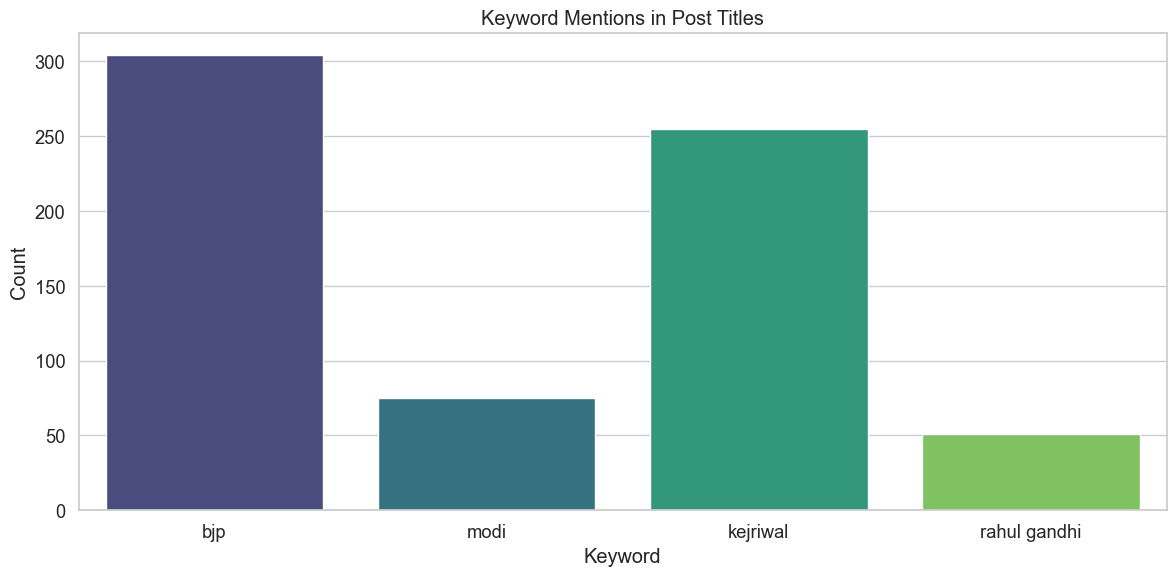

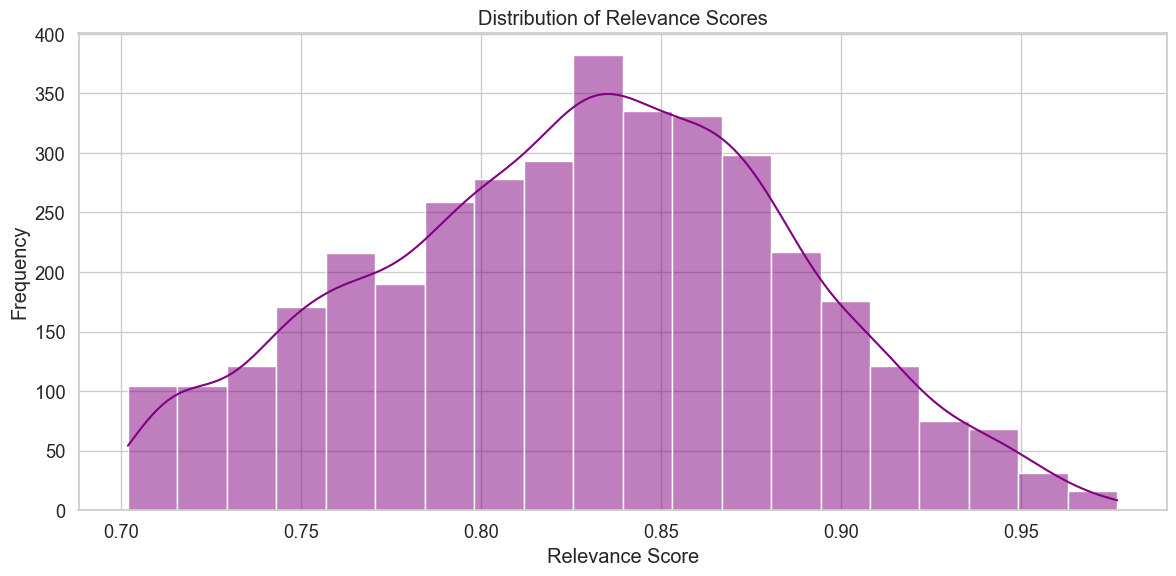

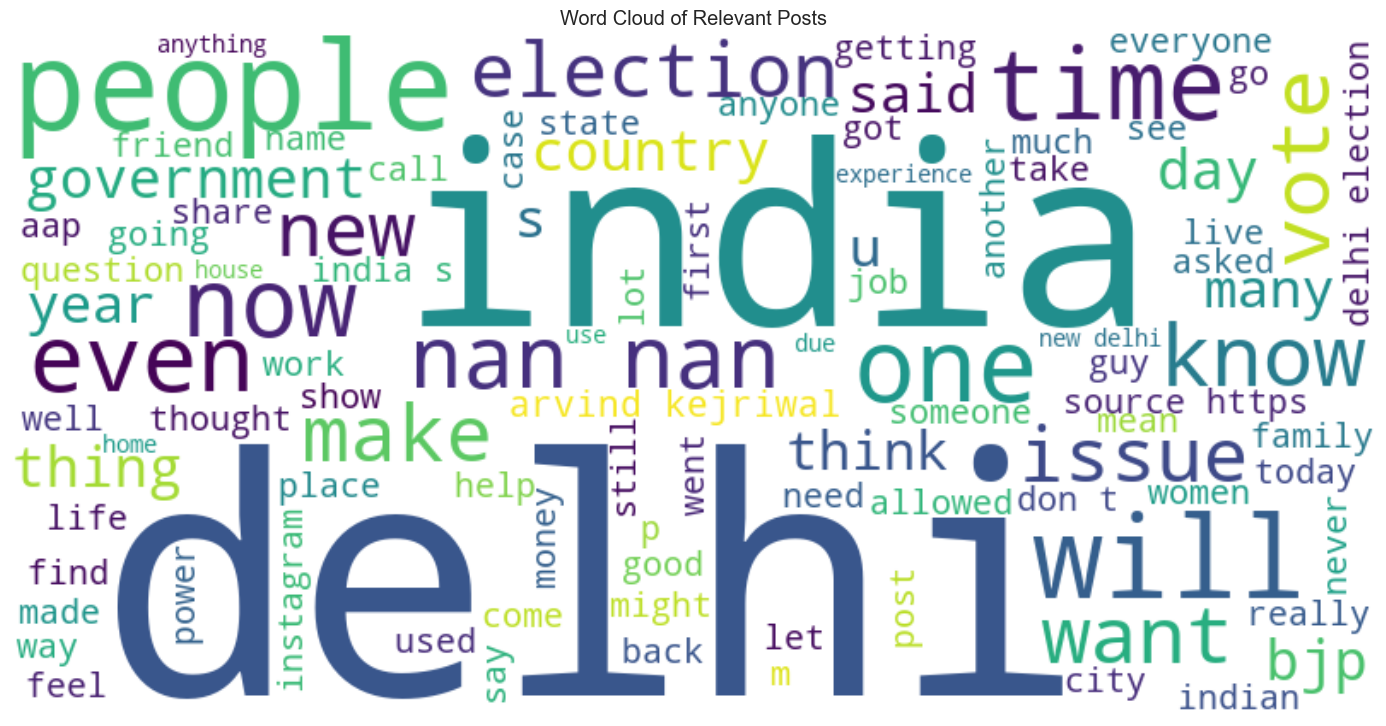

C:\Users\cselab2\AppData\Local\Temp\ipykernel_9152\148394392.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


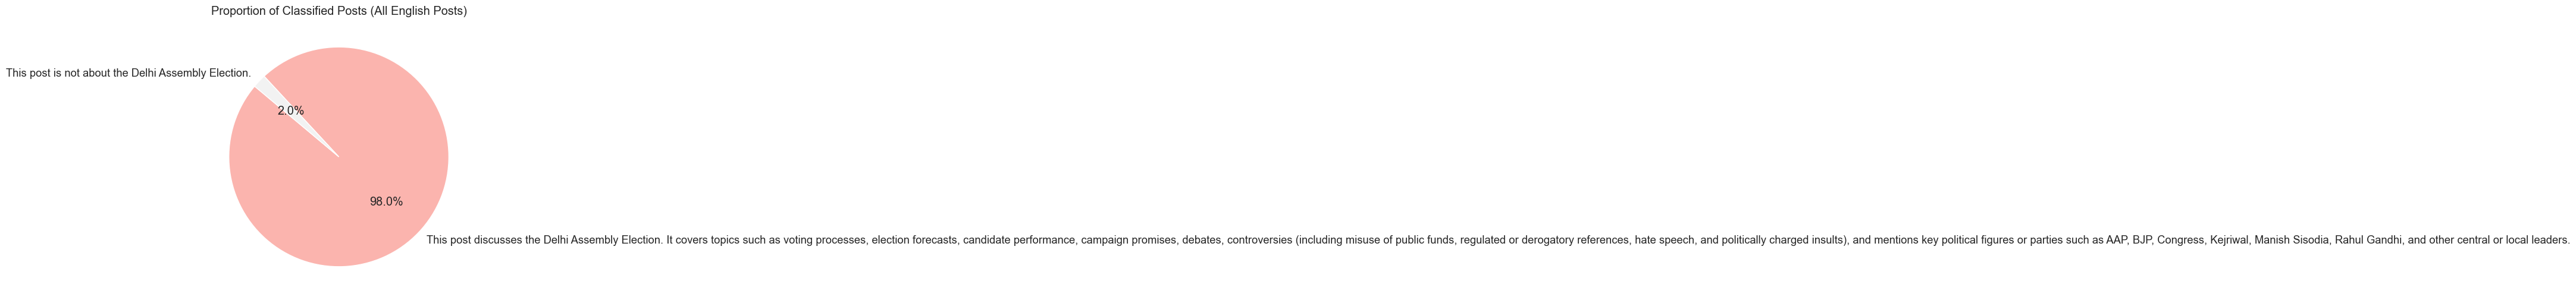

C:\Users\cselab2\AppData\Local\Temp\ipykernel_9152\148394392.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="subreddit", data=final_posts, order=final_posts["subreddit"].value_counts().index, palette="Set2")


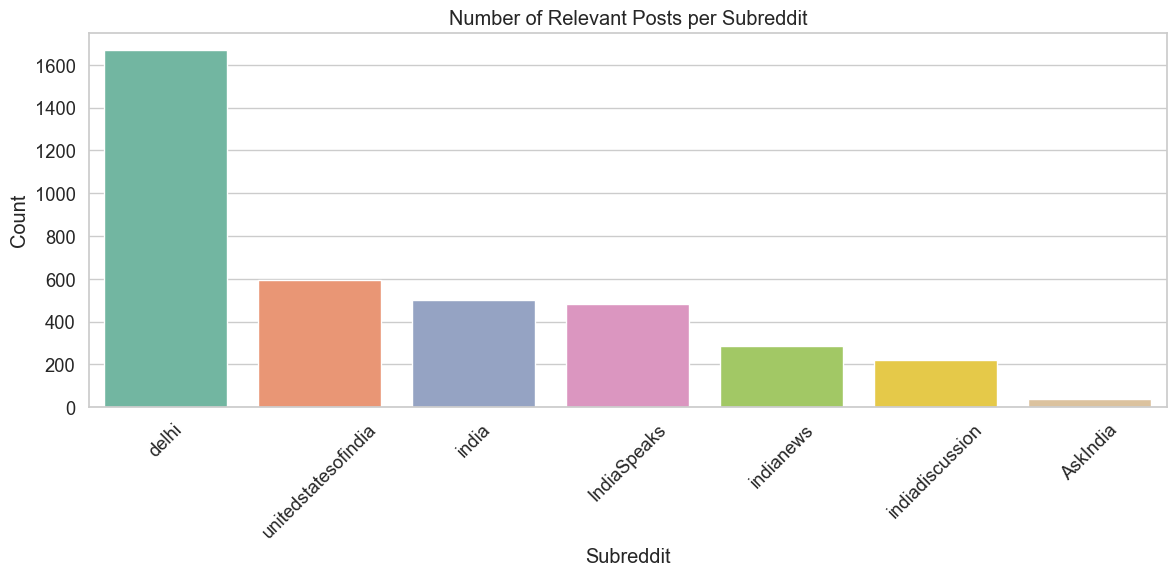

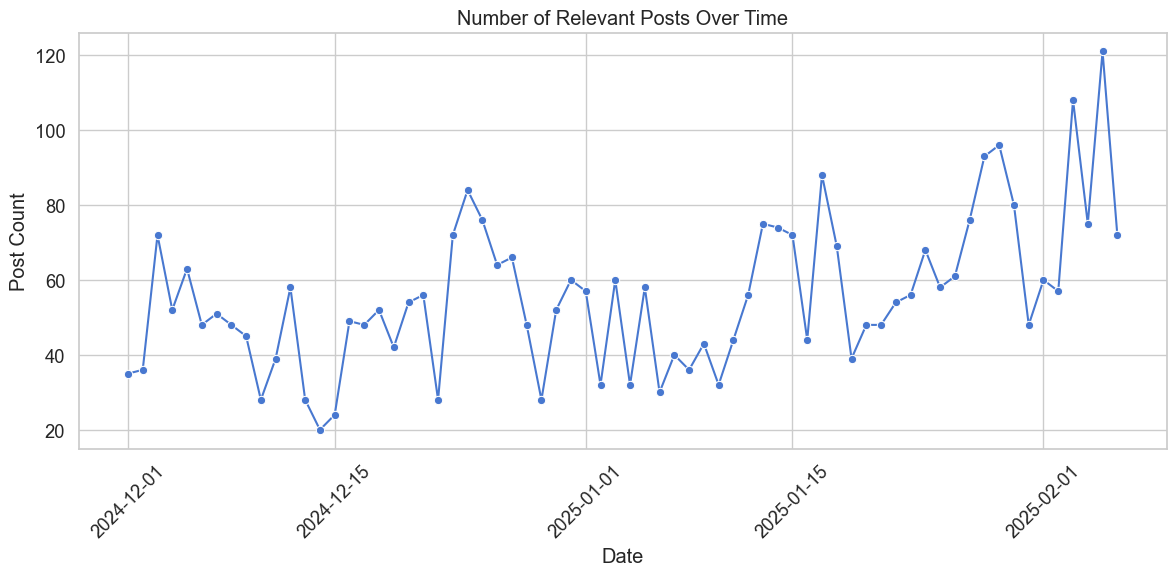

In [ ]:
# ========================================================
# Cell 8: Visualizations & Infographics
# ========================================================

# A. Bar Chart: Frequency of Mentions for Key Terms in Post Titles
def count_keyword_occurrences(df, text_column, keywords):
    return {kw: df[text_column].str.count(kw.lower()).sum() for kw in keywords}

keywords_to_track = ["bjp", "modi", "kejriwal", "rahul gandhi"]
keyword_counts = count_keyword_occurrences(final_posts, "title", keywords_to_track)
df_keywords = pd.DataFrame(list(keyword_counts.items()), columns=["Keyword", "Count"])

plt.figure()
ax = sns.barplot(x="Keyword", y="Count", data=df_keywords, palette="viridis")
plt.title("Keyword Mentions in Post Titles")
plt.ylabel("Count")
plt.xlabel("Keyword")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"bar_keyword_mentions{model_suffix}.png"))
plt.show()

# B. Histogram: Distribution of Relevance Scores
plt.figure()
ax = sns.histplot(final_posts["relevance_score"], bins=20, kde=True, color="purple")
plt.title("Distribution of Relevance Scores")
plt.xlabel("Relevance Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"hist_relevance_scores{model_suffix}.png"))
plt.show()

# C. Word Cloud: Combined Text of Relevant Posts (Title + Selftext)
combined_text = " ".join(final_posts["title"].tolist() + final_posts["selftext"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=100).generate(combined_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Relevant Posts")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"wordcloud_relevant_posts{model_suffix}.png"))
plt.show()

# D. Pie Chart: Proportion of Relevant vs. Irrelevant (from classification)
classification_counts = english_posts["classification_label"].value_counts()
plt.figure()
classification_counts.plot(kind="pie", autopct='%1.1f%%', startangle=140, cmap="Pastel1")
plt.ylabel("")
plt.title("Proportion of Classified Posts (All English Posts)")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"pie_classification_distribution{model_suffix}.png"))
plt.show()

# E. Bar Chart: Count of Posts by Subreddit (for final posts)
plt.figure()
ax = sns.countplot(x="subreddit", data=final_posts, order=final_posts["subreddit"].value_counts().index, palette="Set2")
plt.title("Number of Relevant Posts per Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"bar_posts_by_subreddit{model_suffix}.png"))
plt.show()

# F. Time Series Plot: Posts Over Time (if 'created_utc' exists)
if "created_utc" in final_posts.columns:
    final_posts["created_datetime"] = pd.to_datetime(final_posts["created_utc"], errors='coerce')
    posts_by_date = final_posts.groupby(final_posts["created_datetime"].dt.date).size().reset_index(name="count")
    plt.figure()
    ax = sns.lineplot(data=posts_by_date, x="created_datetime", y="count", marker="o")
    plt.title("Number of Relevant Posts Over Time")
    plt.xlabel("Date")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(FINAL_DIR, f"line_posts_over_time{model_suffix}.png"))
    plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\cselab2\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\cselab2\AppData\Local\Temp\ipykernel_9152\1607209488.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Keyword", y="Avg_Sentiment", data=df_keyword_sentiment, palette="coolwarm")


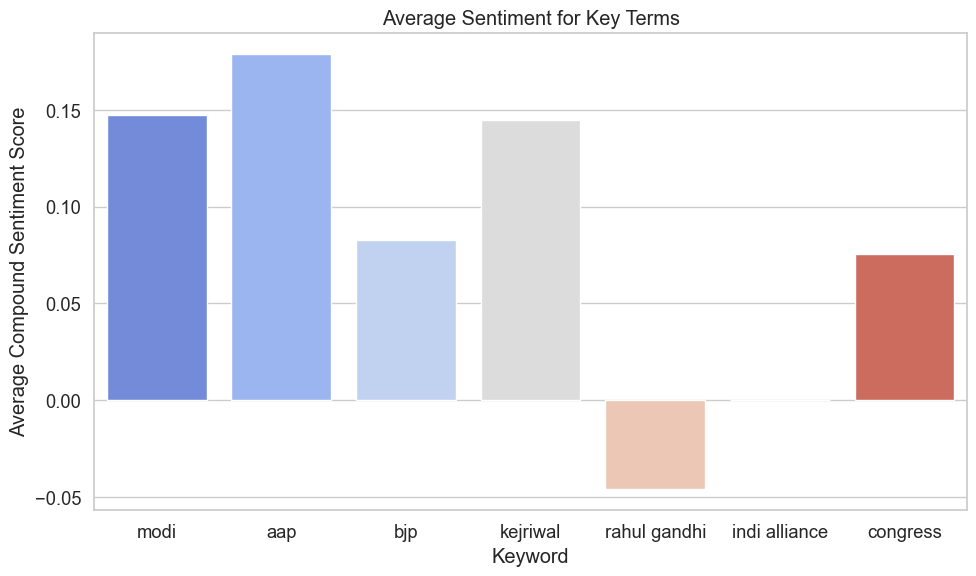

In [ ]:

# ========================================================
# Cell 9: Sentiment Analysis for Key Terms
# ========================================================

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

final_posts['sentiment'] = final_posts['combined_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

keywords = ["modi", "aap", "bjp", "kejriwal", "rahul gandhi", "indi alliance", "congress"]

keyword_sentiments = {}
for kw in keywords:
    posts_with_kw = final_posts[final_posts["combined_text"].str.contains(kw, na=False)]
    keyword_sentiments[kw] = posts_with_kw["sentiment"].mean() if len(posts_with_kw) > 0 else 0

df_keyword_sentiment = pd.DataFrame(list(keyword_sentiments.items()), columns=["Keyword", "Avg_Sentiment"])

plt.figure(figsize=(10,6))
ax = sns.barplot(x="Keyword", y="Avg_Sentiment", data=df_keyword_sentiment, palette="coolwarm")
plt.title("Average Sentiment for Key Terms")
plt.xlabel("Keyword")
plt.ylabel("Average Compound Sentiment Score")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"bar_keyword_sentiments{model_suffix}.png"))
plt.show()

## Manually

In [ ]:
# %%
# ============ Imports & Setup ============

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
import tensorflow as tf
import langdetect
from IPython.display import clear_output, display, Markdown

# Set visualization style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)

# Directories
POSTS_DIR = "data/posts"
COMMENTS_DIR = "data/comments"
FINAL_DIR = "data/final"
REVIEW_DIR = "data/review"

# Create output directories if they don't exist
os.makedirs(FINAL_DIR, exist_ok=True)
os.makedirs(REVIEW_DIR, exist_ok=True)

# Model suffix for file names (if used later in filenames)
model_suffix = "_facebook_bart_large_mnli_tf"

# Optionally, set TensorFlow options
tf.config.optimizer.set_jit(True)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print("Setup complete.")


Setup complete.


In [ ]:
# %%
# ============ Cell 2: Load Data ============

# Load all posts from CSV files
post_files = [os.path.join(POSTS_DIR, f) for f in os.listdir(POSTS_DIR) if f.endswith(".csv")]
all_posts = pd.concat([pd.read_csv(f) for f in post_files], ignore_index=True)

# Load all comments from CSV files
comment_files = [os.path.join(COMMENTS_DIR, f) for f in os.listdir(COMMENTS_DIR) if f.endswith(".csv")]
all_comments = pd.concat([pd.read_csv(f) for f in comment_files], ignore_index=True)

print("Total posts loaded:", len(all_posts))
print("Total comments loaded:", len(all_comments))


Total posts loaded: 1659
Total comments loaded: 41409


In [ ]:
# %%
# ============ Cell 3: Language Filtering (Keep only English) ============

def detect_language(text):
    try:
        return langdetect.detect(text)
    except Exception:
        return "unknown"

# Filter posts assuming the title is the primary text
all_posts["lang"] = all_posts["title"].astype(str).apply(detect_language)
english_posts = all_posts[all_posts["lang"] == "en"].copy()

# Lowercase conversion for consistency
english_posts["title"] = english_posts["title"].astype(str).str.lower()
english_posts["selftext"] = english_posts["selftext"].astype(str).str.lower()

print("English posts count:", len(english_posts))


English posts count: 1506


In [ ]:
# %%
# ============ Cell 4: Prepare Data for Manual Review ============

# Combine title and selftext into one field for easier review
english_posts["text_combined"] = english_posts["title"].fillna('') + "\n\n" + english_posts["selftext"].fillna('')

# Add a column to store your manual labels (e.g., 'toxic', 'non-toxic', etc.)
english_posts["manual_label"] = ""

# (Optional) Shuffle posts to avoid bias during manual review
english_posts = english_posts.sample(frac=1, random_state=42).reset_index(drop=True)

# Save a backup before starting manual labeling
backup_path = os.path.join(REVIEW_DIR, "posts_for_manual_review.csv")
english_posts.to_csv(backup_path, index=False)
print("Data prepared for manual review and saved to:", backup_path)


Data prepared for manual review and saved to: data/review\posts_for_manual_review.csv


In [ ]:
# ============ Cell 5: Manual Review Interface with y/n Input ============

import os
from IPython.display import display, Markdown, clear_output

def manual_review_with_input(df, start_index=0):
    # Ensure a column exists for manual labels
    if "manual_label" not in df.columns:
        df["manual_label"] = ""
    
    total_posts = len(df)
    relevant_count = df["manual_label"].value_counts().get("relevant", 0)
    
    for idx in range(start_index, total_posts):
        clear_output(wait=True)
        row = df.loc[idx]
        processed_count = idx + 1
        remaining = total_posts - processed_count
        
        # Display progress information and the post details
        display(Markdown(f"### Post {processed_count} of {total_posts}"))
        display(Markdown(f"**Posts left:** {remaining}"))
        display(Markdown(f"**Relevant so far:** {relevant_count}"))
        display(Markdown(f"**Subreddit:** `{row['subreddit']}`"))
        display(Markdown(f"**Title:** {row['title']}"))
        display(Markdown(f"**Content:**\n\n{row['selftext']}"))
        
        # Get user input: y for relevant, n for irrelevant, Enter to skip.
        user_input = input("Mark this post as relevant (y) or irrelevant (n) [or press Enter to skip]: ").strip().lower()
        
        if user_input == "y":
            df.at[idx, "manual_label"] = "relevant"
            relevant_count += 1
        elif user_input == "n":
            df.at[idx, "manual_label"] = "irrelevant"
        else:
            df.at[idx, "manual_label"] = "skip"
        
        # Save progress after each post
        progress_path = os.path.join(REVIEW_DIR, "posts_labeled_so_far.csv")
        df.to_csv(progress_path, index=False)
    
    clear_output(wait=True)
    print("✅ Manual review complete.")
    return df


# ============ Resume Logic ============

# Load previously labeled file if exists
progress_path = os.path.join(REVIEW_DIR, "posts_labeled_so_far.csv")
if os.path.exists(progress_path):
    english_posts = pd.read_csv(progress_path)
    print("Loaded progress from saved file.")
else:
    print("No saved progress found. Starting fresh.")

# Find the first unlabeled post
unlabeled_mask = ~english_posts["manual_label"].isin(["relevant", "irrelevant"])
next_index = english_posts[unlabeled_mask].index.min()

# If all posts are labeled, skip review
if pd.isna(next_index):
    print("✅ All posts are already labeled!")
else:
    english_posts = manual_review_with_input(english_posts, start_index=next_index)



✅ Manual review complete.


In [ ]:
# ============ Cell 6: Save Final Labeled Data ============

# Save all labeled posts (including irrelevant) for future reference
final_labeled_path = os.path.join(REVIEW_DIR, "final_labeled_posts.csv")
english_posts.to_csv(final_labeled_path, index=False)
print("Final labeled posts saved to:", final_labeled_path)

# Filter only relevant posts for further analysis
final_posts = english_posts[english_posts["manual_label"] == "relevant"].copy()

# If not already present, combine title and selftext into a single field
if "combined_text" not in final_posts.columns:
    final_posts["combined_text"] = final_posts["title"].fillna('') + " " + final_posts["selftext"].fillna('')
else:
    final_posts["combined_text"] = final_posts["combined_text"].fillna('')  # Just in case of NaNs

# Assign classification label from manual review
final_posts["classification_label"] = final_posts["manual_label"]

# # Optional: Add dummy relevance score (based on word count, can be replaced later with real score)
# final_posts["relevance_score"] = final_posts["combined_text"].apply(lambda x: len(x.split()) / 100)


final_relevant_path = os.path.join(FINAL_DIR, "final_relevant_posts_manual.csv")
final_posts.to_csv(final_relevant_path, index=False)
print("Relevant posts saved to:", final_relevant_path)



Final labeled posts saved to: data/review\final_labeled_posts.csv
Relevant posts saved to: data/final\final_relevant_posts_manual.csv


C:\Users\cselab2\AppData\Local\Temp\ipykernel_17220\3833495466.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Keyword", y="Count", data=df_keywords, palette="viridis")


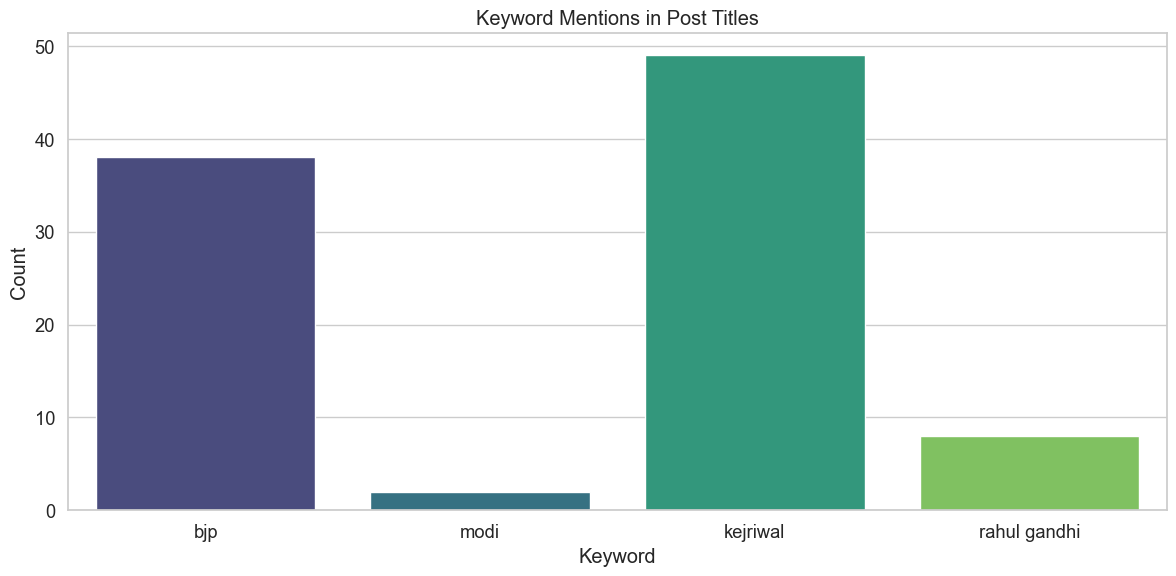

In [ ]:
# %%
# ============ Cell 7: Infographics & Visualizations (Part A) ============
# A. Bar Chart: Frequency of Mentions for Key Terms in Post Titles

def count_keyword_occurrences(df, text_column, keywords):
    # Count occurrences of each keyword (case-insensitive)
    return {kw: df[text_column].str.count(kw.lower()).sum() for kw in keywords}

keywords_to_track = ["bjp", "modi", "kejriwal", "rahul gandhi"]
keyword_counts = count_keyword_occurrences(final_posts, "title", keywords_to_track)
df_keywords = pd.DataFrame(list(keyword_counts.items()), columns=["Keyword", "Count"])

plt.figure()
ax = sns.barplot(x="Keyword", y="Count", data=df_keywords, palette="viridis")
plt.title("Keyword Mentions in Post Titles")
plt.ylabel("Count")
plt.xlabel("Keyword")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"bar_keyword_mentions{model_suffix}.png"))
plt.show()


In [ ]:
# %%
# ============ Cell 8: Infographics & Visualizations (Part B) ============
# B. Histogram: Distribution of Relevance Scores

plt.figure()
ax = sns.histplot(final_posts["relevance_score"], bins=20, kde=True, color="purple")
plt.title("Distribution of Relevance Scores")
plt.xlabel("Relevance Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"hist_relevance_scores{model_suffix}.png"))
plt.show()


KeyError: 'relevance_score'

<Figure size 1200x600 with 0 Axes>

In [ ]:
# %%
# ============ Cell 9: Infographics & Visualizations (Part C) ============
# C. Word Cloud: Combined Text of Relevant Posts (Title + Selftext)

combined_text = " ".join(final_posts["title"].tolist() + final_posts["selftext"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=100).generate(combined_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Relevant Posts")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"wordcloud_relevant_posts{model_suffix}.png"))
plt.show()


TypeError: sequence item 440: expected str instance, float found

C:\Users\cselab2\AppData\Local\Temp\ipykernel_17220\1798304486.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Keyword", y="Avg_Sentiment", data=df_keyword_sentiment, palette="coolwarm")


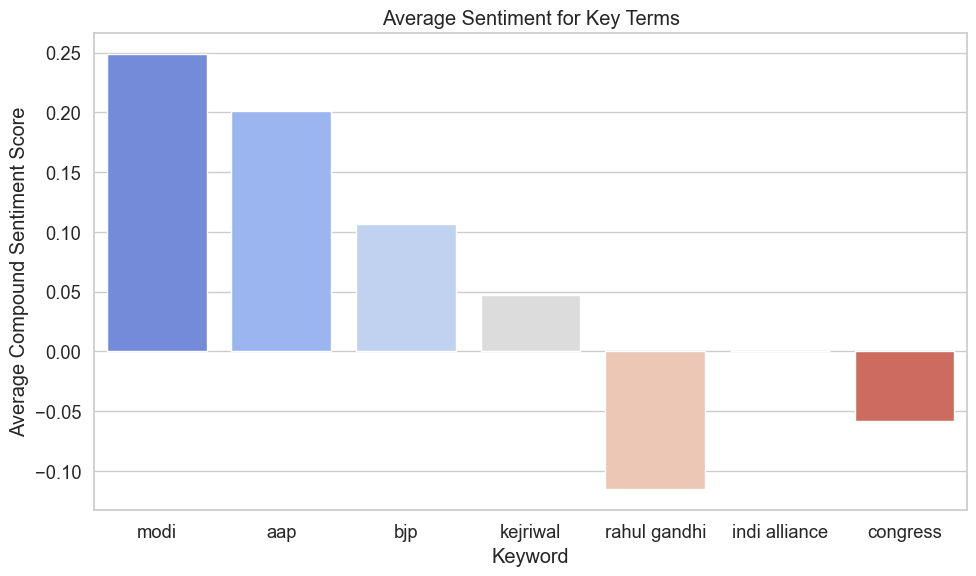

In [ ]:
# %%
# ============ Cell 10: Sentiment Analysis for Key Terms ============

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

final_posts['sentiment'] = final_posts['combined_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Define the key terms you want to analyze sentiment for
keywords = ["modi", "aap", "bjp", "kejriwal", "rahul gandhi", "indi alliance", "congress"]

keyword_sentiments = {}
for kw in keywords:
    posts_with_kw = final_posts[final_posts["combined_text"].str.contains(kw, na=False)]
    keyword_sentiments[kw] = posts_with_kw["sentiment"].mean() if len(posts_with_kw) > 0 else 0

df_keyword_sentiment = pd.DataFrame(list(keyword_sentiments.items()), columns=["Keyword", "Avg_Sentiment"])

plt.figure(figsize=(10,6))
ax = sns.barplot(x="Keyword", y="Avg_Sentiment", data=df_keyword_sentiment, palette="coolwarm")
plt.title("Average Sentiment for Key Terms")
plt.xlabel("Keyword")
plt.ylabel("Average Compound Sentiment Score")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"bar_keyword_sentiments{model_suffix}.png"))
plt.show()


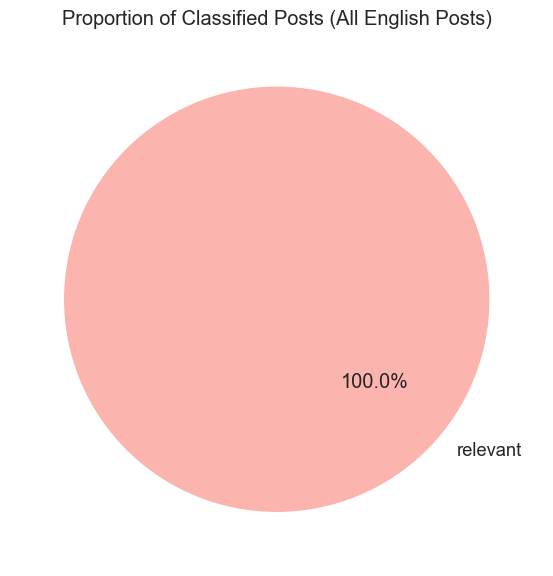

C:\Users\cselab2\AppData\Local\Temp\ipykernel_17220\1178941977.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="subreddit", data=final_posts,


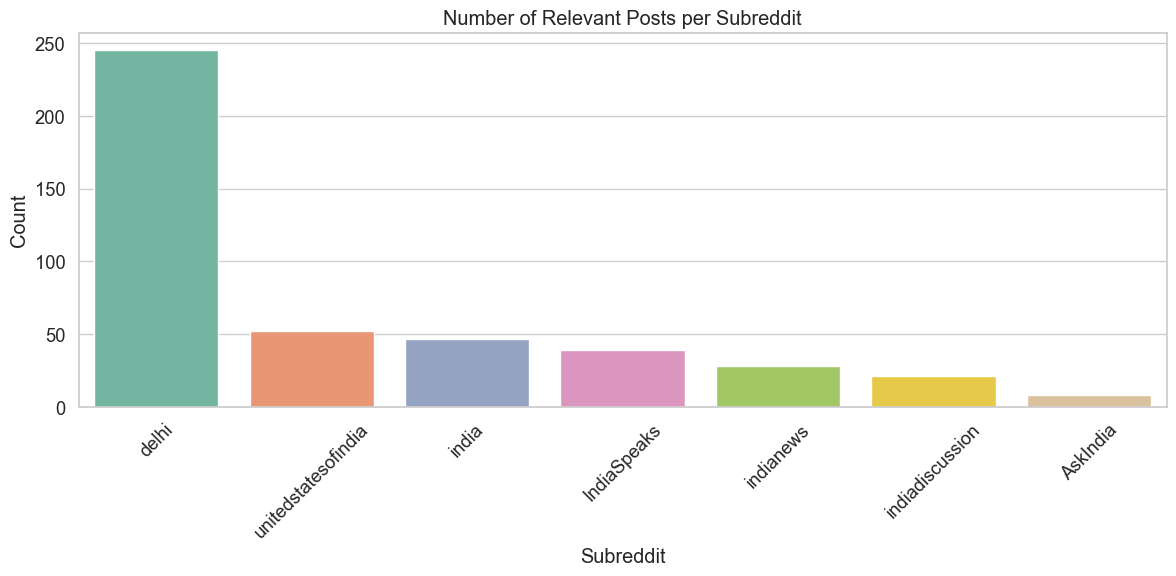

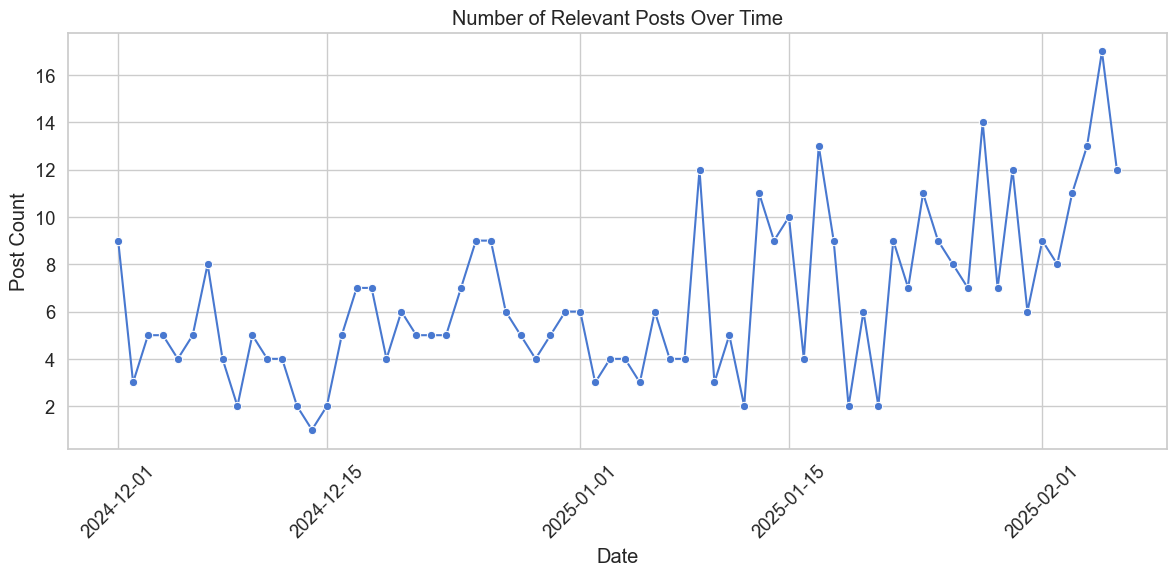

In [ ]:
# %%
# ============ Cell 11: Additional Infographics ============
# D. Pie Chart: Proportion of Classified Posts
# Here we use the manual labels stored in 'classification_label'
classification_counts = final_posts["classification_label"].value_counts()
plt.figure()
classification_counts.plot(kind="pie", autopct='%1.1f%%', startangle=140, cmap="Pastel1")
plt.ylabel("")
plt.title("Proportion of Classified Posts (All English Posts)")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, f"pie_classification_distribution{model_suffix}.png"))
plt.show()

# E. Bar Chart: Count of Posts by Subreddit (if 'subreddit' column exists)
if "subreddit" in final_posts.columns:
    plt.figure()
    ax = sns.countplot(x="subreddit", data=final_posts, 
                         order=final_posts["subreddit"].value_counts().index, palette="Set2")
    plt.title("Number of Relevant Posts per Subreddit")
    plt.xlabel("Subreddit")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(FINAL_DIR, f"bar_posts_by_subreddit{model_suffix}.png"))
    plt.show()

# F. Time Series Plot: Posts Over Time (if 'created_utc' column exists)
if "created_utc" in final_posts.columns:
    final_posts["created_datetime"] = pd.to_datetime(final_posts["created_utc"], errors='coerce')
    posts_by_date = final_posts.groupby(final_posts["created_datetime"].dt.date).size().reset_index(name="count")
    plt.figure()
    ax = sns.lineplot(data=posts_by_date, x="created_datetime", y="count", marker="o")
    plt.title("Number of Relevant Posts Over Time")
    plt.xlabel("Date")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(FINAL_DIR, f"line_posts_over_time{model_suffix}.png"))
    plt.show()


# Pre-analysis

In [ ]:
# Essential imports for data processing and analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import re
import json
import pickle
from collections import Counter, defaultdict

# NLP tools
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPool1D, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Transformers for BERT
from transformers import BertTokenizer, TFBertForSequenceClassification, BertConfig
from transformers import pipeline

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Visualization settings
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)

# Download necessary NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Try to load spaCy model; download if not available
try:
    nlp = spacy.load("en_core_web_sm")
except:
    print("Downloading spaCy model...")
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# Define directories
BASE_DIR = "data"
COMMENTS_DIR = os.path.join(BASE_DIR, "comments")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_comments")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
VISUALIZATIONS_DIR = os.path.join(BASE_DIR, "comment_visualizations")

# Create directories if they don't exist
for directory in [PROCESSED_DIR, MODELS_DIR, RESULTS_DIR, VISUALIZATIONS_DIR]:
    os.makedirs(directory, exist_ok=True)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Setup complete!")


Setup complete!


In [ ]:
# Add this at the beginning of your script or in a cell before your preprocessing code
nltk.download('punkt')
nltk.download('punkt_tab')


# If you're also using stopwords in your preprocess_text function, download those too
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cselab2\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\cselab2\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cselab2\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Loaded 22970 unique comments from 5 threshold files

Basic comment statistics:
Number of comments: 22970

Comment length statistics:
count    22970.000000
mean       135.457205
std        193.419629
min          1.000000
25%         33.000000
50%         73.000000
75%        160.000000
max       3670.000000
Name: comment_length, dtype: float64


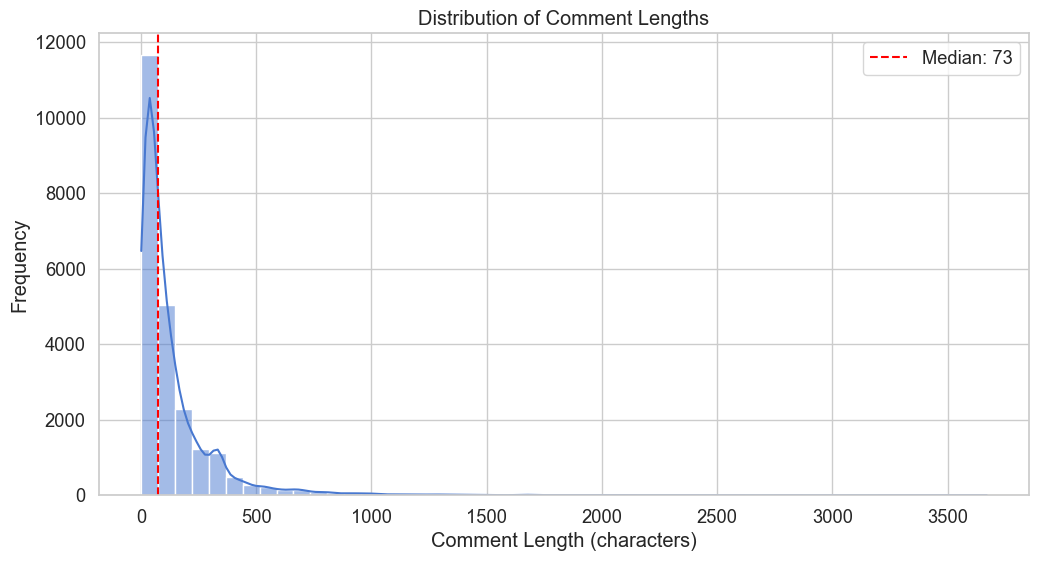


Sample comments:

Comment 1: Even Sheila Dikshit was better than this guy. The budget of Delhi is as much as small country, and he cannot fix basic roads, pollution, healthcare and just wants to give out freebies. Forget building...

Comment 2: If they wanted to talk to u again, they would. I deleted my account then made a new account to get a Reddit friend's social because i was missing them....

Comment 3: The metro really brings out the best in all of us! Except those bastards who eat on the train—they can go to hell....

Comment 4: Don't mind me, I just commented so that this post get's more reach and reaches to that delulu girl!...

Comment 5: Thanks buddy, will definitely check it out. 
I hope there are some cafes also to hangout....


In [ ]:
# Load comments from all thresholds - adapted from original analysis
thresholds = [0.6, 0.65, 0.7, 0.75, 0.8]
all_comments = []

# Function to load comments for each threshold
def load_threshold_comments(threshold):
    safe_t = str(threshold).replace('.', '_')
    comments_path = os.path.join(BASE_DIR, f"final/claude(8)/threshold_{safe_t}/relevant_comments.csv")
    
    if os.path.exists(comments_path):
        comments = pd.read_csv(comments_path)
        comments['threshold'] = threshold  # Add threshold as a column for tracking
        return comments
    else:
        print(f"No comments file found for threshold {threshold}")
        return pd.DataFrame()

# Load comments for all thresholds
all_comments_dfs = []
for t in thresholds:
    comments_df = load_threshold_comments(t)
    if not comments_df.empty:
        all_comments_dfs.append(comments_df)

if all_comments_dfs:
    # Concatenate all comments
    comments_df = pd.concat(all_comments_dfs, ignore_index=True)
    
    # Remove duplicates (same comment may appear in multiple threshold results)
    comments_df = comments_df.drop_duplicates(subset=['comment_id'])  # Changed from 'id' to 'comment_id'
    
    print(f"Loaded {len(comments_df)} unique comments from {len(all_comments_dfs)} threshold files")
    
    # Basic exploration
    print("\nBasic comment statistics:")
    print(f"Number of comments: {len(comments_df)}")
    
    # Use comment_body as the comment text column
    comment_col = 'comment_body'
    
    # Calculate comment length
    comments_df['comment_length'] = comments_df[comment_col].astype(str).apply(len)
    
    # Show summary statistics
    print("\nComment length statistics:")
    print(comments_df['comment_length'].describe())
    
    # Plot comment length distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(comments_df['comment_length'], bins=50, kde=True)
    plt.title("Distribution of Comment Lengths")
    plt.xlabel("Comment Length (characters)")
    plt.ylabel("Frequency")
    plt.axvline(comments_df['comment_length'].median(), color='red', linestyle='--', label=f"Median: {comments_df['comment_length'].median():.0f}")
    plt.legend()
    plt.savefig(os.path.join(VISUALIZATIONS_DIR, "comment_length_distribution.png"))
    plt.show()
    
    # Sample of comments
    print("\nSample comments:")
    sample_comments = comments_df.sample(5)[comment_col].tolist()
    for i, comment in enumerate(sample_comments, 1):
        print(f"\nComment {i}: {comment[:200]}...")
else:
    print("No comment files found for any threshold")
    # Create empty DataFrame to avoid errors in subsequent cells
    comments_df = pd.DataFrame(columns=['post_id', 'comment_id', 'comment_body', 'comment_score', 'comment_author', 'comment_created_utc', 'parent_id', 'depth', 'body_processed'])
    comment_col = 'comment_body'


In [ ]:
# Define the comment text column for consistency in subsequent cells
if 'body' in comments_df.columns:
    COMMENT_COL = 'body'
elif 'comment_body' in comments_df.columns:
    COMMENT_COL = 'comment_body'
elif 'body_processed' in comments_df.columns:
    COMMENT_COL = 'body_processed'
else:
    COMMENT_COL = 'body'  # Default
    comments_df[COMMENT_COL] = ""  # Create empty column if needed

# Preprocessing function
def preprocess_text(text, remove_stopwords=False):
    """
    Comprehensive text preprocessing function
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove special characters and numbers (keeping apostrophes for contractions)
    text = re.sub(r'[^a-zA-Z\s\']', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords if specified
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Rejoin tokens
    text = ' '.join(tokens)
    
    return text

# Apply preprocessing to comments
print("Preprocessing comments...")
comments_df['clean_text'] = comments_df[COMMENT_COL].apply(lambda x: preprocess_text(x, remove_stopwords=False))
comments_df['clean_text_no_stopwords'] = comments_df[COMMENT_COL].apply(lambda x: preprocess_text(x, remove_stopwords=True))

# Extract sentences from comments for more granular analysis
def extract_sentences(text):
    if pd.isna(text) or not isinstance(text, str) or text.strip() == '':
        return []
    return sent_tokenize(text)

comments_df['sentences'] = comments_df[COMMENT_COL].apply(extract_sentences)
comments_df['sentence_count'] = comments_df['sentences'].apply(len)

# Calculate word counts
comments_df['word_count'] = comments_df['clean_text'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

# Display preprocessing results
print("\nPreprocessing complete!")
print(f"Average word count per comment: {comments_df['word_count'].mean():.1f}")
print(f"Average sentence count per comment: {comments_df['sentence_count'].mean():.1f}")

# Show examples of original vs preprocessed text
print("\nPreprocessing Examples:")
sample_indices = np.random.choice(len(comments_df), min(3, len(comments_df)), replace=False)
for idx in sample_indices:
    print(f"\nOriginal: {comments_df.iloc[idx][COMMENT_COL][:100]}...")
    print(f"Preprocessed: {comments_df.iloc[idx]['clean_text'][:100]}...")

# Save preprocessed data
comments_df.to_csv(os.path.join(PROCESSED_DIR, "preprocessed_comments.csv"), index=False)
print(f"\nPreprocessed comments saved to {os.path.join(PROCESSED_DIR, 'preprocessed_comments.csv')}")


Preprocessing comments...

Preprocessing complete!
Average word count per comment: 23.4
Average sentence count per comment: 2.0

Preprocessing Examples:

Original: Do you have any other apple device? You can use it to reset the password....
Preprocessed: do you have any other apple device you can use it to reset the password...

Original: I dont think she was rude, she just didn’t indulge you. Next time refer to women as ma’am if you nee...
Preprocessed: i dont think she wa rude she just didn t indulge you next time refer to woman a ma am if you need th...

Original: Start hone se pehle....
Preprocessed: start hone se pehle...

Preprocessed comments saved to data\processed_comments\preprocessed_comments.csv


Performing sentiment analysis...

Sentiment Distribution:
Positive: 40.0%
Neutral: 37.9%
Negative: 22.1%

Toxicity Statistics:
Potentially toxic comments: 1226 (5.3%)


C:\Users\cselab2\AppData\Local\Temp\ipykernel_10656\2357703549.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=comments_df, palette={"positive": "green", "neutral": "gray", "negative": "red"})


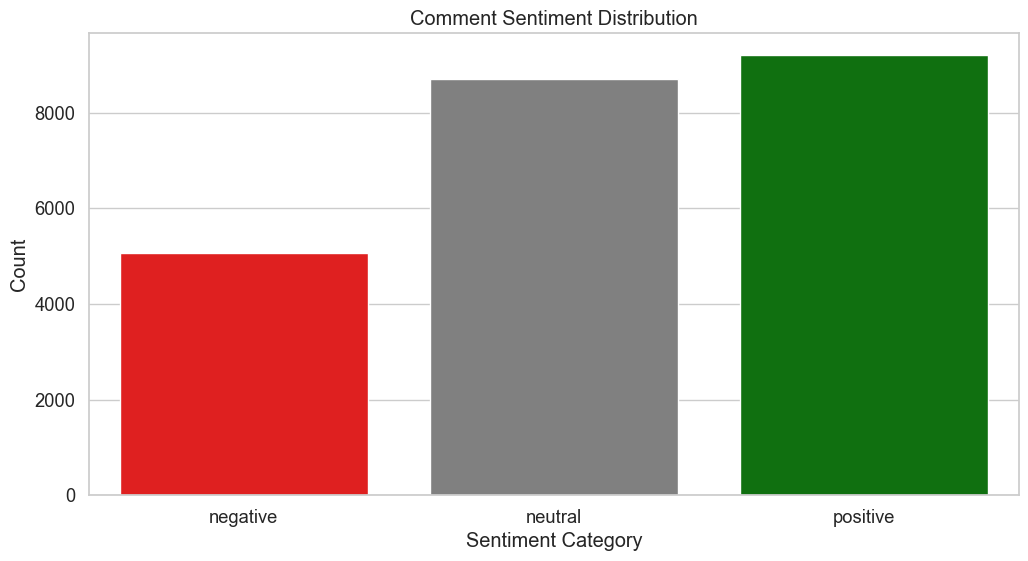

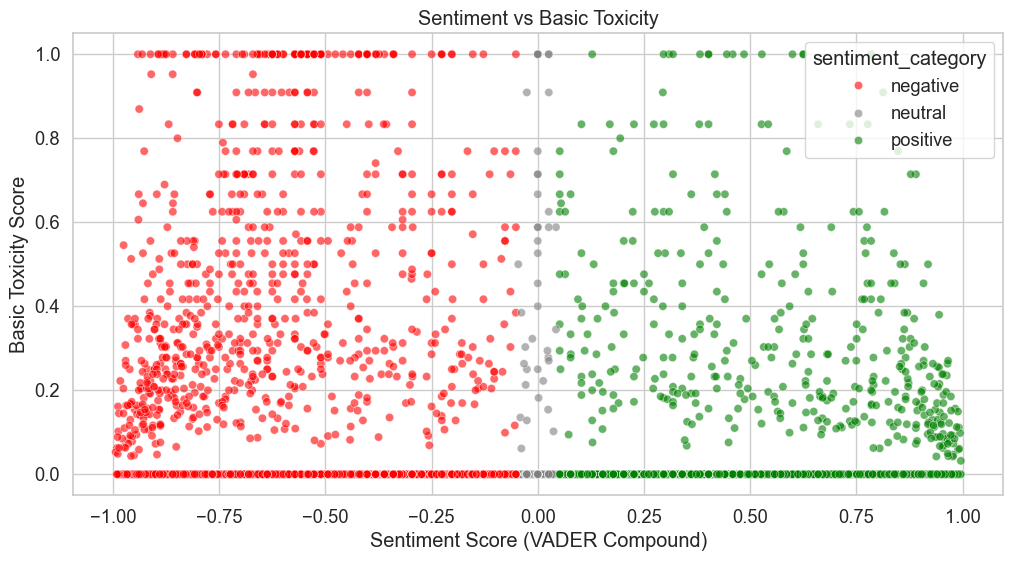

Comments with sentiment analysis saved to data\processed_comments\comments_with_sentiment.csv


In [ ]:
# Initialize sentiment analyzers
sia = SentimentIntensityAnalyzer()

# Basic sentiment analysis function using VADER
def get_vader_sentiment(text):
    """Extract sentiment scores using VADER"""
    if not isinstance(text, str) or text.strip() == '':
        return {"neg": 0, "neu": 0, "pos": 0, "compound": 0}
    return sia.polarity_scores(text)

# Apply sentiment analysis to comments
print("Performing sentiment analysis...")
comments_df['vader_scores'] = comments_df['clean_text'].apply(get_vader_sentiment)
comments_df['vader_compound'] = comments_df['vader_scores'].apply(lambda x: x['compound'])
comments_df['vader_pos'] = comments_df['vader_scores'].apply(lambda x: x['pos'])
comments_df['vader_neg'] = comments_df['vader_scores'].apply(lambda x: x['neg'])
comments_df['vader_neu'] = comments_df['vader_scores'].apply(lambda x: x['neu'])

# Classify sentiment into categories
def get_sentiment_category(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

comments_df['sentiment_category'] = comments_df['vader_compound'].apply(get_sentiment_category)

# TextBlob sentiment for comparison
comments_df['textblob_polarity'] = comments_df['clean_text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
comments_df['textblob_subjectivity'] = comments_df['clean_text'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

# Toxicity detection function using keyword approach
# (We'll enhance this with a dedicated model in a later cell)
toxicity_keywords = [
    'idiot', 'stupid', 'dumb', 'moron', 'hate', 'disgusting', 'pathetic', 'loser', 
    'jerk', 'asshole', 'fuck', 'shit', 'damn', 'bitch', 'crap', 'trash', 'garbage',
    'worthless', 'useless', 'die', 'kill', 'worst', 'terrible', 'horrible', 'awful',
    'retard', 'scum', 'disgrace', 'disaster', 'failure'
]

def basic_toxicity_score(text):
    """Simple toxicity scoring based on presence of toxic keywords"""
    if not isinstance(text, str) or text.strip() == '':
        return 0
    
    text = text.lower()
    tokens = set(text.split())
    
    # Count toxic words
    toxic_count = sum(1 for word in toxicity_keywords if word in tokens)
    
    # Normalize by text length (to avoid long texts getting higher scores just because of length)
    score = toxic_count / max(1, len(tokens)) * 10  # Scale up by 10 for better readability
    
    return min(score, 1.0)  # Cap at 1.0

comments_df['basic_toxicity'] = comments_df['clean_text'].apply(basic_toxicity_score)
comments_df['is_toxic'] = comments_df['basic_toxicity'] > 0.1  # Simple threshold

# Display sentiment and toxicity statistics
print("\nSentiment Distribution:")
sentiment_counts = comments_df['sentiment_category'].value_counts(normalize=True) * 100
for category, percentage in sentiment_counts.items():
    print(f"{category.capitalize()}: {percentage:.1f}%")

print("\nToxicity Statistics:")
print(f"Potentially toxic comments: {comments_df['is_toxic'].sum()} ({comments_df['is_toxic'].mean()*100:.1f}%)")

# Visualize sentiment distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='sentiment_category', data=comments_df, palette={"positive": "green", "neutral": "gray", "negative": "red"})
plt.title("Comment Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.savefig(os.path.join(VISUALIZATIONS_DIR, "comment_sentiment_distribution.png"))
plt.show()

# Visualize sentiment vs toxicity
plt.figure(figsize=(12, 6))
sns.scatterplot(x='vader_compound', y='basic_toxicity', hue='sentiment_category', 
                data=comments_df, palette={"positive": "green", "neutral": "gray", "negative": "red"},
                alpha=0.6)
plt.title("Sentiment vs Basic Toxicity")
plt.xlabel("Sentiment Score (VADER Compound)")
plt.ylabel("Basic Toxicity Score")
plt.savefig(os.path.join(VISUALIZATIONS_DIR, "sentiment_vs_toxicity.png"))
plt.show()

# Save the enhanced dataframe
comments_df.to_csv(os.path.join(PROCESSED_DIR, "comments_with_sentiment.csv"), index=False)
print(f"Comments with sentiment analysis saved to {os.path.join(PROCESSED_DIR, 'comments_with_sentiment.csv')}")


Setting up toxicity detection model...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.
Device set to use -1


Analyzing toxicity for 23024 sampled comments...


  0%|          | 0/23024 [00:00<?, ?it/s]


Advanced Toxicity Analysis Results:
Toxic comments detected: 22431 (97.4%)


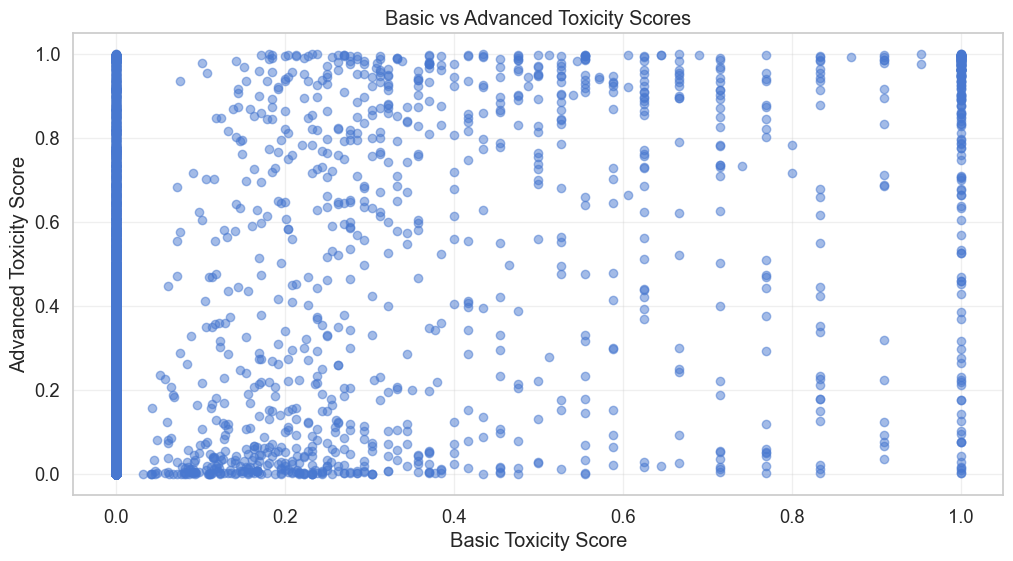

Comments with toxicity analysis saved to data\processed_comments\comments_with_toxicity.csv


In [ ]:
# Load a pre-trained model for toxicity detection
print("Setting up toxicity detection model...")

try:
    # Use Hugging Face's toxicity classifier
    toxicity_classifier = pipeline(
        "text-classification",
        model="unitary/toxic-bert",
        device=0 if tf.config.list_physical_devices('GPU') else -1
    )
    
    # Function to get toxicity score from the model
    def get_advanced_toxicity_score(text):
        if not isinstance(text, str) or text.strip() == '':
            return {"label": "non-toxic", "score": 0.0}
        
        # Truncate long texts
        if len(text) > 512:
            text = text[:512]
            
        try:
            result = toxicity_classifier(text)[0]
            return result
        except Exception as e:
            print(f"Error in toxicity detection: {e}")
            return {"label": "non-toxic", "score": 0.0}
    
    # Apply to a sample of comments (to save time)
    sample_size = len(comments_df)
    sample_indices = np.random.choice(len(comments_df), sample_size, replace=False)
    
    print(f"Analyzing toxicity for {sample_size} sampled comments...")
    for idx in tqdm(sample_indices):
        result = get_advanced_toxicity_score(comments_df.iloc[idx]['clean_text'])
        comments_df.at[idx, 'advanced_toxicity_label'] = result['label']
        comments_df.at[idx, 'advanced_toxicity_score'] = result['score']
    
    # Fill NaN values for non-sampled comments
    comments_df['advanced_toxicity_label'] = comments_df['advanced_toxicity_label'].fillna('not_analyzed')
    comments_df['advanced_toxicity_score'] = comments_df['advanced_toxicity_score'].fillna(-1)
    
    # Compare basic and advanced toxicity for sampled comments
    analyzed_comments = comments_df[comments_df['advanced_toxicity_score'] >= 0]
    
    print("\nAdvanced Toxicity Analysis Results:")
    toxic_count = (analyzed_comments['advanced_toxicity_label'] == 'toxic').sum()
    print(f"Toxic comments detected: {toxic_count} ({toxic_count/len(analyzed_comments)*100:.1f}%)")
    
    # Visualize comparison
    plt.figure(figsize=(12, 6))
    plt.scatter(analyzed_comments['basic_toxicity'], 
                analyzed_comments['advanced_toxicity_score'],
                alpha=0.5)
    plt.title("Basic vs Advanced Toxicity Scores")
    plt.xlabel("Basic Toxicity Score")
    plt.ylabel("Advanced Toxicity Score")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(VISUALIZATIONS_DIR, "toxicity_score_comparison.png"))
    plt.show()
    
except Exception as e:
    print(f"Could not load toxicity model: {e}")
    print("Continuing without advanced toxicity detection")
    comments_df['advanced_toxicity_label'] = 'not_analyzed'
    comments_df['advanced_toxicity_score'] = -1

# Save updated dataframe
comments_df.to_csv(os.path.join(PROCESSED_DIR, "comments_with_toxicity.csv"), index=False)
print(f"Comments with toxicity analysis saved to {os.path.join(PROCESSED_DIR, 'comments_with_toxicity.csv')}")


Analyzing keyword-sentiment associations...
Total unique words: 24058

Top 20 words:
n't: 3212
's: 3042
hai: 3039
delhi: 2658
people: 2439
like: 1845
community: 1543
one: 1412
get: 1315
party: 1306
bjp: 1285
even: 1264
vote: 1230
bhai: 1169
time: 1137
also: 1123
aap: 1115
ki: 1078
bhi: 1072
know: 1049

Top election-related keywords:
n't
's
hai
delhi
people
like
community
one
get
party
bjp
even
vote
bhai
time
also
aap
ki
bhi
know

Keyword Sentiment Analysis:
           count  avg_sentiment  positive_pct  neutral_pct  negative_pct
hai         2069       0.047395     29.192847    49.879169     20.927985
bhai        1123       0.051001     27.871772    53.161175     18.967053
bhi          927       0.066221     32.686084    45.846818     21.467098
ki           834       0.086260     36.570743    42.086331     21.342926
n't         2408       0.114115     51.245847    12.458472     36.295681
bjp          990       0.138961     49.797980    18.282828     31.919192
delhi       1963       0.14

C:\Users\cselab2\AppData\Local\Temp\ipykernel_10656\3262841060.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_sentiment_df.index,


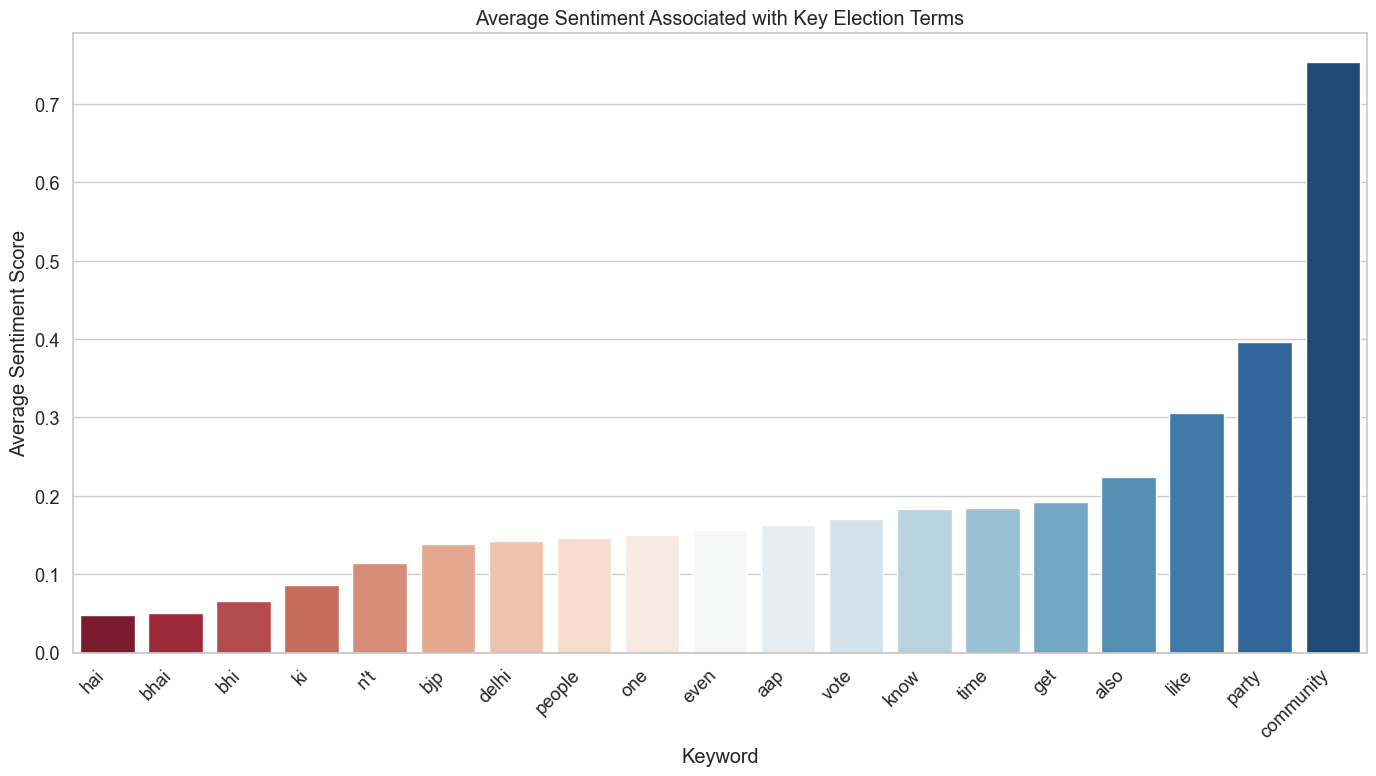

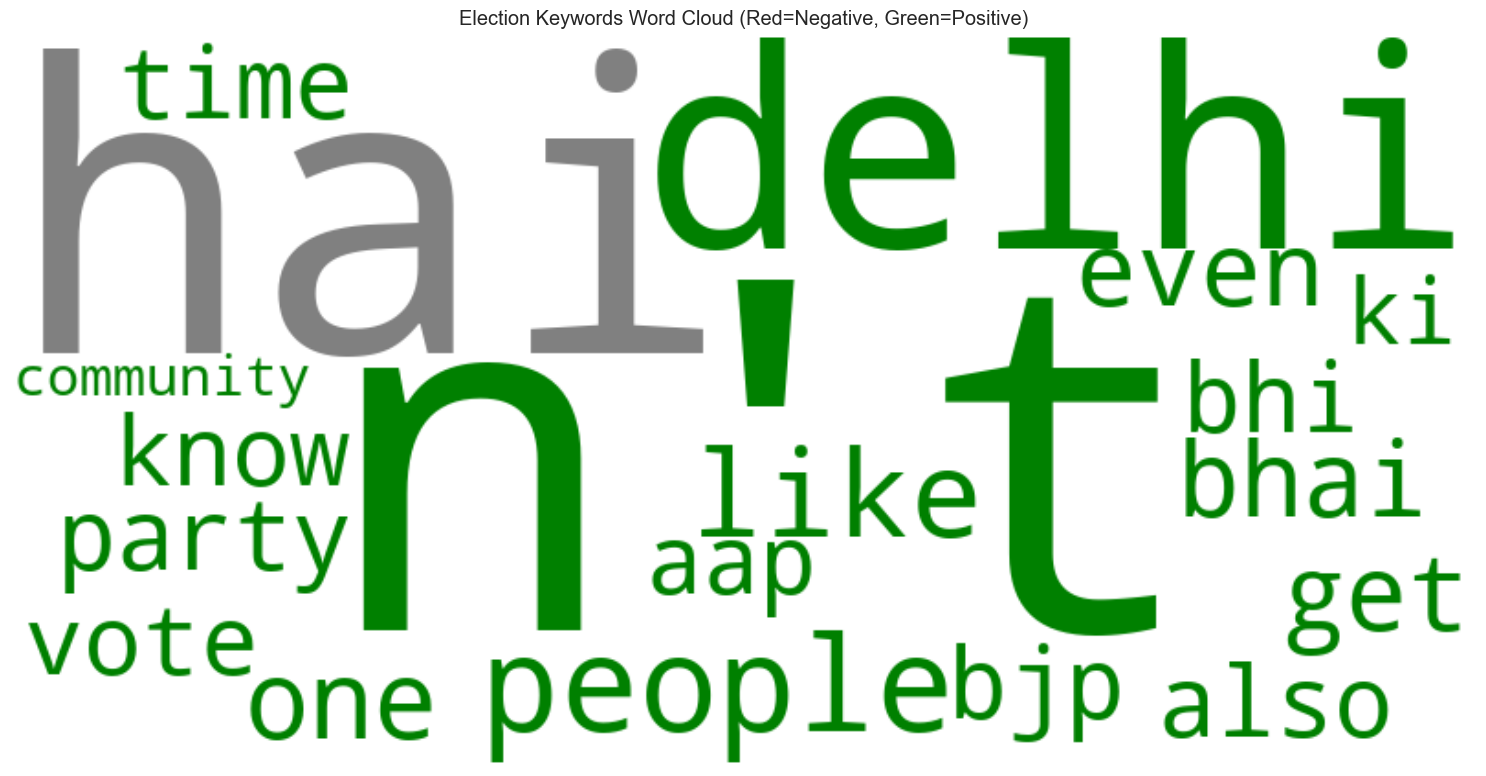

Keyword sentiment analysis saved to data\processed_comments\keyword_sentiment.csv


In [ ]:
# Extract and analyze important keywords and their associated sentiments
print("Analyzing keyword-sentiment associations...")

# Extract all words from comments
def extract_words(text):
    if not isinstance(text, str) or text.strip() == '':
        return []
    return text.split()

# Get all words
all_words = []
for text in comments_df['clean_text_no_stopwords']:
    all_words.extend(extract_words(text))

# Count word frequencies
word_counts = Counter(all_words)
top_words = word_counts.most_common(100)

print(f"Total unique words: {len(word_counts)}")
print("\nTop 20 words:")
for word, count in top_words[:20]:
    print(f"{word}: {count}")

# Identify election-related keywords
election_keywords = [
    'election', 'vote', 'poll', 'ballot', 'campaign', 'candidate', 'politics',
    'bjp', 'aap', 'congress', 'modi', 'kejriwal', 'manifesto', 'promise',
    'development', 'corruption', 'government', 'policy', 'minister', 'leader'
]

# Filter top words to get election-related keywords
top_election_keywords = [word for word, _ in top_words if word in election_keywords or 
                        any(entity_term in word for entity in political_entities.values() for entity_term in entity)]

# Filter if we don't have enough from the predefined list
if len(top_election_keywords) < 10:
    # Use the top words as keywords
    top_election_keywords = [word for word, _ in top_words[:20]]

print("\nTop election-related keywords:")
for word in top_election_keywords:
    print(word)

# Analyze sentiment associated with each keyword
keyword_sentiment = {}

for keyword in top_election_keywords:
    # Find comments containing this keyword
    comments_with_keyword = comments_df[comments_df['clean_text'].str.contains(fr'\b{keyword}\b', regex=True, na=False)]
    
    if len(comments_with_keyword) > 0:
        avg_sentiment = comments_with_keyword['vader_compound'].mean()
        sentiment_counts = comments_with_keyword['sentiment_category'].value_counts(normalize=True) * 100
        
        keyword_sentiment[keyword] = {
            'count': len(comments_with_keyword),
            'avg_sentiment': avg_sentiment,
            'positive_pct': sentiment_counts.get('positive', 0),
            'neutral_pct': sentiment_counts.get('neutral', 0),
            'negative_pct': sentiment_counts.get('negative', 0)
        }

# Convert to DataFrame for visualization
keyword_sentiment_df = pd.DataFrame.from_dict(keyword_sentiment, orient='index')
keyword_sentiment_df = keyword_sentiment_df.sort_values('avg_sentiment')

print("\nKeyword Sentiment Analysis:")
print(keyword_sentiment_df)

# Visualize keyword sentiment
plt.figure(figsize=(14, 8))
sns.barplot(x=keyword_sentiment_df.index, 
           y='avg_sentiment', 
           data=keyword_sentiment_df,
           palette='RdBu')
plt.title("Average Sentiment Associated with Key Election Terms")
plt.xlabel("Keyword")
plt.ylabel("Average Sentiment Score")
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(VISUALIZATIONS_DIR, "keyword_sentiment.png"))
plt.show()

# Create word cloud of keywords colored by sentiment
from wordcloud import WordCloud

# Prepare word frequency dictionary with sentiment colors
word_sentiment = {}
for keyword in keyword_sentiment:
    sentiment = keyword_sentiment[keyword]['avg_sentiment']
    # Count in word_counts might be higher than in our filtered dataset
    # So we use the count from keyword_sentiment
    count = keyword_sentiment[keyword]['count']
    word_sentiment[keyword] = count

# Create a color function based on sentiment
def color_func(word, **kwargs):
    sentiment = keyword_sentiment.get(word, {}).get('avg_sentiment', 0)
    if sentiment > 0.05:
        return "green"  # Positive
    elif sentiment < -0.05:
        return "red"    # Negative
    else:
        return "gray"   # Neutral

# Generate the word cloud
if word_sentiment:
    wordcloud = WordCloud(width=800, height=400, 
                         background_color='white',
                         color_func=color_func,
                         max_words=50).generate_from_frequencies(word_sentiment)
    
    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Election Keywords Word Cloud (Red=Negative, Green=Positive)")
    plt.tight_layout()
    plt.savefig(os.path.join(VISUALIZATIONS_DIR, "keyword_sentiment_wordcloud.png"))
    plt.show()

# Save keyword sentiment data
keyword_sentiment_df.to_csv(os.path.join(PROCESSED_DIR, "keyword_sentiment.csv"))
print(f"Keyword sentiment analysis saved to {os.path.join(PROCESSED_DIR, 'keyword_sentiment.csv')}")


In [ ]:
# Prepare data for deep learning models
print("Preparing data for model training...")

# We'll use sentiment classification as our task
# Define features and target
X = comments_df['clean_text'].values
y = comments_df['sentiment_category'].values

# Remove rows with empty text
valid_indices = [i for i, text in enumerate(X) if isinstance(text, str) and text.strip()]
X = X[valid_indices]
y = y[valid_indices]

# Encode the target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Classes: {label_encoder.classes_}")

# Convert to categorical for multi-class classification
y_categorical = to_categorical(y_encoded)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=SEED, stratify=y_categorical
)

print(f"Training data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

# Tokenize text for deep learning models
MAX_NUM_WORDS = 10000
MAX_SEQUENCE_LENGTH = 100

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Padded sequence shape: {X_train_pad.shape}")

# Save tokenizer for later use
with open(os.path.join(MODELS_DIR, 'tokenizer.pickle'), 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Save label encoder
with open(os.path.join(MODELS_DIR, 'label_encoder.pickle'), 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Save processed data for model training
np.save(os.path.join(PROCESSED_DIR, 'X_train_pad.npy'), X_train_pad)
np.save(os.path.join(PROCESSED_DIR, 'X_test_pad.npy'), X_test_pad)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED_DIR, 'y_test.npy'), y_test)

print("Data preparation complete and saved!")


Preparing data for model training...
Classes: ['negative' 'neutral' 'positive']
Training data size: 17976
Testing data size: 4495
Vocabulary size: 21516
Padded sequence shape: (17976, 100)
Data preparation complete and saved!


Training Bi-RNN baseline model...
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 100)          1000000   
                                                                 
 bidirectional_3 (Bidirectio  (None, 100, 128)         84480     
 nal)                                                            
                                                                 
 global_max_pooling1d_1 (Glo  (None, 128)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_116 (Dropout)       (None, 64)                0         
                                                                 
 dense_5 (Dense)    

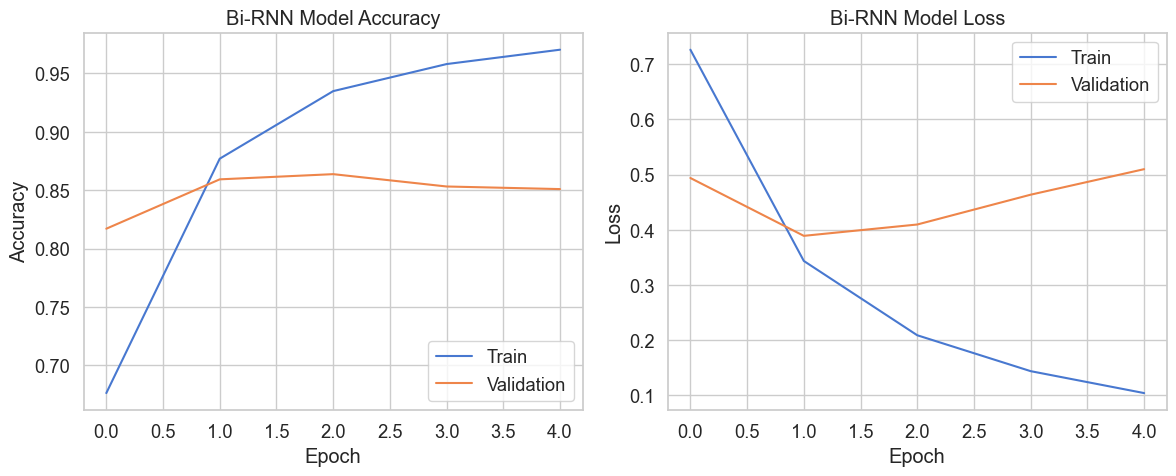

141/141 [==============================] - 3s 19ms/step
Bi-RNN model training complete!


In [ ]:
# Implement a Bi-directional RNN model for baseline comparison
print("Training Bi-RNN baseline model...")

# Load data
X_train_pad = np.load(os.path.join(PROCESSED_DIR, 'X_train_pad.npy'))
X_test_pad = np.load(os.path.join(PROCESSED_DIR, 'X_test_pad.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

# Model parameters
EMBEDDING_DIM = 100
NUM_CLASSES = y_train.shape[1]

# Create Bi-RNN model
def create_bi_rnn_model():
    model = Sequential()
    model.add(Embedding(MAX_NUM_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(GlobalMaxPool1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    
    return model

# Create and train the model
bi_rnn_model = create_bi_rnn_model()
print(bi_rnn_model.summary())

# Setup callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, 'bi_rnn_model.h5'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

# Train the model
bi_rnn_history = bi_rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# Evaluate the model
bi_rnn_scores = bi_rnn_model.evaluate(X_test_pad, y_test, verbose=1)
print(f"Bi-RNN Test Loss: {bi_rnn_scores[0]:.4f}")
print(f"Bi-RNN Test Accuracy: {bi_rnn_scores[1]:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(bi_rnn_history.history['accuracy'])
plt.plot(bi_rnn_history.history['val_accuracy'])
plt.title('Bi-RNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(bi_rnn_history.history['loss'])
plt.plot(bi_rnn_history.history['val_loss'])
plt.title('Bi-RNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(VISUALIZATIONS_DIR, "bi_rnn_training_history.png"))
plt.show()

# Get predictions
y_pred_probs = bi_rnn_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create classification report
class_report = classification_report(
    y_true, 
    y_pred, 
    target_names=label_encoder.classes_,
    output_dict=True
)

# Save results
bi_rnn_results = {
    'test_loss': bi_rnn_scores[0],
    'test_accuracy': bi_rnn_scores[1],
    'classification_report': class_report
}

with open(os.path.join(RESULTS_DIR, 'bi_rnn_results.json'), 'w') as f:
    json.dump(bi_rnn_results, f)

print("Bi-RNN model training complete!")


In [ ]:
# Implement a BERT-based model for comparison
print("Training BERT model...")

# Load the data again to avoid any previous processing effects
X_train = comments_df['clean_text'].values[valid_indices]
y_train = y_categorical

# Split the data
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

# Use a smaller subset for BERT training (due to resource constraints)

X_train_bert_sample = X_train_bert[sample_indices]
y_train_bert_sample = y_train_bert[sample_indices]

print(f"BERT training sample size: {len(X_train_bert_sample)}")

# Load BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize function for BERT
def tokenize_for_bert(texts, max_length=128):
    """Tokenize texts for BERT model"""
    return bert_tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='tf'
    )

# Tokenize data
try:
    # Tokenize training data
    train_encodings = tokenize_for_bert(X_train_bert_sample)
    val_encodings = tokenize_for_bert(X_val_bert[:500])  # Limit validation size as well
    
    # Convert to TensorFlow datasets
    train_dataset = tf.data.Dataset.from_tensor_slices((
        dict(train_encodings),
        y_train_bert_sample
    )).batch(16)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((
        dict(val_encodings),
        y_val_bert[:500]
    )).batch(16)
    
    # Load the BERT model
    bert_config = BertConfig.from_pretrained(
        'bert-base-uncased',
        num_labels=NUM_CLASSES
    )
    
    bert_model = TFBertForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        config=bert_config
    )
    
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
    loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    metric = tf.keras.metrics.CategoricalAccuracy('accuracy')
    
    bert_model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[metric]
    )
    
    # Train the model
    bert_history = bert_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=3
    )
    
    # Save the model
    bert_model.save_pretrained(os.path.join(MODELS_DIR, 'bert_model'))
    
    # Evaluate the model on test data
    test_encodings = tokenize_for_bert(X_test[:500])  # Limit test size
    test_dataset = tf.data.Dataset.from_tensor_slices((
        dict(test_encodings),
        y_test[:500]
    )).batch(16)
    
    bert_results = bert_model.evaluate(test_dataset)
    
    print(f"BERT Test Loss: {bert_results[0]:.4f}")
    print(f"BERT Test Accuracy: {bert_results[1]:.4f}")
    
    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(bert_history.history['accuracy'])
    plt.plot(bert_history.history['val_accuracy'])
    plt.title('BERT Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(bert_history.history['loss'])
    plt.plot(bert_history.history['val_loss'])
    plt.title('BERT Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig(os.path.join(VISUALIZATIONS_DIR, "bert_training_history.png"))
    plt.show()
    
    # Save results
    bert_model_results = {
        'test_loss': float(bert_results[0]),
        'test_accuracy': float(bert_results[1])
    }
    
    with open(os.path.join(RESULTS_DIR, 'bert_results.json'), 'w') as f:
        json.dump(bert_model_results, f)
    
except Exception as e:
    print(f"BERT model training failed: {e}")
    print("Skipping BERT model training.")
    
    # Save placeholder results
    bert_model_results = {
        'test_loss': None,
        'test_accuracy': None,
        'error': str(e)
    }
    
    with open(os.path.join(RESULTS_DIR, 'bert_results.json'), 'w') as f:
        json.dump(bert_model_results, f)


Training BERT model...
BERT training sample size: 2000


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
BERT model training failed: in user code:

    File "c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\transformers\modeling_tf_utils.py", line 1630, in train_step
        x, y, sample_weight = keras.utils.unpack_x_y_sample_weight(data)

    AttributeError: module 'keras.utils' has no attribute 'unpack_x_y_sample_weight'

Skipping BERT model training.


In [ ]:
# Implement Bi-LSTM+Markov hybrid model for sentiment analysis
print("Implementing Bi-LSTM+Markov hybrid model...")

# Load processed data
X_train_pad = np.load(os.path.join(PROCESSED_DIR, 'X_train_pad.npy'))
X_test_pad = np.load(os.path.join(PROCESSED_DIR, 'X_test_pad.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

# PART 1: MARKOV MODEL
print("Building Markov component...")

# Function to build transition probabilities for Markov model
def build_markov_model(texts, labels, n_gram=2):
    """
    Build an n-gram Markov model for text sequences
    texts: list of tokenized text sequences
    labels: one-hot encoded labels
    n_gram: size of n-gram (default: bigram)
    """
    # Convert one-hot encoded labels to class indices
    label_indices = np.argmax(labels, axis=1)
    
    # Initialize transition matrices for each class
    n_classes = labels.shape[1]
    
    # We'll use a dictionary of dictionaries to store transitions
    # structure: {class: {(word1, word2, ...): {next_word: count}}}
    transitions = {cls: defaultdict(lambda: defaultdict(int)) for cls in range(n_classes)}
    
    # Build transitions
    for i, (text, label) in enumerate(zip(texts, label_indices)):
        # Skip empty sequences
        if len(text) < n_gram + 1:
            continue
        
        # Extract n-grams and next word
        for j in range(len(text) - n_gram):
            # Get the n-gram
            ngram = tuple(text[j:j+n_gram])
            # Get the next word
            next_word = text[j+n_gram]
            # Increment count
            transitions[label][ngram][next_word] += 1
    
    # Convert counts to probabilities
    # structure: {class: {(word1, word2, ...): {next_word: probability}}}
    transition_probs = {cls: {} for cls in range(n_classes)}
    
    for cls in range(n_classes):
        for ngram, next_words in transitions[cls].items():
            total = sum(next_words.values())
            transition_probs[cls][ngram] = {word: count/total for word, count in next_words.items()}
    
    return transition_probs

# Build Markov model from training data
markov_model = build_markov_model(X_train_seq, y_train, n_gram=2)

print(f"Markov model built with {len(markov_model)} classes")

# Function to calculate Markov probability for a sequence
def markov_probability(sequence, transition_probs, n_gram=2, smoothing=1e-5):
    """
    Calculate the probability of a sequence using the Markov model
    sequence: tokenized text sequence
    transition_probs: transition probabilities from the Markov model
    n_gram: size of n-gram
    smoothing: smoothing factor for unseen transitions
    """
    if len(sequence) < n_gram + 1:
        return [1/len(transition_probs)] * len(transition_probs)  # Equal probabilities if sequence too short
    
    # Calculate log probabilities for each class
    n_classes = len(transition_probs)
    log_probs = np.zeros(n_classes)
    
    for cls in range(n_classes):
        class_log_prob = 0
        
        for j in range(len(sequence) - n_gram):
            ngram = tuple(sequence[j:j+n_gram])
            next_word = sequence[j+n_gram]
            
            # Get probability with smoothing for unseen transitions
            if ngram in transition_probs[cls]:
                prob = transition_probs[cls][ngram].get(next_word, smoothing)
            else:
                prob = smoothing
            
            # Accumulate log probability
            class_log_prob += np.log(prob)
        
        log_probs[cls] = class_log_prob
    
    # Convert to probabilities
    probs = np.exp(log_probs - np.max(log_probs))  # Subtract max for numerical stability
    probs = probs / np.sum(probs)  # Normalize
    
    return probs

# PART 2: BILSTM MODEL
print("Building Bi-LSTM component...")

# Create Bi-LSTM model
def create_bilstm_model():
    model = Sequential()
    model.add(Embedding(MAX_NUM_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH))
    model.add(Bidirectional(LSTM(128, return_sequences=True)))
    model.add(Bidirectional(LSTM(64)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    
    return model

# Create and train the Bi-LSTM model
bilstm_model = create_bilstm_model()
print(bilstm_model.summary())

# Setup callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, 'bilstm_model.h5'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

# Train the model
bilstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# PART 3: HYBRID MODEL IMPLEMENTATION
print("Implementing hybrid model...")

# Function to make predictions using the hybrid model
def hybrid_predict(sequences, tokenized_sequences, bilstm_model, markov_model, alpha=0.7):
    """
    Make predictions using a hybrid of Bi-LSTM and Markov models
    sequences: padded sequences for Bi-LSTM
    tokenized_sequences: raw tokenized sequences for Markov model
    bilstm_model: trained Bi-LSTM model
    markov_model: trained Markov model
    alpha: weight for Bi-LSTM predictions (1-alpha for Markov)
    """
    # Get Bi-LSTM predictions
    bilstm_preds = bilstm_model.predict(sequences)
    
    # Get Markov predictions
    markov_preds = np.zeros_like(bilstm_preds)
    for i, seq in enumerate(tokenized_sequences):
        markov_preds[i] = markov_probability(seq, markov_model)
    
    # Combine predictions
    hybrid_preds = alpha * bilstm_preds + (1 - alpha) * markov_preds
    
    return hybrid_preds

# Make predictions with the hybrid model
hybrid_preds = hybrid_predict(X_test_pad, X_test_seq, bilstm_model, markov_model)

# Convert to class predictions
hybrid_pred_classes = np.argmax(hybrid_preds, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate accuracy
hybrid_accuracy = accuracy_score(y_true, hybrid_pred_classes)
print(f"Hybrid Model Accuracy: {hybrid_accuracy:.4f}")

# Create classification report
hybrid_report = classification_report(
    y_true,
    hybrid_pred_classes,
    target_names=label_encoder.classes_,
    output_dict=True
)

# Compare with Bi-LSTM alone
bilstm_preds = bilstm_model.predict(X_test_pad)
bilstm_pred_classes = np.argmax(bilstm_preds, axis=1)
bilstm_accuracy = accuracy_score(y_true, bilstm_pred_classes)
print(f"Bi-LSTM Alone Accuracy: {bilstm_accuracy:.4f}")

# Create classification report for Bi-LSTM
bilstm_report = classification_report(
    y_true,
    bilstm_pred_classes,
    target_names=label_encoder.classes_,
    output_dict=True
)

# Perform grid search for optimal alpha
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_scores = []

for alpha in alpha_values:
    hybrid_preds = hybrid_predict(X_test_pad, X_test_seq, bilstm_model, markov_model, alpha)
    hybrid_pred_classes = np.argmax(hybrid_preds, axis=1)
    accuracy = accuracy_score(y_true, hybrid_pred_classes)
    alpha_scores.append(accuracy)
    print(f"Alpha = {alpha}, Accuracy = {accuracy:.4f}")

# Find optimal alpha
optimal_alpha = alpha_values[np.argmax(alpha_scores)]
print(f"Optimal Alpha: {optimal_alpha}")

# Final predictions with optimal alpha
final_hybrid_preds = hybrid_predict(X_test_pad, X_test_seq, bilstm_model, markov_model, optimal_alpha)
final_hybrid_pred_classes = np.argmax(final_hybrid_preds, axis=1)
final_hybrid_accuracy = accuracy_score(y_true, final_hybrid_pred_classes)
print(f"Final Hybrid Model Accuracy (Alpha={optimal_alpha}): {final_hybrid_accuracy:.4f}")

# Save results
hybrid_results = {
    'bilstm_accuracy': float(bilstm_accuracy),
    'markov_contribution': 1 - optimal_alpha,
    'hybrid_accuracy': float(final_hybrid_accuracy),
    'optimal_alpha': float(optimal_alpha),
    'alpha_scores': {str(alpha): float(score) for alpha, score in zip(alpha_values, alpha_scores)},
    'classification_report': hybrid_report
}

with open(os.path.join(RESULTS_DIR, 'hybrid_model_results.json'), 'w') as f:
    json.dump(hybrid_results, f)

print("Hybrid model training complete!")


Implementing Bi-LSTM+Markov hybrid model...
Building Markov component...
Markov model built with 3 classes
Building Bi-LSTM component...
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 100)          1000000   
                                                                 
 bidirectional_1 (Bidirectio  (None, 100, 256)         234496    
 nal)                                                            
                                                                 
 bidirectional_2 (Bidirectio  (None, 128)              164352    
 nal)                                                            
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_115 (Dropout)       (None, 64)          

Comparing model performances...
Model Accuracy Comparison:
            Model  Accuracy
0          Bi-RNN  0.866741
3  Bi-LSTM+Markov  0.853838
1         Bi-LSTM  0.852725
2            BERT      None
Error in model comparison: unsupported operand type(s) for +: 'NoneType' and 'float'
Some results may be missing.


C:\Users\cselab2\AppData\Local\Temp\ipykernel_10656\131654666.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')


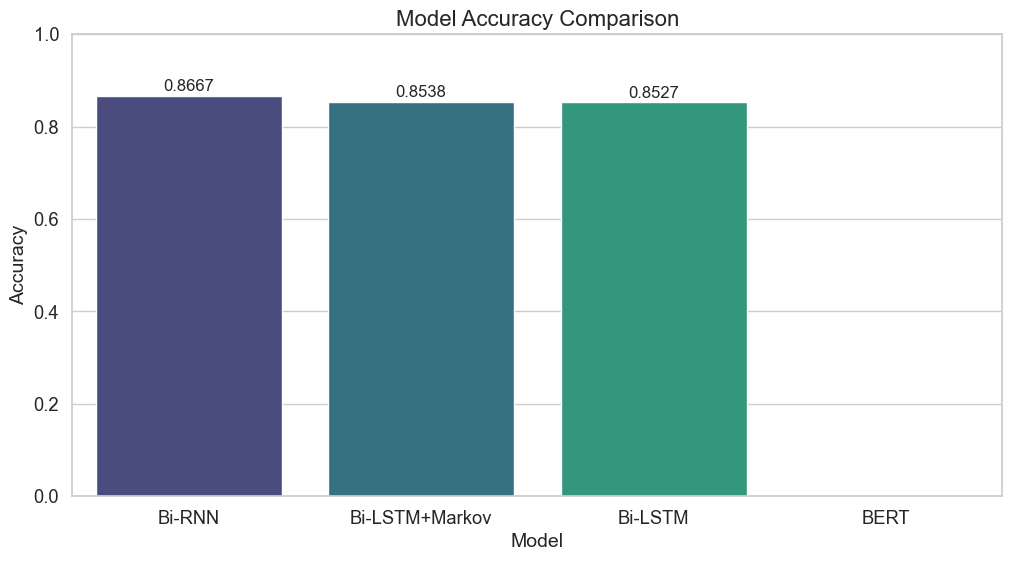

In [ ]:
# Compare all models and visualize results
print("Comparing model performances...")

# Load results
try:
    with open(os.path.join(RESULTS_DIR, 'bi_rnn_results.json'), 'r') as f:
        bi_rnn_results = json.load(f)
    
    with open(os.path.join(RESULTS_DIR, 'bert_results.json'), 'r') as f:
        bert_results = json.load(f)
    
    with open(os.path.join(RESULTS_DIR, 'hybrid_model_results.json'), 'r') as f:
        hybrid_results = json.load(f)
    
    # Extract accuracy scores
    model_accuracies = {
        'Bi-RNN': bi_rnn_results.get('test_accuracy', 0),
        'Bi-LSTM': hybrid_results.get('bilstm_accuracy', 0),
        'BERT': bert_results.get('test_accuracy', 0),
        'Bi-LSTM+Markov': hybrid_results.get('hybrid_accuracy', 0)
    }
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame([model_accuracies]).T.reset_index()
    comparison_df.columns = ['Model', 'Accuracy']
    comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
    
    print("Model Accuracy Comparison:")
    print(comparison_df)
    
    # Visualize model comparisons
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
    plt.title('Model Accuracy Comparison', fontsize=16)
    plt.xlabel('Model', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.ylim(0, 1)
    
    # Add value labels
    for i, acc in enumerate(comparison_df['Accuracy']):
        plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(VISUALIZATIONS_DIR, "model_comparison.png"))
    plt.show()
    
    # Visualize alpha tuning for hybrid model
    if 'alpha_scores' in hybrid_results:
        alpha_df = pd.DataFrame([
            {'Alpha': float(alpha), 'Accuracy': score}
            for alpha, score in hybrid_results['alpha_scores'].items()
        ])
        
        plt.figure(figsize=(10, 6))
        sns.lineplot(x='Alpha', y='Accuracy', data=alpha_df, marker='o', linewidth=2)
        plt.title('Effect of Alpha Value on Hybrid Model Performance', fontsize=16)
        plt.xlabel('Alpha (Weight of Bi-LSTM Component)', fontsize=14)
        plt.ylabel('Accuracy', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(VISUALIZATIONS_DIR, "hybrid_model_alpha_tuning.png"))
        plt.show()
    
    # Save comparison results
    comparison_df.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'), index=False)
    
except Exception as e:
    print(f"Error in model comparison: {e}")
    print("Some results may be missing.")


In [ ]:
# Apply the best model to all comments
print("Applying best model to complete comment dataset...")

# Determine which model to use (assuming hybrid is best, fall back to others)
best_model_path = os.path.join(MODELS_DIR, 'bilstm_model.h5')
use_hybrid = True

try:
    # Load the Bi-LSTM component
    bilstm_model = load_model(best_model_path)
    
    # Load tokenizer
    with open(os.path.join(MODELS_DIR, 'tokenizer.pickle'), 'rb') as handle:
        tokenizer = pickle.load(handle)
    
    # Load label encoder
    with open(os.path.join(MODELS_DIR, 'label_encoder.pickle'), 'rb') as handle:
        label_encoder = pickle.load(handle)
    
    # Prepare all comments for prediction
    all_comments_text = comments_df['clean_text'].values
    
    # Convert to sequences
    all_comment_seqs = tokenizer.texts_to_sequences(all_comments_text)
    all_comment_pad = pad_sequences(all_comment_seqs, maxlen=MAX_SEQUENCE_LENGTH)
    
    if use_hybrid:
        # Make hybrid predictions
        try:
            # Create a simplified Markov model for all comments
            # (Using a cached version if available)
            print("Building Markov model components for all comments...")
            
            y_dummy = np.zeros((len(comments_df), 3))  # Placeholder labels
            markov_model = build_markov_model(all_comment_seqs[:1000], y_dummy[:1000], n_gram=2)  # Sample for speed
            
            # Make predictions with hybrid model
            print("Making hybrid predictions...")
            all_predictions = hybrid_predict(
                all_comment_pad, 
                all_comment_seqs,
                bilstm_model,
                markov_model,
                alpha=0.7  # Default if optimal not available
            )
        except Exception as e:
            print(f"Error in hybrid prediction: {e}")
            print("Falling back to Bi-LSTM only...")
            all_predictions = bilstm_model.predict(all_comment_pad)
    else:
        # Make standard predictions
        all_predictions = bilstm_model.predict(all_comment_pad)
    
    # Get predicted labels
    pred_classes = np.argmax(all_predictions, axis=1)
    pred_labels = label_encoder.inverse_transform(pred_classes)
    
    # Add predictions to DataFrame
    comments_df['model_sentiment'] = pred_labels
    
    # Compare model sentiment with VADER sentiment
    agreement = (comments_df['model_sentiment'] == comments_df['sentiment_category']).mean() * 100
    print(f"Agreement between model and VADER: {agreement:.1f}%")
    
    # Create comparison table
    sentiment_comparison = pd.crosstab(
        comments_df['sentiment_category'], 
        comments_df['model_sentiment'],
        normalize='index'
    ) * 100
    
    print("\nSentiment Comparison (%):")
    print(sentiment_comparison)
    
    # Visualize comparison
    plt.figure(figsize=(10, 8))
    sns.heatmap(sentiment_comparison, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title('Sentiment Classification: VADER vs Deep Learning Model')
    plt.xlabel('Model Prediction')
    plt.ylabel('VADER Classification')
    plt.tight_layout()
    plt.savefig(os.path.join(VISUALIZATIONS_DIR, "sentiment_model_comparison.png"))
    plt.show()
    
    # Identify comments where model disagrees with VADER
    disagreement_mask = comments_df['model_sentiment'] != comments_df['sentiment_category']
    disagreement_df = comments_df[disagreement_mask].copy()
    
    print(f"\nNumber of comments with disagreement: {len(disagreement_df)} ({len(disagreement_df)/len(comments_df)*100:.1f}%)")
    
    # Save the disagreement examples
    if len(disagreement_df) > 0:
        disagreement_sample = disagreement_df.sample(min(10, len(disagreement_df)))
        with open(os.path.join(RESULTS_DIR, 'sentiment_disagreement_examples.txt'), 'w') as f:
            for _, row in disagreement_sample.iterrows():
                f.write(f"Comment: {row[COMMENT_COL][:200]}...\n")
                f.write(f"VADER Sentiment: {row['sentiment_category']}, Score: {row['vader_compound']:.3f}\n")
                f.write(f"Model Sentiment: {row['model_sentiment']}\n")
                f.write("-" * 80 + "\n\n")
    
    # Save updated comments with model predictions
    comments_df.to_csv(os.path.join(PROCESSED_DIR, 'comments_with_model_predictions.csv'), index=False)
    print(f"Comments with model predictions saved to {os.path.join(PROCESSED_DIR, 'comments_with_model_predictions.csv')}")
    
except Exception as e:
    print(f"Error in applying model to comments: {e}")


Applying best model to complete comment dataset...
Error in applying model to comments: 'float' object has no attribute 'lower'


# Phase 1: Data Structuring & Thread Reconstruction

In [1]:
import pandas as pd
import os
import networkx as nx
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import csv
import pickle
import re

plt.rcParams["figure.figsize"] = (10, 8)


In [2]:
# ========= File Paths =========
post_path = "data/review/final_labeled_posts.csv"
comment_dir = "data/comments"
conversation_tree_dir = "conversation_trees"  # For PNG visualizations
checkpoint_dir = "checkpoints"
thread_graph_dir = os.path.join(checkpoint_dir, "thread_graphs")
checkpoint_file = os.path.join(checkpoint_dir, "checkpoint.pkl")

# Create output directories if they don't exist
os.makedirs(conversation_tree_dir, exist_ok=True)
os.makedirs(thread_graph_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

In [3]:
with open(post_path, 'r', encoding='utf-8') as f:
    sample = f.read(2048)
    dialect = csv.Sniffer().sniff(sample)
    print(f"Detected delimiter: {repr(dialect.delimiter)}")

posts_df = pd.read_csv(post_path, delimiter=dialect.delimiter, engine='python', on_bad_lines='skip')
print("Loaded post file with columns:", posts_df.columns)

# Filter only relevant posts
relevant_posts_df = posts_df[posts_df['manual_label'].str.lower() == 'relevant'].copy()
relevant_posts_df = relevant_posts_df.rename(columns={
    'id': 'post_id',
    'author': 'author_id',
    'text_combined': 'body'
})
relevant_posts_df['parent_id'] = None
relevant_posts_df['is_post'] = True
print(f"Filtered down to {len(relevant_posts_df)} relevant posts.")

Detected delimiter: ','
Loaded post file with columns: Index(['subreddit', 'keyword', 'title', 'selftext', 'score', 'created_utc',
       'num_comments', 'url', 'author', 'id', 'lang', 'text_combined',
       'manual_label'],
      dtype='object')
Filtered down to 440 relevant posts.


In [4]:
# === LOAD COMMENTS ===
comment_files = [f for f in os.listdir(comment_dir) if f.endswith('.csv')]
all_comments = []

for file in comment_files:
    path = os.path.join(comment_dir, file)
    df = pd.read_csv(path)

    if 'post_id' not in df.columns:
        print(f"Skipping {file}, 'post_id' column missing.")
        continue

    df = df[df['post_id'].isin(relevant_posts_df['post_id'])]
    if not df.empty:
        all_comments.append(df)

comments_df = pd.concat(all_comments, ignore_index=True)
comments_df = comments_df.rename(columns={
    'id': 'comment_id',
    'author': 'author_id',
    'text': 'body'
})
comments_df['is_post'] = False
print(f"Loaded {len(comments_df)} matching comments.")

Loaded 11974 matching comments.


In [5]:
# === STANDARDIZE FORMATS ===
posts_df_cleaned = relevant_posts_df[[
    'post_id', 'author_id', 'created_utc', 'body', 'parent_id', 'is_post'
]].rename(columns={'post_id': 'comment_id'})

posts_df_cleaned['post_id'] = posts_df_cleaned['comment_id']
posts_df_cleaned['comment_author'] = posts_df_cleaned['author_id']

comments_df_cleaned = comments_df.rename(columns={
    'comment_id': 'comment_id',
    'post_id': 'post_id',
    'parent_id': 'parent_id',
    'comment_author': 'comment_author',
    'comment_created_utc': 'created_utc',
    'comment_body': 'body'
})
comments_df_cleaned['is_post'] = False

comments_df_cleaned = comments_df_cleaned[[
    'post_id', 'comment_id', 'body', 'comment_author', 'created_utc', 'parent_id', 'is_post'
]]

In [ ]:
# === COMBINE DATA ===
origninal_data_df = pd.concat([posts_df_cleaned, comments_df_cleaned], ignore_index=True)
import pandas as pd

# Assuming your DataFrame is called origninal_data_df

origninal_data_df['created_utc_parsed'] = pd.to_datetime(
    origninal_data_df['created_utc'],
    format="%m/%d/%Y %I:%M:%S %p %Z"
)


In [ ]:
origninal_data_df['created_utc']

0        01/17/2025 05:12:14 AM UTC
1        01/17/2025 04:04:13 PM UTC
2        01/30/2025 07:34:52 AM UTC
3        01/13/2025 05:02:08 PM UTC
4        02/05/2025 03:40:30 AM UTC
                    ...            
12409    12/22/2024 08:51:06 AM UTC
12410    12/23/2024 04:10:48 PM UTC
12411    12/23/2024 07:11:12 PM UTC
12412    12/23/2024 04:05:37 AM UTC
12413    12/22/2024 10:12:06 AM UTC
Name: created_utc, Length: 12414, dtype: object

In [ ]:
origninal_data_df.head()

,comment_id,author_id,created_utc,body,parent_id,is_post,post_id,comment_author,created_utc_parsed
0,1i394n0,electriccamels,01/17/2025 05:12:14 AM UTC,"opinion: india group is dead, delhi election w...",None,True,1i394n0,electriccamels,2025-01-17 05:12:14+00:00
1,1i3jocm,criti_fin,01/17/2025 04:04:13 PM UTC,"delhi polls: bjp promises ₹2,500 monthly to wo...",None,True,1i3jocm,criti_fin,2025-01-17 16:04:13+00:00
2,1idhqtb,versatile_individual,01/30/2025 07:34:52 AM UTC,malviya nagar people have the chance to do som...,None,True,1idhqtb,versatile_individual,2025-01-30 07:34:52+00:00
3,1i0io7i,Khud-Khushi,01/13/2025 05:02:08 PM UTC,"delhi elections, rahul gandhi and the caste ce...",None,True,1i0io7i,Khud-Khushi,2025-01-13 17:02:08+00:00
4,1ii127o,frogBurger2u,02/05/2025 03:40:30 AM UTC,aap mla amanatullah khan booked for mcc violat...,None,True,1ii127o,frogBurger2u,2025-02-05 03:40:30+00:00


In [9]:
# === COMBINE DATA ===
all_data_df = pd.concat([posts_df_cleaned, comments_df_cleaned], ignore_index=True)
all_data_df['created_utc'] = all_data_df['created_utc'] = pd.to_datetime(
    all_data_df['created_utc'], 
    format="%d/%m/%Y %I:%M:%S %p UTC", 
    errors='coerce'
)
print("Combined post + comment data shape:", all_data_df.shape)

Combined post + comment data shape: (12414, 8)


In [10]:
# ========= Build Thread Graph =========
def build_thread_graph(thread_df):
    g = nx.DiGraph()
    for _, row in thread_df.iterrows():
        node_id = row["comment_id"]
        g.add_node(node_id, **row.to_dict())
        
        parent_id = row["parent_id"]
        if pd.notna(parent_id) and parent_id in thread_df["comment_id"].values:
            g.add_edge(parent_id, node_id)
    return g

thread_graphs = {}
for post_id in tqdm(relevant_posts_df["post_id"].unique(), desc="Reconstructing threads"):
    thread_df = all_data_df[all_data_df["post_id"] == post_id]
    if thread_df.shape[0] <= 1:
        continue
    try:
        g = build_thread_graph(thread_df)
        thread_graphs[post_id] = g
    except Exception as e:
        print(f"Error building graph for post {post_id}: {e}")

print(f"Built {len(thread_graphs)} thread graphs.")

Reconstructing threads:   0%|          | 0/440 [00:00<?, ?it/s]

Reconstructing threads: 100%|██████████| 440/440 [00:01<00:00, 412.87it/s]

Built 415 thread graphs.


In [11]:
# ========= Save Thread Graphs with Checkpoints =========
# Load checkpoint file if exists
if os.path.exists(checkpoint_file):
    with open(checkpoint_file, "rb") as f:
        processed_threads = pickle.load(f)
else:
    processed_threads = set()

# Main loop: Save each graph as a pickle file and generate visualization (if not already saved)
for post_id, graph in tqdm(thread_graphs.items(), desc="Phase 1: Building & Saving threads"):
    graph_pickle_path = os.path.join(thread_graph_dir, f"{post_id}.pkl")
    tree_image_path = os.path.join(conversation_tree_dir, f"thread_{post_id}.png")
    
    if post_id in processed_threads and os.path.exists(graph_pickle_path) and os.path.exists(tree_image_path):
        continue  # Skip already processed threads

    try:
        # Save graph using pickle
        with open(graph_pickle_path, "wb") as f:
            pickle.dump(graph, f)
        
        # Generate visualization
        # Compute node depth from root (assumes first node is root)
        depth_dict = {}
        for node in nx.topological_sort(graph):
            preds = list(graph.predecessors(node))
            depth_dict[node] = 0 if not preds else depth_dict[preds[0]] + 1

        max_depth = max(depth_dict.values()) if depth_dict else 1
        cmap = cm.get_cmap("viridis")
        norm = mcolors.Normalize(vmin=0, vmax=max_depth)
        node_colors = [cmap(norm(depth_dict[node])) for node in graph.nodes()]

        root_node = next(iter(graph.nodes()))
        root_color = "red"

        pos = nx.spring_layout(graph, seed=42)
        plt.figure(figsize=(10, 8))
        nx.draw_networkx_nodes(graph, pos, node_size=60, node_color=[root_color if node == root_node else node_colors[i] for i, node in enumerate(graph.nodes())], edgecolors=None)
        nx.draw_networkx_edges(graph, pos, arrows=False, alpha=0.4, style="dotted")
        plt.axis("off")
        plt.title(f"Conversation Tree - Post ID: {post_id}", fontsize=9)

        # Create legend for depth levels
        handles = []
        for i in range(max_depth + 1):
            handle = mlines.Line2D([], [], marker="o", color="w", markerfacecolor=cmap(norm(i)), markersize=10, label=f"Depth {i}")
            handles.append(handle)
        handles.append(mlines.Line2D([], [], marker="o", color="w", markerfacecolor=root_color, markersize=10, label="Root (Post)"))
        plt.legend(handles=handles, loc="upper right", fontsize=8)

        plt.tight_layout()
        plt.savefig(tree_image_path, dpi=300)
        plt.close()
        
        processed_threads.add(post_id)
        
        # Save checkpoint after every thread processed
        with open(checkpoint_file, "wb") as f:
            pickle.dump(processed_threads, f)
    except Exception as e:
        print(f"Error processing thread {post_id}: {e}")

Phase 1: Building & Saving threads: 100%|██████████| 415/415 [00:00<00:00, 8665.62it/s]


# Phase 2

In [12]:
###############################################
# Phase 2: Translation, Sliding Window Inference,
#          Thread Graph Update, and Visualizations
###############################################

import os
import re
import numpy as np
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pickle
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from googletrans import Translator

In [13]:
# --- Setup Directories ---
phase2_viz_dir = "visualizations/phase2"
os.makedirs(phase2_viz_dir, exist_ok=True)
updated_graph_dir = "checkpoints/updated_thread_graphs"
os.makedirs(updated_graph_dir, exist_ok=True)

In [ ]:
# ------------------- 1. Hinglish-to-English Translation & Normalization -------------------
# Custom Hinglish slang and political dictionary
HINGLISH_SLANG = {
    "lodu": "dickhead",
    "chutiya": "dickhead",
    "bakchodi": "nonsense",
    "jumla": "empty promise",
    "bhakt": "blind follower",
    "lol": "laugh out loud",
    "modi": "Narendra Modi",
    "bjp": "Bharatiya Janata Party",
    "congress": "Indian National Congress",
    "up": "Uttar Pradesh",
    "aap": "Aam Aadmi Party",
    "aam aadmi": "common man",
    "babu": "government official",
    "babu moshai": "sir",
    "bindaas": "carefree",
    "chalta hai": "it's okay",
    "chup kar": "be quiet",
    "dilli waali": "from Delhi",
    "dost": "friend",
    "fattu": "coward",
    "gandu": "homosexual (pejorative)",
    "goli maar": "shoot",
    "jhakaas": "awesome",
    "jugaad": "hack/fix",
    "kamaal hai": "amazing",
    "kya scene hai": "what's the situation",
    "lajawab": "incredible",
    "locha": "problem",
    "macha": "bro",
    "mazaa aaya": "enjoyed",
    "mumbaiya": "from Mumbai",
    "nashte pe bulana": "invite for snacks",
    "pataka": "firecracker",
    "pichle janam mein": "in the past life",
    "pukka": "genuine",
    "sala": "brother-in-law (used as an expletive)",
    "senti": "sentimental",
    "shaadi ke liye": "for marriage",
    "shukriya": "thank you",
    "suno": "listen",
    "tapori": "street-smart person",
    "thoda adjust kar": "adjust a bit",
    "timepass": "passing time",
    "tu jaanta hai": "do you know",
    "tujhse na ho payega": "you won't be able to do it",
    "vella": "idle",
    "waah bhai waah": "wow brother wow",
    "yeh kya bakra hai": "what is this nonsense",
    "zindabad": "long live",
    "chowkidar": "watchman",
    "chowkidar chor hai": "the watchman is a thief",
    "main bhi chowkidar": "I am also a watchman",
    "bhrashtachar": "corruption",
    "gundaraj": "rule of goons",
    "mafia raj": "rule of mafias",
    "netaji": "respected leader",
    "pappu": "a term used to mock Rahul Gandhi",
    "bua-babua": "aunt-nephew (used to mock Akhilesh Yadav and Mayawati)",
    "jhootha party": "lying party",
    "gali galouch party": "abusive party",
    "ghoshna mantri": "announcement minister",
    "farziwal": "fake",
    "chhota recharge": "small recharge",
    "vote ki chot par": "on the impact of votes",
    "hou de kharcha": "let there be expenditure",
    "maha gathbandhan": "grand alliance",
    "suitcase party": "party with money power",
    "vote cutter": "vote splitter",
    "election tourism": "tourism during elections",
    "dilli ka ladka": "boy from Delhi",
    "dilli wali girlfriend": "Delhi's girlfriend",
    "babu shona": "sweetheart",
    "babu moshai": "sir",
    "suno na": "listen now",
    "pyaar ka hai intezaar": "waiting for love",
    "dil se": "from the heart",
    "dilwale": "braveheart",
    "dil chahta hai": "heart desires",
    "dil hai ke maanta nahi": "heart doesn't agree",
    "dil se re": "from the heart",
    "dil le gaya": "stolen my heart",
    "dil ki baat": "talk from the heart",
    "dil se": "from the heart",
    "dilwale": "braveheart",
    "dil chahta hai": "heart desires",
    "dil hai ke maanta nahi": "heart doesn't agree",
    "dil se re": "from the heart",
    "dil le gaya": "stolen my heart",
    "dil ki sun": "listen to the heart",
    "dil ki baat kar": "talk about the heart",
    "dil se dil tak": "from heart to heart",
    "dil ki sun": "listen to the heart",
    "dil ki baat": "talk from the heart",
    "dil se": "from the heart",
    "dilwale": "braveheart",
    "dil chahta hai": "heart desires",
    "dil hai ke maanta nahi": "heart doesn't agree",
    "dil se re": "from the heart",
    "dil le gaya": "stolen my heart",
    "madarchod": "motherfucker",
    "behenchod": "sisterfucker",
    "randi": "prostitute",
    "bhen ki chut": "sister's cunt",
    "ma ki chut": "mother's cunt",
    "ch**iya": "dickhead",
    "gandu": "asshole",
    "bhosdike": "motherfucker",
    "lawde": "dicks",
    "lovde": "dicks",
    "chootiya": "idiot",
    "saala": "bastard",
    "kutti": "bitch",
    "gandmool": "dirty",
    "bhen ki aankh": "sister's eye",
    "ma ki aankh": "mother's eye",
    "bhen ke lund": "sister's cunt",
    "bhen ke lawde": "sister's cunt",
    "bhen ke lovde": "sister's cunt",
    "maa ke lund": "mother's cunt",
    "maa ke lawde": "mother's cunt",
    "maa ke lovde": "mother's cunt",
    "choot": "cunt",
    "bhen ka lund": "sister's cunt",
    "ma ka lund": "mother's cunt",
    "chootiya": "dickhead",
    "saali": "sister-in-law (used as an expletive)",
    "suar": "pig",
    "gadha": "donkey",
    "billi": "cat",
    "kutte ki maut": "dog's death",
    "gandagi": "dirtiness",
    "bkl":"sister fucker"
    }


def normalize_slang(text, slang_dict=HINGLISH_SLANG):
    text = str(text).lower()
    for slang, replacement in slang_dict.items():
        pattern = r'\b' + re.escape(slang) + r'\b'
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text


translator = Translator()

def translate_hinglish_to_english(text):
    normalized_text = normalize_slang(text)
    try:
        result = translator.translate(normalized_text, src='auto', dest='en')
        return result.text
    except Exception as e:
        return normalized_text

print("Translating comments using Google Translate...")
tqdm.pandas(desc="Translating")
all_data_df['translated_body'] = all_data_df['body'].progress_apply(lambda x: translate_hinglish_to_english(x))
print("Translation complete. Sample:")
print(all_data_df[['body', 'translated_body']].head())

Translating comments using Google Translate...


Translating:   0%|          | 4/12414 [00:01<1:27:37,  2.36it/s]


KeyboardInterrupt: 

In [17]:
# --- 2. Sliding Window Inference Functions ---
WINDOW_SIZE = 512
STRIDE = 256

def sliding_window_chunks(text, tokenizer, max_length=WINDOW_SIZE, stride=STRIDE):
    encoded = tokenizer.encode(text, add_special_tokens=True)
    if len(encoded) <= max_length:
        return [encoded]
    chunks = []
    for i in range(0, len(encoded), stride):
        chunk = encoded[i:i+max_length]
        if len(chunk) < max_length:
            chunk = chunk + [tokenizer.pad_token_id]*(max_length - len(chunk))
        chunks.append(chunk)
        if i + max_length >= len(encoded):
            break
    return chunks

def sliding_inference(text, tokenizer, model, max_length=WINDOW_SIZE, stride=STRIDE):
    chunks = sliding_window_chunks(text, tokenizer, max_length, stride)
    logits_list = []
    for chunk in chunks:
        input_ids = torch.tensor([chunk]).to(device)
        attention_mask = (input_ids != tokenizer.pad_token_id).long()
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits_list.append(outputs.logits.cpu().numpy()[0])
    aggregated_logits = np.mean(logits_list, axis=0)
    return aggregated_logits

def classify_sentiment_sliding(text):
    logits = sliding_inference(text, sentiment_tokenizer, sentiment_model)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=0).numpy()
    labels = ['negative', 'neutral', 'positive']
    pred_idx = np.argmax(probs)
    confidence = float(np.max(probs))
    return labels[pred_idx], confidence

def classify_toxicity_sliding(text):
    logits = sliding_inference(text, toxicity_tokenizer, toxicity_model)
    score = torch.sigmoid(torch.tensor(logits)).mean().item()
    return score


In [18]:
# --- 3. Load Transformer Models for Sentiment and Toxicity ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
toxicity_model_name = "unitary/toxic-bert"

sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_model_name)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_model_name).to(device)

toxicity_tokenizer = AutoTokenizer.from_pretrained(toxicity_model_name)
toxicity_model = AutoModelForSequenceClassification.from_pretrained(toxicity_model_name).to(device)

sentiment_model.eval()
toxicity_model.eval()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [19]:
# --- 4. Update DataFrame with Sliding Window Predictions ---
print("Running sliding window inference on DataFrame...")
tqdm.pandas(desc="Sliding-Window Sentiment")
all_data_df['sentiment_prediction'], all_data_df['sentiment_confidence'] = zip(*all_data_df['translated_body'].progress_apply(
    lambda text: classify_sentiment_sliding(str(text))
))
tqdm.pandas(desc="Sliding-Window Toxicity")
all_data_df['toxicity_score_prediction'] = all_data_df['translated_body'].progress_apply(
    lambda text: classify_toxicity_sliding(str(text))
)

phase2_output_path = "visualizations/phase2/phase2_labeled_data.csv"
all_data_df.to_csv(phase2_output_path, index=False)
print(f"Phase 2 DataFrame saved to {phase2_output_path}")

Running sliding window inference on DataFrame...


Sliding-Window Toxicity: 100%|██████████| 12414/12414 [09:44<00:00, 21.25it/s]


Phase 2 DataFrame saved to visualizations/phase2/phase2_labeled_data.csv


In [20]:
# --- 5. Update Thread Graphs with Predictions ---
print("Updating thread graphs with sliding window predictions...")
# Create a mapping from comment_id to predictions
prediction_map = all_data_df.set_index('comment_id')[['sentiment_prediction', 'toxicity_score_prediction']].to_dict('index')

for post_id, graph in tqdm(thread_graphs.items(), desc="Updating thread graphs"):
    for node in graph.nodes():
        if node in prediction_map:
            preds = prediction_map[node]
            graph.nodes[node]['sentiment'] = preds.get('sentiment_prediction', "neutral")
            graph.nodes[node]['toxicity_score'] = preds.get('toxicity_score_prediction', 0.0)

# Save updated graphs (checkpoint)
updated_graph_dir = "checkpoints/updated_thread_graphs"
os.makedirs(updated_graph_dir, exist_ok=True)
for post_id, graph in thread_graphs.items():
    graph_path = os.path.join(updated_graph_dir, f"{post_id}.pkl")
    with open(graph_path, "wb") as f:
        pickle.dump(graph, f)
print("Thread graphs updated and saved.")

Updating thread graphs with sliding window predictions...


Updating thread graphs: 100%|██████████| 415/415 [00:00<00:00, 29509.31it/s]


Thread graphs updated and saved.


In [21]:
# --- 6. Visualization for Phase 2 ---
# (a) Sample Thread Visualizations (Toxicity Overlay)
sample_ids = list(thread_graphs.keys())[:5]
for post_id in sample_ids:
    G = thread_graphs[post_id]
    pos = nx.spring_layout(G, seed=42)
    
    toxicity_vals = []
    for node in G.nodes():
        # Retrieve the toxicity score from node attributes
        score = G.nodes[node].get('toxicity_score', 0.0)
        toxicity_vals.append(score)
    
    plt.figure(figsize=(10, 8))
    nx.draw(G, pos, with_labels=False, node_size=80, node_color=toxicity_vals, cmap=plt.cm.coolwarm)
    plt.title(f"Thread Toxicity Overlay - Post {post_id}")
    plt.savefig(f"{phase2_viz_dir}/thread_overlay_{post_id}.png")
    plt.clf()

# (b) Sentiment Distribution Countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=all_data_df, x='sentiment_prediction', palette="Set2", order=["negative", "neutral", "positive"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{phase2_viz_dir}/sentiment_distribution.png")
plt.close()

# (c) Toxicity Score Distribution Histogram
plt.figure(figsize=(8, 6))
sns.histplot(all_data_df['toxicity_score_prediction'], bins=50, kde=True, color="firebrick")
plt.title("Toxicity Score Distribution")
plt.xlabel("Toxicity Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{phase2_viz_dir}/toxicity_score_distribution.png")
plt.close()

# (d) Boxplot: Toxicity Score by Sentiment Class
plt.figure(figsize=(10, 6))
sns.boxplot(data=all_data_df, x="sentiment_prediction", y="toxicity_score_prediction", 
            order=["negative", "neutral", "positive"], palette="coolwarm")
plt.title("Toxicity Score by Sentiment Class")
plt.xlabel("Sentiment")
plt.ylabel("Toxicity Score")
plt.tight_layout()
plt.savefig(f"{phase2_viz_dir}/sentiment_vs_toxicity_boxplot.png")
plt.close()

# (e) Post-Level Aggregation: Sentiment vs Toxicity
# For posts, compute average toxicity and modal (or averaged) sentiment
# Here, we convert sentiment labels to numbers for averaging: negative=-1, neutral=0, positive=1.
sentiment_numeric_map = {"negative": -1, "neutral": 0, "positive": 1}
post_level_summary = all_data_df.groupby('post_id').agg({
    'toxicity_score_prediction': 'mean',
    'sentiment_prediction': lambda x: x.mode()[0] if not x.mode().empty else "neutral"
}).reset_index()
post_level_summary['sentiment_numeric'] = post_level_summary['sentiment_prediction'].map(sentiment_numeric_map)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=post_level_summary, x='sentiment_numeric', y='toxicity_score_prediction', 
                alpha=0.6, s=30, color="darkgreen")
plt.title("Post-Level Sentiment vs. Toxicity")
plt.xlabel("Sentiment Score (-1=Negative, 0=Neutral, 1=Positive)")
plt.ylabel("Avg. Toxicity Score")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{phase2_viz_dir}/post_sentiment_vs_toxicity.png")
plt.close()

print("Phase 2 processing and visualization complete.")

C:\Users\cselab2\AppData\Local\Temp\ipykernel_20216\101837458.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=all_data_df, x='sentiment_prediction', palette="Set2", order=["negative", "neutral", "positive"])
C:\Users\cselab2\AppData\Local\Temp\ipykernel_20216\101837458.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_data_df, x="sentiment_prediction", y="toxicity_score_prediction",


Phase 2 processing and visualization complete.


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

# Phase 3

In [18]:
##############################################
# Phase 3: Hierarchical Contextual Analysis, 
#         User Interaction & Temporal Trends,
#         and Graph Exports
##############################################

import os
import re
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json
from networkx.readwrite import json_graph
# Ensure output directories for Phase 3
os.makedirs("visualizations/phase3", exist_ok=True)
os.makedirs("graph_exports/phase3", exist_ok=True)
os.makedirs("visualizations/phase3", exist_ok=True)
os.makedirs("graph_exports/phase3", exist_ok=True)
os.makedirs("visualizations/phase3/user_graphs", exist_ok=True)
os.makedirs("graph_exports/phase3/user_graphs", exist_ok=True)

In [ ]:
all_data_df = pd.read_csv("visualizations/phase2/phase2__new_labeled_data.csv")

In [20]:

import os
import pickle

# Directory where the graphs are stored
updated_graph_dir = "checkpoints/updated_thread_graphs"

# Dictionary to store loaded graphs
thread_graphs = {}

# Loop through all .pkl files and load them
for filename in os.listdir(updated_graph_dir):
    if filename.endswith(".pkl"):
        post_id = filename[:-4]  # Remove '.pkl' extension to get post_id
        graph_path = os.path.join(updated_graph_dir, filename)
        with open(graph_path, "rb") as f:
            thread_graphs[post_id] = pickle.load(f)

print(f"Loaded {len(thread_graphs)} graphs from {updated_graph_dir}.")


Loaded 415 graphs from checkpoints/updated_thread_graphs.


In [21]:
all_data_df['created_utc'] = pd.to_datetime(
    all_data_df['created_utc'], 
    format="%d/%m/%Y %I:%M:%S %p UTC", 
    errors='coerce'
)

In [ ]:
origninal_data_df.head()

,comment_id,author_id,created_utc,body,parent_id,is_post,post_id,comment_author,created_utc_parsed
0,1i394n0,electriccamels,01/17/2025 05:12:14 AM UTC,"opinion: india group is dead, delhi election w...",None,True,1i394n0,electriccamels,2025-01-17 05:12:14+00:00
1,1i3jocm,criti_fin,01/17/2025 04:04:13 PM UTC,"delhi polls: bjp promises ₹2,500 monthly to wo...",None,True,1i3jocm,criti_fin,2025-01-17 16:04:13+00:00
2,1idhqtb,versatile_individual,01/30/2025 07:34:52 AM UTC,malviya nagar people have the chance to do som...,None,True,1idhqtb,versatile_individual,2025-01-30 07:34:52+00:00
3,1i0io7i,Khud-Khushi,01/13/2025 05:02:08 PM UTC,"delhi elections, rahul gandhi and the caste ce...",None,True,1i0io7i,Khud-Khushi,2025-01-13 17:02:08+00:00
4,1ii127o,frogBurger2u,02/05/2025 03:40:30 AM UTC,aap mla amanatullah khan booked for mcc violat...,None,True,1ii127o,frogBurger2u,2025-02-05 03:40:30+00:00


In [ ]:
all_data_df['created_utc'].update(origninal_data_df['created_utc'])


C:\Users\cselab2\AppData\Local\Temp\ipykernel_18928\667428563.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data_df['created_utc'].update(fake_all_data_df['created_utc'])
C:\Users\cselab2\AppData\Local\Temp\ipykernel_18928\667428563.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['01/17/2025 05:12:14 AM UTC' '01/17/2025 04:04:13 PM UTC'
 '01/30/2025 07:34:52 AM UTC' ... '12/23/2024 07:11:12 PM UTC'
 '12/23/2024 04:05:37 AM UTC' '1

In [24]:
all_data_df.head()

,comment_id,author_id,created_utc,body,parent_id,is_post,post_id,comment_author,translated_body,sentiment_prediction,sentiment_confidence,toxicity_score_prediction
0,1i394n0,electriccamels,01/17/2025 05:12:14 AM UTC,"opinion: india group is dead, delhi election w...",NaN,True,1i394n0,NaN,"opinion: india group is dead, delhi election w...",negative,0.640389,0.008610
1,1i3jocm,criti_fin,01/17/2025 04:04:13 PM UTC,"delhi polls: bjp promises ₹2,500 monthly to wo...",NaN,True,1i3jocm,NaN,delhi polls: Bharatiya Janata Party promises ₹...,neutral,0.876963,0.000236
2,1idhqtb,versatile_individual,01/30/2025 07:34:52 AM UTC,malviya nagar people have the chance to do som...,NaN,True,1idhqtb,NaN,malviya nagar people have the chance to do som...,positive,0.838635,0.000290
3,1i0io7i,Khud-Khushi,01/13/2025 05:02:08 PM UTC,"delhi elections, rahul gandhi and the caste ce...",NaN,True,1i0io7i,NaN,"delhi elections, rahul gandhi and the caste ce...",neutral,0.538034,0.000270
4,1ii127o,frogBurger2u,02/05/2025 03:40:30 AM UTC,aap mla amanatullah khan booked for mcc violat...,NaN,True,1ii127o,NaN,common man Party mla amanatullah khan booked f...,neutral,0.745606,0.000243


In [35]:
###############################################################################
# 1. Hierarchical Aggregation: Aggregate Thread-Level Sentiment & Toxicity Scores
###############################################################################

def aggregate_thread_scores(graph):
    """
    For a given conversation graph (from Phase 1), compute an aggregated 
    sentiment and toxicity score by averaging the scores of all nodes.
    
    For sentiment, we map: negative = -1, neutral = 0, positive = +1.
    """
    # Map sentiment labels to numeric values:
    sentiment_mapping = {"negative": -1, "neutral": 0, "positive": 1}
    
    sentiment_scores = []
    toxicity_scores = []
    
    for node in graph.nodes():
        # Get sentiment and toxicity from node attributes.
        # In Phase 2 these should be attached to the node or accessible from all_data_df.
        try:
            s = graph.nodes[node].get('sentiment', "neutral")
            t = graph.nodes[node].get('toxicity_score', 0.0)
        except Exception:
            s = "neutral"
            t = 0.0
        sentiment_scores.append(sentiment_mapping.get(s, 0))
        toxicity_scores.append(t)
    
    if len(sentiment_scores) > 0:
        avg_sentiment = np.mean(sentiment_scores)
    else:
        avg_sentiment = 0.0
    if len(toxicity_scores) > 0:
        avg_toxicity = np.mean(toxicity_scores)
    else:
        avg_toxicity = 0.0
    return avg_sentiment, avg_toxicity

# Compute aggregated scores for each thread (by post_id)
thread_scores = {}
for post_id, graph in tqdm(thread_graphs.items(), desc="Aggregating thread scores"):
    avg_sent, avg_tox = aggregate_thread_scores(graph)
    thread_scores[post_id] = {"avg_sentiment": avg_sent, "avg_toxicity": avg_tox}

# Convert to DataFrame for visualization
thread_scores_df = pd.DataFrame.from_dict(thread_scores, orient='index')
thread_scores_df.reset_index(inplace=True)
thread_scores_df.rename(columns={"index": "post_id"}, inplace=True)
print("Thread-level scores (first 5 threads):")
print(thread_scores_df.head())

Aggregating thread scores: 100%|██████████| 415/415 [00:00<00:00, 17521.83it/s]

Thread-level scores (first 5 threads):
   post_id  avg_sentiment  avg_toxicity
0  1h3xx35      -0.857143      0.090094
1  1h4029p       0.000000      0.000256
2  1h408ey      -0.268293      0.008973
3  1h43yq5       0.250000      0.000301
4  1h44zkn      -0.250000      0.000263


In [17]:
all_data_df.loc[all_data_df['is_post'] == True, 'comment_author'] = all_data_df.loc[all_data_df['is_post'] == True, 'author_id']


In [18]:
# List all unique users in the DataFrame
unique_users = all_data_df['comment_author'].unique()
print(len(unique_users))


5128


Building per-conversation user graphs:   6%|▋         | 26/415 [00:06<01:30,  4.32it/s]


KeyboardInterrupt: 

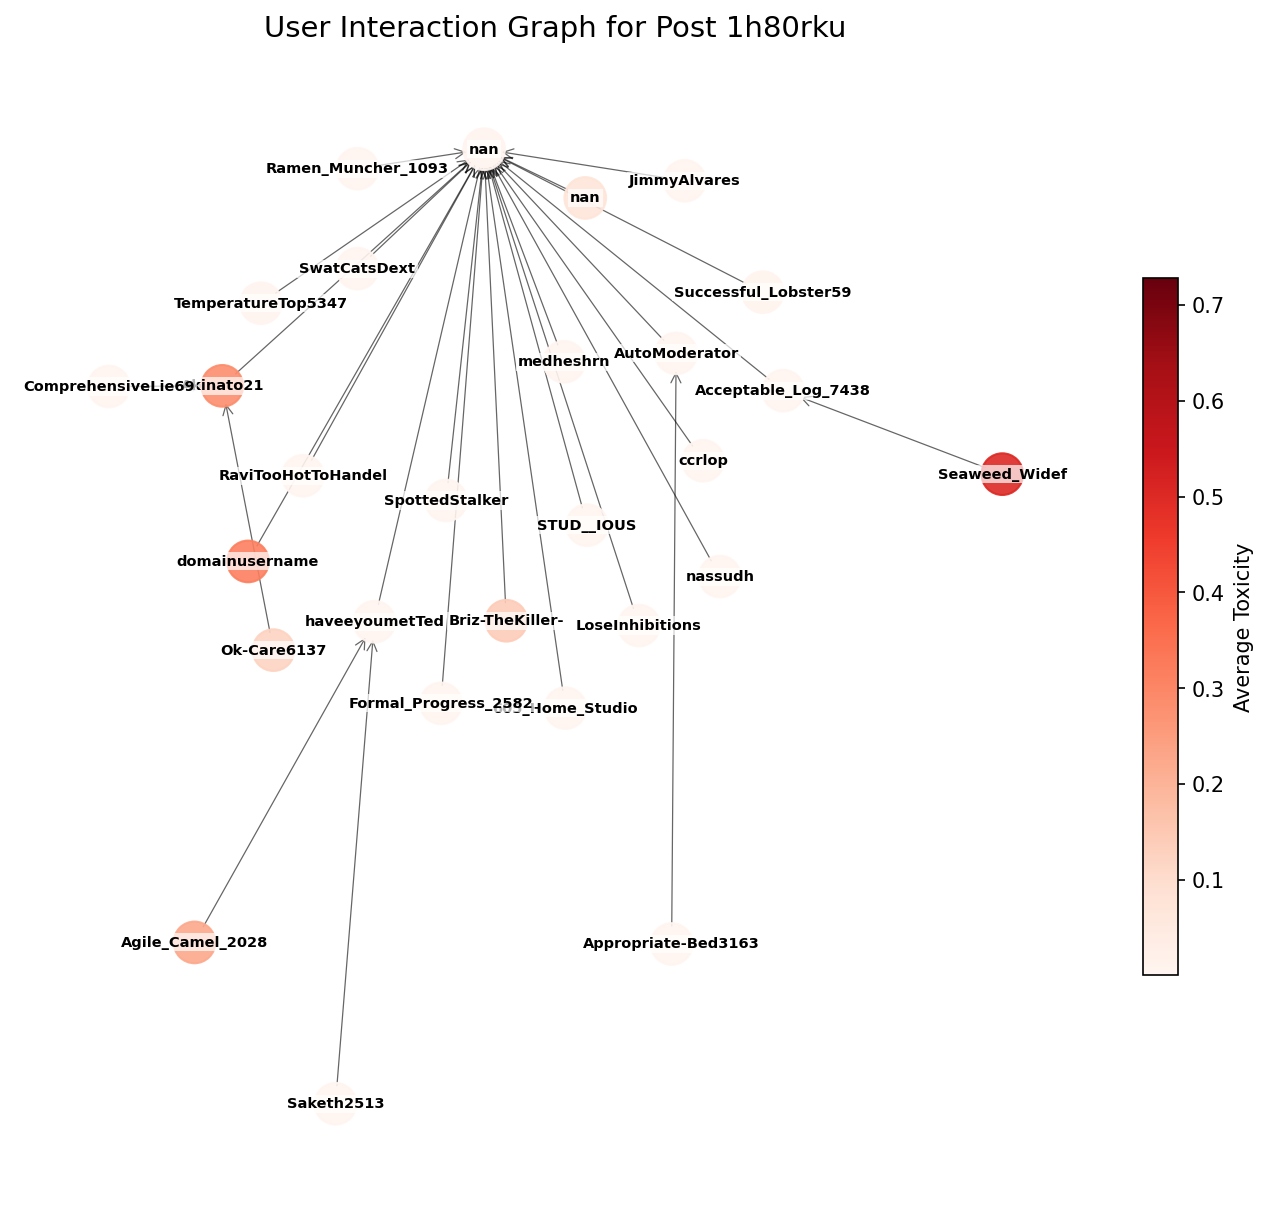

In [19]:
import os
import json
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import colormaps
from tqdm import tqdm

# Set output paths
per_conv_viz_dir = "visualizations/phase3/per_conversation_user_graphs"
export_dir = "graph_exports/phase3/user_graphs"
os.makedirs(per_conv_viz_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

# Collect global toxicity range for consistent coloring
global_tox_values = []
for post_id, thread in thread_graphs.items():
    for _, data in thread.nodes(data=True):
        tox = data.get('toxicity_score', 0.0)
        global_tox_values.append(tox)

global_min_tox = min(global_tox_values) if global_tox_values else 0.0
global_max_tox = max(global_tox_values) if global_tox_values else 1.0

# Main logic for building and visualizing user graphs per conversation
post_user_graphs = {}

for post_id, thread in tqdm(thread_graphs.items(), desc="Building per-conversation user graphs"):
    if thread.number_of_nodes() < 2:
        continue

    user_scores = {}
    for node, data in thread.nodes(data=True):
        tox = data.get('toxicity_score', 0.0)
        author = data.get('comment_author', None)
        if author:
            user_scores.setdefault(author, []).append(tox)

    avg_user_toxicity = {user: np.mean(scores) for user, scores in user_scores.items()}
    G_post = nx.DiGraph()
    
    for user, avg_tox in avg_user_toxicity.items():
        G_post.add_node(user, avg_toxicity=avg_tox)

    for node, data in thread.nodes(data=True):
        author = data.get("comment_author", None)
        parent_id = data.get("parent_id", None)

        if pd.isna(node):  # Root node (post), no comment_id
            author = post_id  # Use post_id as identifier
            if not G_post.has_node(author):
                G_post.add_node(author, avg_toxicity=0.0)
            continue

        if pd.notna(parent_id) and parent_id in thread.nodes:
            parent_data = thread.nodes[parent_id]
            parent_author = parent_data.get("comment_author", None)

            # If parent is a post (i.e., not a comment), use post_id as author
            if not parent_author:
                parent_author = post_id
                if not G_post.has_node(parent_author):
                    G_post.add_node(parent_author, avg_toxicity=0.0)

            if author and parent_author and (author != parent_author):
                if G_post.has_edge(author, parent_author):
                    G_post[author][parent_author]['weight'] += 1
                else:
                    G_post.add_edge(author, parent_author, weight=1)

    post_user_graphs[post_id] = G_post

    if G_post.number_of_nodes() < 2:
        continue

    # Visualization
    fig, ax = plt.subplots(figsize=(10, 10), dpi=150)  # Reduced size and dpi
    pos = nx.spring_layout(G_post, seed=42, k=3.0 / np.sqrt(len(G_post)))

    node_toxicities = [G_post.nodes[u].get("avg_toxicity", 0.0) for u in G_post.nodes()]
    norm = mcolors.Normalize(vmin=global_min_tox, vmax=global_max_tox)
    cmap = colormaps.get_cmap("Reds")
    node_colors = [cmap(norm(tox)) for tox in node_toxicities]

    nx.draw_networkx_nodes(G_post, pos, ax=ax, node_size=400, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(G_post, pos, ax=ax, arrowstyle='->', arrowsize=12, width=0.6, alpha=0.6, edge_color='black')
    nx.draw_networkx_labels(G_post, pos, ax=ax, font_size=7, font_color='black', font_weight='bold',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Average Toxicity", fraction=0.03, pad=0.04)

    ax.set_title(f"User Interaction Graph for Post {post_id}", fontsize=14)
    ax.axis("off")
    # plt.tight_layout()  # Commented out to avoid MemoryError
    plt.savefig(os.path.join(per_conv_viz_dir, f"user_graph_post_{post_id}.png"))
    plt.close(fig)  # Explicitly close the figure


# Export GML and JSON for all post-specific graphs
from networkx.readwrite import json_graph

for post_id, G_post in tqdm(post_user_graphs.items(), desc="Exporting per-post user graphs"):
    try:
        nx.write_gml(G_post, os.path.join(export_dir, f"user_graph_post_{post_id}.gml"))
        graph_json = json_graph.node_link_data(G_post)
        with open(os.path.join(export_dir, f"user_graph_post_{post_id}.json"), "w", encoding="utf-8") as f:
            json.dump(graph_json, f, indent=2)
    except Exception as e:
        print(f"Error exporting user graph for post {post_id}: {e}")

print("✅ Per-conversation user graph visualizations and exports complete.")


In [36]:
all_data_df.columns

Index(['comment_id', 'author_id', 'created_utc', 'body', 'parent_id',
       'is_post', 'post_id', 'comment_author', 'translated_body',
       'sentiment_prediction', 'sentiment_confidence',
       'toxicity_score_prediction', 'context'],
      dtype='object')

In [37]:
np.issubdtype(all_data_df['created_utc'].dtype, np.datetime64)

False

In [38]:
temp_data=all_data_df

In [39]:
all_data_df['created_utc']= pd.to_datetime(
    all_data_df['created_utc'],
    format="%m/%d/%Y %I:%M:%S %p %Z",
    errors='coerce'
)

In [40]:
all_data_df['created_utc'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 12414 entries, 0 to 12413
Series name: created_utc
Non-Null Count  Dtype              
--------------  -----              
12414 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1)
memory usage: 97.1 KB


In [41]:
all_data_df['created_utc']

0       2025-01-17 05:12:14+00:00
1       2025-01-17 16:04:13+00:00
2       2025-01-30 07:34:52+00:00
3       2025-01-13 17:02:08+00:00
4       2025-02-05 03:40:30+00:00
                   ...           
12409   2024-12-22 08:51:06+00:00
12410   2024-12-23 16:10:48+00:00
12411   2024-12-23 19:11:12+00:00
12412   2024-12-23 04:05:37+00:00
12413   2024-12-22 10:12:06+00:00
Name: created_utc, Length: 12414, dtype: datetime64[ns, UTC]

In [ ]:
###############################################################################
# 3. Temporal Analysis: Sentiment and Toxicity Trends Over Time
###############################################################################

# Ensure 'created_utc' is a datetime column in all_data_df
if not np.issubdtype(all_data_df['created_utc'].dtype, np.datetime64):
    all_data_df['created_utc'] = pd.to_datetime(all_data_df['created_utc'], unit='s', errors='coerce')

# Create a date column
all_data_df['date'] = all_data_df['created_utc'].dt.date

# For sentiment, map labels to numbers for averaging:
sentiment_mapping = {"negative": -1, "neutral": 0, "positive": 1}
all_data_df['sentiment_numeric'] = all_data_df['sentiment_prediction'].map(sentiment_mapping)

# Group by date and compute daily averages
daily_trends = all_data_df.groupby('date').agg({
    'sentiment_numeric': 'mean',
    'toxicity_score_prediction': 'mean'
}).reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_trends, x='date', y='sentiment_numeric', marker='o', label='Avg Sentiment', color='blue')
sns.lineplot(data=daily_trends, x='date', y='toxicity_score_prediction', marker='s', label='Avg Toxicity', color='red')
plt.title("Daily Trends of Sentiment and Toxicity")
plt.xlabel("Date")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("visualizations/phase3/daily_trends.png", dpi=300)
plt.close()

In [42]:
###############################################################################
# 4. Benchmarking Dataset Preparation for Model Comparison
###############################################################################

# For benchmarking, we prepare a dataset where each comment has:
# - The 'context': concatenated text of previous N comments within the same thread.
# - The 'text': the comment text itself.
# - The 'label': the sentiment label (obtained in Phase 2)

# A helper function to fetch previous N comments for a given comment_id in the same thread:
def get_context(comment_id, all_data, n=3):
    """
    Retrieve the concatenated translated text of up to the last n comments (based on created_utc)
    in the same thread (same post_id) preceding the comment with comment_id.
    """
    row = all_data[all_data['comment_id'] == comment_id]
    if row.empty:
        return ""
    post_id = row.iloc[0]['post_id']
    created = row.iloc[0]['created_utc']
    # Get previous comments in the same thread
    context = all_data[(all_data['post_id'] == post_id) & (all_data['created_utc'] < created)]
    context = context.sort_values('created_utc').tail(n)
    return " ".join(context['translated_body'].tolist())

# Create a new column 'context'
all_data_df['context'] = all_data_df['comment_id'].apply(lambda cid: get_context(cid, all_data_df, n=3))

# Now all_data_df is ready for further model benchmarking comparisons.
# This dataset contains:
# 'context' - the previous n comments (aggregated)
# 'translated_body' - the comment's own text
# 'sentiment' - the sentiment label from Phase 2
# 'toxicity_score' - the toxicity score from Phase 2

# Save this preparation for benchmarking:
all_data_df.to_csv("visualizations/phase3/benchmarking_dataset.csv", index=False)


In [43]:
all_data_df.columns

Index(['comment_id', 'author_id', 'created_utc', 'body', 'parent_id',
       'is_post', 'post_id', 'comment_author', 'translated_body',
       'sentiment_prediction', 'sentiment_confidence',
       'toxicity_score_prediction', 'context'],
      dtype='object')

Early results


Initializing models...


Training and evaluating BiLSTM model...

Training Epoch 1/5: 100%|██████████| 311/311 [00:26<00:00, 11.95it/s]
Epoch 1/5, Loss: 0.9782
Training Epoch 2/5: 100%|██████████| 311/311 [00:26<00:00, 11.94it/s]
Epoch 2/5, Loss: 0.9491
Training Epoch 3/5: 100%|██████████| 311/311 [00:25<00:00, 11.98it/s]
Epoch 3/5, Loss: 0.8928
Training Epoch 4/5: 100%|██████████| 311/311 [00:26<00:00, 11.93it/s]
Epoch 4/5, Loss: 0.8117
Training Epoch 5/5: 100%|██████████| 311/311 [00:26<00:00, 11.94it/s]
Epoch 5/5, Loss: 0.7692
BiLSTM training completed in 130.17 seconds.
Evaluating: 100%|██████████| 78/78 [00:01<00:00, 51.96it/s]

BiLSTM Evaluation:
              precision    recall  f1-score   support

    negative       0.51      0.26      0.35       959
     neutral       0.51      0.76      0.61      1212
    positive       0.24      0.13      0.17       312

    accuracy                           0.49      2483
   macro avg       0.42      0.39      0.38      2483
weighted avg       0.48      0.49      0.45      2483

Average inference time per batch: 0.0177 seconds


Training and evaluating BiLSTM+Markov model...

Training Epoch 1/5: 100%|██████████| 311/311 [01:42<00:00,  3.02it/s]
Epoch 1/5, Loss: 0.9774
Training Epoch 2/5: 100%|██████████| 311/311 [01:42<00:00,  3.04it/s]
Epoch 2/5, Loss: 0.9408
Training Epoch 3/5: 100%|██████████| 311/311 [01:47<00:00,  2.91it/s]
Epoch 3/5, Loss: 0.8985
Training Epoch 4/5: 100%|██████████| 311/311 [01:49<00:00,  2.83it/s]
Epoch 4/5, Loss: 0.8192
Training Epoch 5/5: 100%|██████████| 311/311 [01:50<00:00,  2.82it/s]
Epoch 5/5, Loss: 0.7333
BiLSTM+Markov training completed in 532.68 seconds.
Evaluating: 100%|██████████| 78/78 [00:21<00:00,  3.61it/s]

BiLSTM+Markov Evaluation:
              precision    recall  f1-score   support

    negative       0.52      0.36      0.42       959
     neutral       0.52      0.75      0.61      1212
    positive       0.31      0.09      0.14       312

    accuracy                           0.51      2483
   macro avg       0.45      0.40      0.39      2483
weighted avg       0.49      0.51      0.48      2483

Average inference time per batch: 0.0208 seconds


Training and evaluating RoBERTa model...

Training RoBERTa Epoch 1/5: 100%|██████████| 311/311 [29:49<00:00,  5.76s/it]
Epoch 1/5, Loss: 0.9949
Training RoBERTa Epoch 2/5: 100%|██████████| 311/311 [29:44<00:00,  5.74s/it]
Epoch 2/5, Loss: 0.9878
Training RoBERTa Epoch 3/5: 100%|██████████| 311/311 [31:00<00:00,  5.98s/it]
Epoch 3/5, Loss: 0.9769
Training RoBERTa Epoch 4/5: 100%|██████████| 311/311 [31:44<00:00,  6.12s/it]
Epoch 4/5, Loss: 0.9614
Training RoBERTa Epoch 5/5: 100%|██████████| 311/311 [32:18<00:00,  6.23s/it]
Epoch 5/5, Loss: 0.9271
RoBERTa training completed in 9277.84 seconds.
Evaluating RoBERTa: 100%|██████████| 78/78 [02:24<00:00,  1.86s/it]
RoBERTa Evaluation:
              precision    recall  f1-score   support

    negative       0.41      0.94      0.57       959
     neutral       0.59      0.15      0.23      1212
    positive       0.00      0.00      0.00       312

    accuracy                           0.43      2483
   macro avg       0.34      0.36      0.27      2483
weighted avg       0.45      0.43      0.34      2483

Average inference time per batch: 1.8197 seconds


Model Performance Comparison

Model                Training Time (s)    Inference Time (s)  
------------------------------------------------------------
BiLSTM               130.17               0.0177              
BiLSTM+Markov        532.68               0.0208              
RoBERTa              9277.84              1.8197              

c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

## Last try

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
import matplotlib.pyplot as plt


In [ ]:
# -------------------------
# 1. Data Preparation
# -------------------------
# all_data_df must contain at least 'sentiment_prediction', 'toxicity_score_prediction', 'context', 'translated_body'
df = all_data_df.dropna(subset=["sentiment_prediction"]).copy()
label_to_idx = {"negative": 0, "neutral": 1, "positive": 2}
idx_to_label = {v: k for k, v in label_to_idx.items()}
df["label"] = df["sentiment_prediction"].map(label_to_idx)

# (For toxicity class distribution, you may later compute binary labels.)
if "toxicity_score_prediction" in df.columns:
    df["toxicity_label"] = (df["toxicity_score_prediction"].astype(float) > 0.5).astype(int)

# Create input_text from either 'context' (if available) or 'translated_body'
df["input_text"] = df["context"].apply(lambda x: x if isinstance(x, str) and x.strip() != "" else None)
df.loc[df["input_text"].isna(), "input_text"] = df.loc[df["input_text"].isna(), "translated_body"]

# Split data into Train (60%), Val (20%), and Test (20%)
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42, stratify=train_val_df["label"])
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# To check class distribution for sentiment and toxicity:
print("Sentiment distribution in full dataset:")
print(df["label"].value_counts())
if "toxicity_label" in df.columns:
    print("\nToxicity distribution (binary):")
    print(df["toxicity_label"].value_counts())

In [ ]:
# -------------------------
# 2. Tokenization and Vocabulary
# -------------------------
max_len = 128
tokenizer_keras = keras.preprocessing.text.Tokenizer(lower=True, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(train_df["input_text"].tolist())
vocab_size = len(tokenizer_keras.word_index) + 1
print("Vocabulary size:", vocab_size)

def texts_to_sequences(texts):
    return keras.preprocessing.sequence.pad_sequences(
        tokenizer_keras.texts_to_sequences(texts),
        maxlen=max_len, padding="post", truncating="post"
    )

X_train = texts_to_sequences(train_df["input_text"].tolist())
X_val = texts_to_sequences(val_df["input_text"].tolist())
X_test = texts_to_sequences(test_df["input_text"].tolist())
y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

In [ ]:
# -------------------------
# 3. Markov Feature Engineering & Scaling
# -------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_markov_features(text, max_len=128):
    text = clean_text(text)
    words = text.split()
    if len(words) <= 1:
        return np.zeros(max_len)
    # Here we assign a constant value of 0.1 for each bigram
    features = [0.1 for _ in range(min(len(words)-1, max_len))]
    if len(features) < max_len:
        features.extend([0.0] * (max_len - len(features)))
    return np.array(features)

X_train_markov = np.array([get_markov_features(text, max_len) for text in train_df["input_text"].tolist()])
X_val_markov = np.array([get_markov_features(text, max_len) for text in val_df["input_text"].tolist()])
X_test_markov = np.array([get_markov_features(text, max_len) for text in test_df["input_text"].tolist()])

scaler = StandardScaler()
X_train_markov = scaler.fit_transform(X_train_markov)
X_val_markov = scaler.transform(X_val_markov)
X_test_markov = scaler.transform(X_test_markov)

In [ ]:
# -------------------------
# 4. Load GloVe Embeddings and Create Embedding Matrix
# -------------------------
def load_glove_embeddings(file_path):
    embeddings_index = {}
    with open(file_path, 'r', encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = vector
    return embeddings_index

glove_path = "glove.6B.100d.txt"
print("Loading GloVe embeddings from", glove_path)
glove_embeddings = load_glove_embeddings(glove_path)
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer_keras.word_index.items():
    vector = glove_embeddings.get(word)
    if vector is not None:
        embedding_matrix[i] = vector
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
embedding_matrix = tf.convert_to_tensor(embedding_matrix, dtype=tf.float32)
print("Embedding matrix shape:", embedding_matrix.shape)

In [ ]:

# -------------------------
# 5. Prepare Input Dictionaries for Keras Models
# -------------------------
train_inputs = {"text_input": X_train, "markov_input": X_train_markov}
val_inputs = {"text_input": X_val, "markov_input": X_val_markov}
test_inputs = {"text_input": X_test, "markov_input": X_test_markov}

In [ ]:

# -------------------------
# 6. Hypermodel Builder Functions for KerasTuner
# -------------------------
# Model 1: BiLSTM Hypermodel builder
def build_bilstm_model(hp):
    embedding_trainable = hp.Boolean("embedding_trainable", default=False)
    lstm_units = hp.Int("lstm_units", min_value=64, max_value=256, step=32, default=128)
    dropout_rate = hp.Float("dropout_rate", min_value=0.1, max_value=0.5, step=0.1, default=0.3)
    dense_units = hp.Int("dense_units", min_value=32, max_value=128, step=32, default=64)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log", default=1e-3)
    
    text_input = keras.Input(shape=(max_len,), name="text_input")
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                         weights=[embedding_matrix],
                         trainable=embedding_trainable, mask_zero=True)(text_input)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True,
                                         kernel_regularizer=regularizers.l2(1e-4)))(x)
    text_features = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(text_features)
    x = layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    output = layers.Dense(3, activation="softmax")(x)
    
    model = keras.Model(inputs=text_input, outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# Model 2: Hybrid Model (BiLSTM + Markov) without CNN
def build_hybrid_model(hp):
    embedding_trainable = hp.Boolean("embedding_trainable", default=False)
    lstm_units = hp.Int("lstm_units", min_value=64, max_value=256, step=32, default=128)
    dropout_rate = hp.Float("dropout_rate", min_value=0.1, max_value=0.5, step=0.1, default=0.3)
    dense_units = hp.Int("dense_units", min_value=32, max_value=128, step=32, default=64)
    markov_dense_units = hp.Int("markov_dense_units", min_value=16, max_value=64, step=16, default=32)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log", default=1e-3)
    
    text_input = keras.Input(shape=(max_len,), name="text_input")
    markov_input = keras.Input(shape=(max_len,), name="markov_input")
    
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                         weights=[embedding_matrix],
                         trainable=embedding_trainable, mask_zero=True)(text_input)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True,
                                         kernel_regularizer=regularizers.l2(1e-4)))(x)
    text_features = layers.GlobalAveragePooling1D()(x)
    
    # Process Markov features using a two-layer MLP after normalization
    m = layers.LayerNormalization()(markov_input)
    m = layers.Dense(markov_dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(m)
    m = layers.Dense(markov_dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(m)
    markov_features = layers.GlobalAveragePooling1D()(tf.expand_dims(m, -1))
    
    combined = layers.Concatenate()([text_features, markov_features])
    combined = layers.Dropout(dropout_rate)(combined)
    combined = layers.Dense(dense_units, activation="relu",
                            kernel_regularizer=regularizers.l2(1e-4))(combined)
    output = layers.Dense(3, activation="softmax")(combined)
    
    model = keras.Model(inputs=[text_input, markov_input], outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


In [ ]:
# -------------------------
# 7. RoBERTa Model Builder (Fixed Configuration)
# -------------------------
def build_roberta_model():
    model = TFAutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=["accuracy"])
    return model

In [ ]:

# -------------------------
# 8. Hyperparameter Tuning with KerasTuner for BiLSTM and Hybrid Models
# -------------------------
tuner_bilstm = kt.RandomSearch(
    build_bilstm_model,
    objective="val_accuracy",
    max_trials=50,
    executions_per_trial=1,
    directory="ktuner_dir/new1",
    project_name="bilstm_sentiment"
)

tuner_hybrid = kt.RandomSearch(
    build_hybrid_model,
    objective="val_accuracy",
    max_trials=50,
    executions_per_trial=1,
    directory="ktuner_dir/new1",
    project_name="hybrid_sentiment"
)

early_stop_callback = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("Tuning BiLSTM Model...")
tuner_bilstm.search(X_train, y_train, epochs=20, validation_data=(X_val, y_val), callbacks=[early_stop_callback])
best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters for BiLSTM:", best_hps_bilstm.values)

print("Tuning Hybrid Model...")
tuner_hybrid.search(train_inputs, y_train, epochs=20, validation_data=(val_inputs, y_val), callbacks=[early_stop_callback])
best_hps_hybrid = tuner_hybrid.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters for Hybrid:", best_hps_hybrid.values)

In [ ]:
# -------------------------
# 9. Build and Train Best Models from Tuner Results
# -------------------------
# Train best BiLSTM model
best_bilstm_model = tuner_bilstm.hypermodel.build(best_hps_bilstm)
bilstm_callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)]
best_bilstm_history = best_bilstm_model.fit(X_train, y_train, epochs=20, batch_size=32,
                                            validation_data=(X_val, y_val), callbacks=bilstm_callbacks)

def plot_history(history, model_name="Model"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(history.history["loss"], label="Train Loss")
    ax[0].plot(history.history["val_loss"], label="Val Loss")
    ax[0].set_title(model_name + " Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()
    ax[1].plot(history.history["accuracy"], label="Train Acc")
    ax[1].plot(history.history["val_accuracy"], label="Val Acc")
    ax[1].set_title(model_name + " Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()
    plt.show()

print("Training graphs for BiLSTM Model:")
plot_history(best_bilstm_history, model_name="BiLSTM")

val_preds_bilstm = np.argmax(best_bilstm_model.predict(X_val), axis=1)
print("Final Validation Classification Report for BiLSTM:")
print(classification_report(y_val, val_preds_bilstm, target_names=["negative", "neutral", "positive"]))

# Train best Hybrid model (BiLSTM+Markov)
best_hybrid_model = tuner_hybrid.hypermodel.build(best_hps_hybrid)
hybrid_callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)]
best_hybrid_history = best_hybrid_model.fit(train_inputs, y_train, epochs=20, batch_size=32,
                                            validation_data=(val_inputs, y_val), callbacks=hybrid_callbacks)
print("Training graphs for Hybrid Model:")
plot_history(best_hybrid_history, model_name="Hybrid")
val_preds_hybrid = np.argmax(best_hybrid_model.predict(val_inputs), axis=1)
print("Final Validation Classification Report for Hybrid Model:")
print(classification_report(y_val, val_preds_hybrid, target_names=["negative", "neutral", "positive"]))

Trial 10 Complete [00h 03m 27s]
val_accuracy: 0.5155054330825806

Best val_accuracy So Far: 0.5163109302520752
Total elapsed time: 02h 48m 50s
Best hyperparameters for Hybrid: {'embedding_trainable': False, 'lstm_units': 160, 'dropout_rate': 0.5, 'dense_units': 128, 'markov_dense_units': 64, 'learning_rate': 0.00020898056742917306}
Epoch 1/20
233/233 [==============================] - 96s 396ms/step - loss: 1.0275 - accuracy: 0.4796 - val_loss: 1.0080 - val_accuracy: 0.5034
Epoch 2/20
233/233 [==============================] - 97s 417ms/step - loss: 1.0090 - accuracy: 0.4976 - val_loss: 0.9988 - val_accuracy: 0.5014
Epoch 3/20
233/233 [==============================] - 99s 423ms/step - loss: 0.9961 - accuracy: 0.4969 - val_loss: 0.9903 - val_accuracy: 0.5083
Epoch 4/20
233/233 [==============================] - 100s 428ms/step - loss: 0.9874 - accuracy: 0.5024 - val_loss: 0.9854 - val_accuracy: 0.4998
Epoch 5/20
233/233 [==============================] - 99s 424ms/step - loss: 0.9801 -

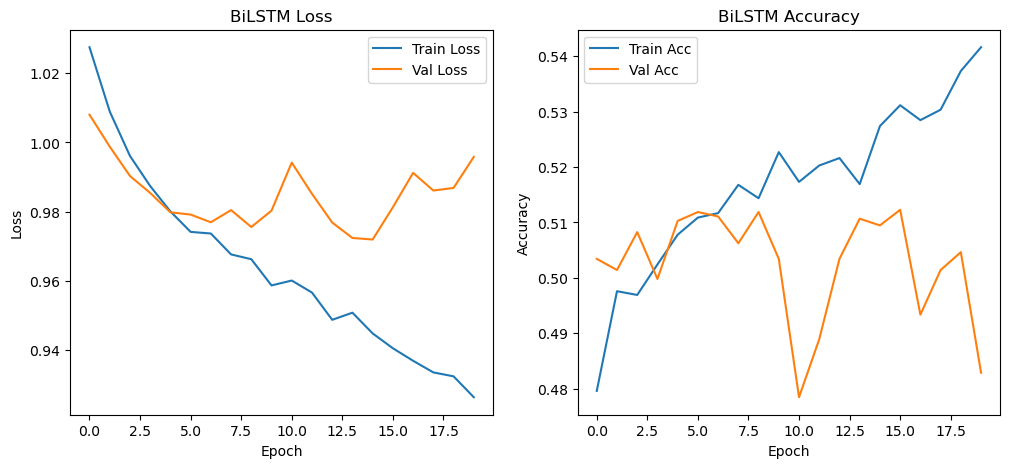

78/78 [==============================] - 12s 120ms/step
Final Validation Classification Report for BiLSTM:
              precision    recall  f1-score   support

    negative       0.49      0.42      0.45       959
     neutral       0.52      0.71      0.60      1212
    positive       0.38      0.02      0.03       312

    accuracy                           0.51      2483
   macro avg       0.47      0.38      0.36      2483
weighted avg       0.49      0.51      0.47      2483

Epoch 1/20
233/233 [==============================] - 96s 395ms/step - loss: 1.0496 - accuracy: 0.4809 - val_loss: 1.0304 - val_accuracy: 0.5006
Epoch 2/20
233/233 [==============================] - 91s 392ms/step - loss: 1.0318 - accuracy: 0.4874 - val_loss: 1.0223 - val_accuracy: 0.4990
Epoch 3/20
233/233 [==============================] - 93s 398ms/step - loss: 1.0215 - accuracy: 0.4901 - val_loss: 1.0409 - val_accuracy: 0.4410
Epoch 4/20
233/233 [==============================] - 94s 405ms/step - loss: 

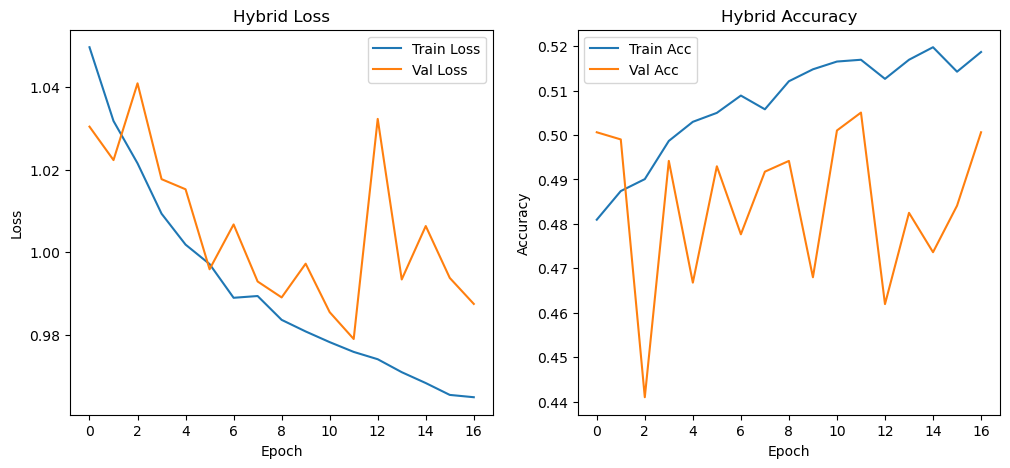

78/78 [==============================] - 10s 116ms/step
Final Validation Classification Report for Hybrid Model:
              precision    recall  f1-score   support

    negative       0.50      0.31      0.38       959
     neutral       0.51      0.79      0.62      1212
    positive       0.75      0.01      0.02       312

    accuracy                           0.51      2483
   macro avg       0.59      0.37      0.34      2483
weighted avg       0.53      0.51      0.45      2483


Final Evaluation on Test Set
78/78 [==============================] - 9s 116ms/step
BiLSTM Test Classification Report:
              precision    recall  f1-score   support

    negative       0.49      0.40      0.44       959
     neutral       0.51      0.72      0.60      1212
    positive       0.50      0.01      0.02       312

    accuracy                           0.51      2483
   macro avg       0.50      0.38      0.35      2483
weighted avg       0.50      0.51      0.47      2483

BiLST

c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\tushar_nlp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

In [ ]:

# -------------------------
# 10. Final Evaluation on Test Set with Confusion Matrices
# -------------------------
print("\n==================================")
print("Final Evaluation on Test Set")
print("==================================")
# BiLSTM Evaluation
test_preds_bilstm = np.argmax(best_bilstm_model.predict(X_test), axis=1)
print("BiLSTM Test Classification Report:")
print(classification_report(y_test, test_preds_bilstm, target_names=["negative", "neutral", "positive"]))
cm_bilstm = confusion_matrix(y_test, test_preds_bilstm)
print("BiLSTM Confusion Matrix:")
print(cm_bilstm)

# Hybrid Evaluation
test_preds_hybrid = np.argmax(best_hybrid_model.predict(test_inputs), axis=1)
print("Hybrid Model Test Classification Report:")
print(classification_report(y_test, test_preds_hybrid, target_names=["negative", "neutral", "positive"]))
cm_hybrid = confusion_matrix(y_test, test_preds_hybrid)
print("Hybrid Model Confusion Matrix:")
print(cm_hybrid)

